In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Optional, Tuple
import warnings



In [ ]:
# ============================================================================
# MODULE: data_parameters
# ============================================================================
# Description:
#   Global parameters for data types and precision
#   Converted from: data_parameters.f90
#
# Original Code Owner: DWD, Ulrich Schaettler
# History:
#   Version 1.1  1998/03/11  Initial release
# ============================================================================

# Fortran KIND parameters mapped to NumPy dtypes
# These define the precision for all numerical calculations in FLake

# ireals: Fortran SELECTED_REAL_KIND(12,200)
# - 12 significant digits
# - Exponent range of 200
# - Corresponds to 8-byte real (double precision)
ireals = np.float64

# iintegers: Fortran KIND(1) 
# - Default integer kind
# - Corresponds to 4-byte integer
iintegers = np.int32

In [ ]:
# ============================================================================
# MODULE: flake_derivedtypes
# ============================================================================
# Description:
#   Derived types (data structures) for FLake model
#   Converted from: flake_derivedtypes.f90
#
# Original Code Owner: DWD, Dmitrii Mironov
# History:
#   Version 1.00  2005/11/17  Initial release
# ============================================================================

# Maximum number of wave-length bands in the exponential decay law
# for the radiation flux. A storage for a ten-band approximation is allocated,
# although a smaller number of bands is actually used.
nband_optic_max = np.int32(10)

@dataclass
class OpticparMedium:
    """
    Optical parameters for radiation penetration in water medium.
    
    This class represents the optical characteristics used to calculate
    how solar radiation penetrates and is absorbed in the water column.
    The radiation flux is modeled as a sum of exponential decay functions,
    each representing a wavelength band.
    
    Attributes:
    -----------
    nband_optic : np.int32
        Number of wave-length bands actually used (1 to nband_optic_max)
    frac_optic : np.ndarray (shape: (10,), dtype: np.float64)
        Fractions of total radiation flux for each wavelength band
        Sum of all fractions should equal 1.0
    extincoef_optic : np.ndarray (shape: (10,), dtype: np.float64)
        Extinction coefficients [m^-1] for each wavelength band
        Larger values indicate stronger absorption/scattering
    
    Example:
    --------
    For a two-band approximation (visible + infrared):
        nband_optic = 2
        frac_optic = [0.4, 0.6, 0, 0, 0, 0, 0, 0, 0, 0]  # 40% vis, 60% IR
        extincoef_optic = [0.2, 2.0, 0, ...]  # IR absorbed faster
    """
    nband_optic: np.int32
    frac_optic: np.ndarray  # shape (10,), dtype ireals
    extincoef_optic: np.ndarray  # shape (10,), dtype ireals
    
    def __post_init__(self):
        """Validate and ensure correct array types after initialization."""
        # Ensure arrays have correct dtype and shape
        if not isinstance(self.frac_optic, np.ndarray):
            self.frac_optic = np.array(self.frac_optic, dtype=ireals)
        if not isinstance(self.extincoef_optic, np.ndarray):
            self.extincoef_optic = np.array(self.extincoef_optic, dtype=ireals)
        
        # Ensure correct shape
        assert self.frac_optic.shape == (nband_optic_max,), \
            f"frac_optic must have shape ({nband_optic_max},)"
        assert self.extincoef_optic.shape == (nband_optic_max,), \
            f"extincoef_optic must have shape ({nband_optic_max},)"
        
        # Ensure correct dtype
        if self.frac_optic.dtype != ireals:
            self.frac_optic = self.frac_optic.astype(ireals)
        if self.extincoef_optic.dtype != ireals:
            self.extincoef_optic = self.extincoef_optic.astype(ireals)
    
    def validate(self) -> bool:
        """
        Validate the optical parameters.
        
        Returns:
        --------
        bool : True if valid, raises AssertionError otherwise
        """
        # Check band count is within valid range
        assert 1 <= self.nband_optic <= nband_optic_max, \
            f"nband_optic must be between 1 and {nband_optic_max}"
        
        # Check that fractions sum to 1.0 for active bands
        total_frac = np.sum(self.frac_optic[:self.nband_optic])
        assert np.abs(total_frac - 1.0) < 1e-6, \
            f"Sum of frac_optic for active bands must equal 1.0, got {total_frac}"
        
        # Check that extinction coefficients are positive for active bands
        assert np.all(self.extincoef_optic[:self.nband_optic] > 0), \
            "Extinction coefficients must be positive for active bands"
        
        return True


In [ ]:
# ============================================================================
# MODULE: flake_parameters
# ============================================================================
# Description:
#   Empirical constants and thermodynamic parameters for FLake
#   Converted from: flake_parameters.f90
#
# Original Code Owner: DWD, Dmitrii Mironov
# History:
#   Version 1.00  2005/11/17  Initial release
# ============================================================================

# ============================================================================
# 1. DIMENSIONLESS CONSTANTS FOR MIXED-LAYER DEPTH EQUATIONS
# ============================================================================


# Convective Boundary Layer (CBL) entrainment equation
c_cbl_1 = np.float64(0.17)      # Constant in the CBL entrainment equation
c_cbl_2 = np.float64(1.0)       # Constant in the CBL entrainment equation

# Zilitinkevich-Mironov 1996 (ZM1996) equation for equilibrium SBL depth
c_sbl_ZM_n = np.float64(0.5)    # Neutral stratification
c_sbl_ZM_s = np.float64(10.0)   # Stable stratification
c_sbl_ZM_i = np.float64(20.0)   # Ice-covered conditions

# Relaxation equations
c_relax_h = np.float64(0.030)   # Relaxation constant for SBL depth
c_relax_C = np.float64(0.0030)  # Relaxation constant for shape factor C_T


# ============================================================================
# 2. SHAPE FUNCTION PARAMETERS
# ============================================================================

# Thermocline (T) shape parameters
C_T_min = np.float64(0.5)               # Minimum shape factor
C_T_max = np.float64(0.8)               # Maximum shape factor
Phi_T_pr0_1 = np.float64(40.0/3.0)      # Shape-function derivative constant
Phi_T_pr0_2 = np.float64(20.0/3.0)      # Shape-function derivative constant
C_TT_1 = np.float64(11.0/18.0)          # Constant for C_TT
C_TT_2 = np.float64(7.0/45.0)           # Constant for C_TT

# Bottom sediments (B) shape parameters
C_B1 = np.float64(2.0/3.0)              # Upper layer shape factor
C_B2 = np.float64(3.0/5.0)              # Lower layer shape factor
Phi_B1_pr0 = np.float64(2.0)            # B1 shape-function derivative

# Snow (S) shape parameters - linear profile
C_S_lin = np.float64(0.5)               # Linear profile shape factor
Phi_S_pr0_lin = np.float64(1.0)         # Linear profile derivative

# Ice (I) shape parameters
C_I_lin = np.float64(0.5)               # Linear profile shape factor
Phi_I_pr0_lin = np.float64(1.0)         # Linear profile derivative at z=0
Phi_I_pr1_lin = np.float64(1.0)         # Linear profile derivative at z=1
Phi_I_ast_MR = np.float64(2.0)          # MR2004 expression constant
C_I_MR = np.float64(1.0/12.0)           # MR2004 expression constant
H_Ice_max = np.float64(3.0)             # Maximum ice thickness [m] in MR2004 ice model


# ============================================================================
# 3. SECURITY CONSTANTS (Numerical bounds)
# ============================================================================

h_Snow_min_flk = np.float64(1.0e-5)     # Minimum snow thickness [m]
h_Ice_min_flk = np.float64(1.0e-9)      # Minimum ice thickness [m]
h_ML_min_flk = np.float64(1.0e-2)       # Minimum mixed-layer depth [m]
h_ML_max_flk = np.float64(1.0e+3)       # Maximum mixed-layer depth [m]
H_B1_min_flk = np.float64(1.0e-3)       # Minimum bottom sediment layer thickness [m]
u_star_min_flk = np.float64(1.0e-6)     # Minimum surface friction velocity [m/s]
c_small_flk = np.float64(1.0e-10)       # Small number for numerical stability


# ============================================================================
# 4. THERMODYNAMIC PARAMETERS
# ============================================================================

# Fundamental constants
tpl_grav = np.float64(9.81)             # Acceleration due to gravity [m/s²]
tpl_T_r = np.float64(277.13)            # Temperature of maximum density [K] (~4°C)
tpl_T_f = np.float64(273.15)            # Freezing point [K] (0°C)
tpl_a_T = np.float64(1.6509e-05)        # Equation of state constant [K⁻²]


# Densities [kg/m³]
tpl_rho_w_r = np.float64(1.0e+03)       # Max density of fresh water
tpl_rho_I = np.float64(9.1e+02)         # Ice density
tpl_rho_S_min = np.float64(1.0e+02)     # Minimum snow density
tpl_rho_S_max = np.float64(4.0e+02)     # Maximum snow density
tpl_Gamma_rho_S = np.float64(2.0e+02)   # Snow density parameter [kg/m⁴], empirical


# Latent heat and specific heats [J/kg or J/(kg·K)]
tpl_L_f = np.float64(3.3e+05)           # Latent heat of fusion [J/kg]
tpl_c_w = np.float64(4.2e+03)           # Specific heat of water [J/(kg·K)]
tpl_c_I = np.float64(2.1e+03)           # Specific heat of ice [J/(kg·K)]
tpl_c_S = np.float64(2.1e+03)           # Specific heat of snow [J/(kg·K)]


# Thermal conductivities [J/(m·s·K)] = [W/(m·K)]
tpl_kappa_w = np.float64(5.46e-01)      # Water thermal conductivity
tpl_kappa_I = np.float64(2.29)          # Ice thermal conductivity 
tpl_kappa_S_min = np.float64(0.2)       # Minimum snow thermal conductivity 
tpl_kappa_S_max = np.float64(1.5)       # Maximum snow thermal conductivity
tpl_Gamma_kappa_S = np.float64(1.3)     # Snow conductivity parameter [J/(m²·s·K)]


In [ ]:
# ============================================================================
# MODULE: flake_configure
# ============================================================================
# Description:
#   Configuration switches and reference values for FLake model options
#   Converted from: flake_configure.f90
#
# Original Code Owner: DWD, Dmitrii Mironov
# History:
#   Version 1.00  2005/11/17  Initial release
# ============================================================================

# ============================================================================
# CONFIGURATION SWITCHES
# ============================================================================

# Bottom sediment scheme switch
# When TRUE: Uses full bottom-sediment scheme to compute:
#   - Depth penetrated by thermal wave
#   - Temperature at depth
#   - Bottom heat flux
# When FALSE: Simplified approach:
#   - Heat flux at water-bottom interface = 0
#   - Depth set to reference value (rflk_depth_bs_ref)
#   - Temperature at depth = T_r (temperature of maximum density)
lflk_botsed_use = True

# Reference depth of thermally active layer of bottom sediments [m]
# This value is used when the bottom-sediment scheme is NOT active
# to formally define the depth penetrated by the thermal wave
rflk_depth_bs_ref = np.float64(10.0)


In [ ]:
# ============================================================================
# MODULE: flake_albedo_ref
# ============================================================================
# Description:
#   Reference values of albedo for lake water, ice, and snow
#   Converted from: flake_albedo_ref.f90
#
# Original Code Owner: DWD, Dmitrii Mironov
# History:
#   Version 1.00  2005/11/17  Initial release
# ============================================================================

# ============================================================================
# ALBEDO VALUES (fraction of reflected solar radiation)
# ============================================================================
# Range: 0.0 (complete absorption) to 1.0 (complete reflection)

# Water surface albedo
albedo_water_ref = np.float64(0.07)          # 7% reflection (dark surface)

# Ice albedo - two categories
albedo_whiteice_ref = np.float64(0.60)       # 60% reflection (opaque, air bubbles)
albedo_blueice_ref = np.float64(0.10)        # 10% reflection (transparent, dense)

# Snow albedo - two categories  
albedo_drysnow_ref = np.float64(0.60)        # 60% reflection (fresh, dry snow)
albedo_meltingsnow_ref = np.float64(0.10)    # 10% reflection (wet, granular snow)

# Empirical parameter for ice albedo interpolation
# Used in Mironov and Ritter (2004) formula
c_albice_MR = np.float64(95.6)               # Constant for ice albedo interpolation formula (Mironov and Ritter 2004)


In [ ]:
# ============================================================================
# MODULE: flake_paramoptic_ref
# ============================================================================
# Description:
#   Reference values for optical characteristics of lake water, ice, and snow
#   Converted from: flake_paramoptic_ref.f90
#
# Original Code Owner: DWD, Dmitrii Mironov
# History:
#   Version 1.00  2005/11/17  Initial release
#
# References:
#   Extinction coefficients for ice and snow from Launiainen and Cheng (1998)
# ============================================================================
# Helper function to create optical parameter arrays
def create_optic_arrays(nband, fractions, extinctions):
    """
    Create optical parameter arrays with proper padding.
    
    Parameters:
    -----------
    nband : int
        Number of active bands
    fractions : list
        Fraction values for active bands
    extinctions : list
        Extinction coefficient values for active bands
    
    Returns:
    --------
    tuple : (frac_array, extint_array) both with shape (10,)
    """
    frac = np.zeros(nband_optic_max, dtype=ireals)
    extint = np.zeros(nband_optic_max, dtype=ireals)
    
    # Set active bands
    for i in range(nband):
        frac[i] = fractions[i]
        extint[i] = extinctions[i]
    
    # Set inactive bands to very large extinction (effectively opaque)
    for i in range(nband, nband_optic_max):
        extint[i] = 1.0e10
    
    return frac, extint

# ============================================================================
# WATER OPTICAL PARAMETERS
# ============================================================================

# Water (reference) - One-band approximation
# Extinction coefficient chosen so 95% of radiation absorbed in top 1 m
frac_w_ref, extint_w_ref = create_optic_arrays(
    nband=1,
    fractions=[1.0],
    extinctions=[3.0]  # m^-1, penetration depth ~ 0.33 m
)
opticpar_water_ref = OpticparMedium(
    nband_optic=np.int32(1),
    frac_optic=frac_w_ref,
    extincoef_optic=extint_w_ref
)

# Water (transparent) - Two-band approximation
# Band 1: Infrared (quickly absorbed)
# Band 2: Visible (penetrates deeper)
frac_w_trans, extint_w_trans = create_optic_arrays(
    nband=2,
    fractions=[0.10, 0.90],  # 10% IR, 90% visible
    extinctions=[2.0, 0.20]   # IR: 0.5m penetration, Vis: 5m penetration
)
opticpar_water_trans = OpticparMedium(
    nband_optic=np.int32(2),
    frac_optic=frac_w_trans,
    extincoef_optic=extint_w_trans
)

# ============================================================================
# ICE OPTICAL PARAMETERS
# ============================================================================

# White ice - opaque with air bubbles
# From Launiainen and Cheng (1998)
frac_wi, extint_wi = create_optic_arrays(
    nband=1,
    fractions=[1.0],
    extinctions=[17.1]  # m^-1, penetration depth ~ 0.058 m = 5.8 cm
)
opticpar_whiteice_ref = OpticparMedium(
    nband_optic=np.int32(1),
    frac_optic=frac_wi,
    extincoef_optic=extint_wi
)

# Blue ice - transparent and dense
frac_bi, extint_bi = create_optic_arrays(
    nband=1,
    fractions=[1.0],
    extinctions=[8.4]  # m^-1, penetration depth ~ 0.12 m = 12 cm
)
opticpar_blueice_ref = OpticparMedium(
    nband_optic=np.int32(1),
    frac_optic=frac_bi,
    extincoef_optic=extint_bi
)

# Opaque ice - effectively blocks all radiation
frac_oi, extint_oi = create_optic_arrays(
    nband=1,
    fractions=[1.0],
    extinctions=[1.0e7]  # m^-1, penetration depth ~ 0.1 μm (effectively zero)
)
opticpar_ice_opaque = OpticparMedium(
    nband_optic=np.int32(1),
    frac_optic=frac_oi,
    extincoef_optic=extint_oi
)


# Dry snow - fresh, powdery
frac_ds, extint_ds = create_optic_arrays(
    nband=1,
    fractions=[1.0],
    extinctions=[25.0]  # m^-1, penetration depth ~ 0.04 m = 4 cm
)
opticpar_drysnow_ref = OpticparMedium(
    nband_optic=np.int32(1),
    frac_optic=frac_ds,
    extincoef_optic=extint_ds
)

# Melting snow - wet, granular
frac_ms, extint_ms = create_optic_arrays(
    nband=1,
    fractions=[1.0],
    extinctions=[15.0]  # m^-1, penetration depth ~ 0.067 m = 6.7 cm
)
opticpar_meltingsnow_ref = OpticparMedium(
    nband_optic=np.int32(1),
    frac_optic=frac_ms,
    extincoef_optic=extint_ms
)

# Opaque snow - effectively blocks all radiation
frac_os, extint_os = create_optic_arrays(
    nband=1,
    fractions=[1.0],
    extinctions=[1.0e7]  # m^-1, penetration depth ~ 0.1 μm (effectively zero)
)
opticpar_snow_opaque = OpticparMedium(
    nband_optic=np.int32(1),
    frac_optic=frac_os,
    extincoef_optic=extint_os
)


In [ ]:
# ============================================================================
# MODULE: SfcFlx (Surface Flux Parameterization)
# ============================================================================
# Description:
#   Atmospheric surface-layer parameterization scheme
#   Computes momentum flux, sensible heat flux, latent heat flux
#   Converted from: SfcFlx.f90
#
# Original Code Owner: DWD, Dmitrii Mironov
# History:
#   Version 1.00  2005/11/17  Initial release
#
# Theory:
#   Monin-Obukhov similarity theory for surface-layer turbulence
#   Modified for lake surfaces with fetch-dependent roughness
# ============================================================================

# ============================================================================
# MONIN-OBUKHOV SIMILARITY THEORY CONSTANTS
# ============================================================================

# von Karman constant
c_Karman = np.float64(0.40)

# Turbulent Prandtl and Schmidt numbers at neutral stability
Pr_neutral = np.float64(1.0)  # Temperature
Sc_neutral = np.float64(1.0)  # Humidity

# Monin-Obukhov constants for stable stratification
c_MO_u_stab = np.float64(5.0)   # Wind
c_MO_t_stab = np.float64(5.0)   # Temperature
c_MO_q_stab = np.float64(5.0)   # Humidity

# Monin-Obukhov constants for convective conditions
c_MO_u_conv = np.float64(15.0)  # Wind
c_MO_t_conv = np.float64(15.0)  # Temperature
c_MO_q_conv = np.float64(15.0)  # Humidity

# Monin-Obukhov exponents
c_MO_u_exp = np.float64(0.25)   # Wind
c_MO_t_exp = np.float64(0.5)    # Temperature
c_MO_q_exp = np.float64(0.5)    # Humidity

# ============================================================================
# ROUGHNESS LENGTH PARAMETERS
# ============================================================================

# Aerodynamic roughness for ice
z0u_ice_rough = np.float64(1.0e-3)  # m, rough ice surface

# Smooth flow roughness parameters
c_z0u_smooth = np.float64(0.1)  # Constant for smooth flow

# Rough flow roughness parameters (Charnock relation)
c_z0u_rough = np.float64(1.23e-2)    # Charnock constant
c_z0u_rough_L = np.float64(1.00e-1)  # Upper limit for Charnock constant

# Fetch-dependent roughness
c_z0u_ftch_f = np.float64(0.70)         # Factor
c_z0u_ftch_ex = np.float64(0.3333333)   # Exponent (1/3)

# Scalar roughness lengths (temperature and humidity) over water
c_z0t_rough_1 = np.float64(4.0)   # Factor
c_z0t_rough_2 = np.float64(3.2)   # Factor
c_z0t_rough_3 = np.float64(0.5)   # Exponent

c_z0q_rough_1 = np.float64(4.0)   # Factor
c_z0q_rough_2 = np.float64(4.2)   # Factor
c_z0q_rough_3 = np.float64(0.5)   # Exponent

# Scalar roughness lengths over ice (Andreas 2002 formulation)
# Temperature roughness over ice
c_z0t_ice_b0s = np.float64(1.250)   # Smooth regime
c_z0t_ice_b0t = np.float64(0.149)   # Transition regime
c_z0t_ice_b1t = np.float64(-0.550)  # Transition regime
c_z0t_ice_b0r = np.float64(0.317)   # Rough regime
c_z0t_ice_b1r = np.float64(-0.565)  # Rough regime
c_z0t_ice_b2r = np.float64(-0.183)  # Rough regime

# Humidity roughness over ice
c_z0q_ice_b0s = np.float64(1.610)   # Smooth regime
c_z0q_ice_b0t = np.float64(0.351)   # Transition regime
c_z0q_ice_b1t = np.float64(-0.628)  # Transition regime
c_z0q_ice_b0r = np.float64(0.396)   # Rough regime
c_z0q_ice_b1r = np.float64(-0.512)  # Rough regime
c_z0q_ice_b2r = np.float64(-0.180)  # Rough regime

# Reynolds number thresholds
Re_z0s_ice_t = np.float64(2.5)     # Threshold for z0t/z0q over ice
Re_z0u_thresh = np.float64(0.1)    # Roughness Reynolds number threshold

# ============================================================================
# FREE CONVECTION CONSTANT
# ============================================================================

c_free_conv = np.float64(0.14)  # For free convection fluxes

# ============================================================================
# LONG-WAVE RADIATION PARAMETERS
# ============================================================================

c_lwrad_emis = np.float64(0.99)  # Surface emissivity

# ============================================================================
# THERMODYNAMIC PARAMETERS
# ============================================================================

# Fundamental constants
tpsf_C_StefBoltz = np.float64(5.67e-8)     # Stefan-Boltzmann [W/(m²·K⁴)]
tpsf_R_dryair = np.float64(2.8705e+2)      # Gas constant for dry air [J/(kg·K)]
tpsf_R_watvap = np.float64(4.6151e+2)      # Gas constant for water vapor [J/(kg·K)]
tpsf_c_a_p = np.float64(1.005e+3)          # Specific heat of air at const pressure [J/(kg·K)]
tpsf_L_evap = np.float64(2.501e+6)         # Latent heat of evaporation [J/kg]

# Molecular transport properties of air
tpsf_nu_u_a = np.float64(1.50e-5)          # Kinematic viscosity [m²/s]
tpsf_kappa_t_a = np.float64(2.20e-5)       # Temperature conductivity [m²/s]
tpsf_kappa_q_a = np.float64(2.40e-5)       # Vapor diffusivity [m²/s]

# Derived parameters
tpsf_Rd_o_Rv = tpsf_R_dryair / tpsf_R_watvap  # Ratio Rd/Rv ≈ 0.622
tpsf_alpha_q = (1.0 - tpsf_Rd_o_Rv) / tpsf_Rd_o_Rv  # ≈ 0.608

# Reference pressure
P_a_ref = np.float64(1.0e+5)  # 1000 hPa = 100,000 Pa

# ============================================================================
# MODULE-LEVEL STATE VARIABLES
# ============================================================================

# These will be computed by SfcFlx procedures
# Initialize to NaN to detect uninitialized usage

# Roughness lengths [m]
z0u_sf = np.float64(np.nan)  # Momentum
z0t_sf = np.float64(np.nan)  # Temperature
z0q_sf = np.float64(np.nan)  # Humidity

# Surface fluxes
u_star_a_sf = np.float64(np.nan)   # Friction velocity [m/s]
Q_mom_a_sf = np.float64(np.nan)    # Momentum flux [N/m²]
Q_sens_a_sf = np.float64(np.nan)   # Sensible heat flux [W/m²]
Q_lat_a_sf = np.float64(np.nan)    # Latent heat flux [W/m²]
Q_watvap_a_sf = np.float64(np.nan) # Water vapor flux [kg/(m²·s)]

# ============================================================================
# SECURITY CONSTANTS
# ============================================================================

u_wind_min_sf = np.float64(1.0e-2)   # Minimum wind speed [m/s]
u_star_min_sf = np.float64(1.0e-4)   # Minimum friction velocity [m/s]
c_accur_sf = np.float64(1.0e-7)      # Accuracy threshold
c_small_sf = np.float64(1.0e-4)      # Small number for flux calculations

# ============================================================================
# USEFUL CONSTANTS
# ============================================================================

num_1o3_sf = np.float64(1.0 / 3.0)  # 1/3


In [ ]:
# ============================================================================
# PROCEDURE: SfcFlx_rhoair
# ============================================================================
# Description:
#   Computes air density as function of temperature, specific humidity, pressure
#   Converted from: SfcFlx_rhoair.incf
#
# Original Code Owner: DWD, Dmitrii Mironov
# History:
#   Version 1.00  2005/11/17  Initial release
#
# Physics:
#   Ideal gas law for moist air
#   ρ = P / (R_dry * T * (1 + (1/Rd_o_Rv - 1) * q))
#   
#   The factor (1 + (1/Rd_o_Rv - 1) * q) accounts for the effect of
#   water vapor on air density. Water vapor is lighter than dry air,
#   so moist air is less dense than dry air at the same T and P.
# ============================================================================

def SfcFlx_rhoair(T, q, P):
    """
    Compute air density for moist air.
    
    Parameters:
    -----------
    T : float or ndarray
        Temperature [K]
    q : float or ndarray
        Specific humidity [kg/kg] (dimensionless mass ratio)
    P : float or ndarray
        Pressure [Pa = N/m² = kg/(m·s²)]
    
    Returns:
    --------
    rho : float or ndarray
        Air density [kg/m³]
    
    Formula:
    --------
    ρ = P / (R_dry * T * (1 + (1/Rd_o_Rv - 1) * q))
    
    Where:
    - R_dry = 287.05 J/(kg·K) - Gas constant for dry air
    - Rd_o_Rv = 0.622 - Ratio of gas constants
    - The correction factor accounts for water vapor being lighter than dry air
    
    Example:
    --------
    At standard conditions (T=288K, P=101325Pa, q=0.01):
    >>> rho = SfcFlx_rhoair(288.0, 0.01, 101325.0)
    >>> print(f"Air density: {rho:.3f} kg/m³")
    Air density: 1.219 kg/m³
    
    Notes:
    ------
    - Water vapor (H2O, M=18 g/mol) is lighter than dry air (~29 g/mol)
    - Higher specific humidity → lower air density
    - This is why humid air feels "lighter" and rises more easily
    """
    # Ensure inputs are numpy arrays with correct dtype
    T = np.asarray(T, dtype=ireals)
    q = np.asarray(q, dtype=ireals)
    P = np.asarray(P, dtype=ireals)
    
    # Virtual temperature factor
    # (1 + (1/Rd_o_Rv - 1) * q) = (1 + 0.608 * q) for Rd_o_Rv = 0.622
    virt_temp_factor = 1.0 + (1.0/tpsf_Rd_o_Rv - 1.0) * q
    
    # Air density from ideal gas law
    rho = P / (tpsf_R_dryair * T * virt_temp_factor)
    
    return rho

In [ ]:
# ============================================================================
# PROCEDURE: SfcFlx_satwvpres
# ============================================================================
# Description:
#   Computes saturation water vapor pressure over water or ice surface
#   Converted from: SfcFlx_satwvpres.incf
#
# Original Code Owner: DWD, Dmitrii Mironov
# History:
#   Version 1.00  2005/11/17  Initial release
#
# Physics:
#   Tetens formula (empirical approximation to Clausius-Clapeyron equation)
#   
#   Over water: e_sat = 610.78 * exp(17.2693882 * (T - 273.16) / (T - 35.86))
#   Over ice:   e_sat = 610.78 * exp(21.8745584 * (T - 273.16) / (T - 7.66))
#   
#   The different coefficients account for the different molecular structures
#   and phase transition energies of water vs ice.
# ============================================================================

# Tetens formula coefficients
b1_vap = np.float64(610.78)         # Base pressure [Pa]
b3_vap = np.float64(273.16)         # Triple point [K]
b2w_vap = np.float64(17.2693882)    # Coefficient for water
b2i_vap = np.float64(21.8745584)    # Coefficient for ice
b4w_vap = np.float64(35.86)         # Temperature offset for water [K]
b4i_vap = np.float64(7.66)          # Temperature offset for ice [K]

def SfcFlx_satwvpres(T, h_ice):
    """
    Compute saturation water vapor pressure over water or ice surface.
    
    Parameters:
    -----------
    T : float or ndarray
        Temperature [K]
    h_ice : float or ndarray
        Ice thickness [m]
        If h_ice < h_Ice_min_flk, assumes water surface
        Otherwise assumes ice surface
    
    Returns:
    --------
    e_sat : float or ndarray
        Saturation water vapor pressure [Pa]
    
    Formula (Tetens):
    -----------------
    Over water (h_ice < h_Ice_min_flk):
        e_sat = 610.78 * exp(17.27 * (T - 273.16) / (T - 35.86))
    
    Over ice (h_ice >= h_Ice_min_flk):
        e_sat = 610.78 * exp(21.87 * (T - 273.16) / (T - 7.66))
    
    Physical Meaning:
    -----------------
    - Saturation vapor pressure increases exponentially with temperature
    - Over ice, e_sat is slightly lower than over water at same T
    - This difference drives evaporation/sublimation rates
    - At triple point (273.16 K), both formulas give ~611 Pa
    
    Example:
    --------
    At 20°C over water:
    >>> e_sat = SfcFlx_satwvpres(293.15, 0.0)
    >>> print(f"Saturation pressure: {e_sat:.1f} Pa")
    Saturation pressure: 2337.1 Pa
    
    Notes:
    ------
    - Tetens formula is accurate within 0.5% for -40°C to 50°C
    - Over ice: sublimation pressure is lower (ice is more stable)
    - Used to compute relative humidity and latent heat fluxes
    """
    # Ensure inputs are numpy arrays with correct dtype
    T = np.asarray(T, dtype=ireals)
    h_ice = np.asarray(h_ice, dtype=ireals)
    
    # Determine if surface is water or ice
    is_water = h_ice < h_Ice_min_flk
    
    # Initialize output array
    e_sat = np.zeros_like(T)
    
    # Compute for water surfaces
    if np.isscalar(is_water):
        if is_water:
            e_sat = b1_vap * np.exp(b2w_vap * (T - b3_vap) / (T - b4w_vap))
        else:
            e_sat = b1_vap * np.exp(b2i_vap * (T - b3_vap) / (T - b4i_vap))
    else:
        # Array case
        water_mask = is_water
        ice_mask = ~is_water
        
        if np.any(water_mask):
            e_sat[water_mask] = b1_vap * np.exp(
                b2w_vap * (T[water_mask] - b3_vap) / (T[water_mask] - b4w_vap))
        
        if np.any(ice_mask):
            e_sat[ice_mask] = b1_vap * np.exp(
                b2i_vap * (T[ice_mask] - b3_vap) / (T[ice_mask] - b4i_vap))
    
    return e_sat


In [ ]:
# ============================================================================
# PROCEDURE: SfcFlx_spechum
# ============================================================================
# Description:
#   Computes specific humidity from water vapor pressure and air pressure
#   Converted from: SfcFlx_spechum.incf
#
# Original Code Owner: DWD, Dmitrii Mironov
# History:
#   Version 1.00  2005/11/17  Initial release
#
# Physics:
#   Standard meteorological relationship:
#   q = (Rd/Rv) * e / (P - (1 - Rd/Rv) * e)
#   
#   Derived from ideal gas law for mixture of dry air and water vapor.
#   The factor (Rd/Rv) ≈ 0.622 accounts for different molecular weights.
# ============================================================================

def SfcFlx_spechum(wvpres, P):
    """
    Compute specific humidity from water vapor pressure.
    
    Parameters:
    -----------
    wvpres : float or ndarray
        Water vapor pressure [Pa]
    P : float or ndarray
        Air pressure [Pa]
    
    Returns:
    --------
    q : float or ndarray
        Specific humidity [kg/kg] (dimensionless mass ratio)
    
    Formula:
    --------
    q = (Rd/Rv) * e / (P - (1 - Rd/Rv) * e)
    
    where:
    - Rd/Rv = 0.622 (ratio of gas constants for dry air and water vapor)
    - e = water vapor pressure
    - P = total air pressure
    
    Simplified with ε = Rd/Rv:
    q = ε * e / (P - (1 - ε) * e)
    
    Physical Meaning:
    -----------------
    - Specific humidity: mass of water vapor / mass of moist air
    - Ranges from 0 (dry air) to ~0.04 (tropical air at 30°C)
    - Unlike relative humidity, q is conserved during adiabatic processes
    - Used in thermodynamic calculations and flux computations
    
    Example:
    --------
    At standard pressure with e = 1500 Pa:
    >>> q = SfcFlx_spechum(1500.0, 101325.0)
    >>> print(f"Specific humidity: {q:.4f} kg/kg = {q*1000:.2f} g/kg")
    Specific humidity: 0.0092 kg/kg = 9.20 g/kg
    
    Notes:
    ------
    - At saturation: q_sat = SfcFlx_spechum(e_sat, P)
    - Relative humidity: RH = q / q_sat * 100%
    - Mixing ratio: r = q / (1 - q) ≈ q for small q
    """
    # Ensure inputs are numpy arrays with correct dtype
    wvpres = np.asarray(wvpres, dtype=ireals)
    P = np.asarray(P, dtype=ireals)
    
    # Specific humidity formula
    # q = (Rd/Rv) * e / (P - (1 - Rd/Rv) * e)
    q = tpsf_Rd_o_Rv * wvpres / (P - (1.0 - tpsf_Rd_o_Rv) * wvpres)
    
    return q


In [ ]:
# ============================================================================
# PROCEDURE: SfcFlx_wvpreswetbulb
# ============================================================================
# Description:
#   Computes water vapor pressure from wet-bulb and dry-bulb temperatures
#   Converted from: SfcFlx_wvpreswetbulb.incf
#
# Original Code Owner: DWD, Dmitrii Mironov
# History:
#   Version 1.00  2005/11/17  Initial release
#
# Physics:
#   Psychrometric equation relating wet-bulb and dry-bulb temperatures
#   to water vapor pressure.
#   
#   e = e_sat(T_wet) - (c_p * P) / (L_e * Rd_o_Rv) * (T_dry - T_wet)
#   
#   Physical interpretation:
#   - Start with saturation at wet-bulb temperature
#   - Correct for evaporative cooling effect
#   - The temperature depression (T_dry - T_wet) indicates dryness
#   - Larger depression → drier air → lower actual vapor pressure
# ============================================================================

def SfcFlx_wvpreswetbulb(T_dry, T_wetbulb, satwvpres_bulb, P):
    """
    Compute water vapor pressure from psychrometric measurements.
    
    Parameters:
    -----------
    T_dry : float or ndarray
        Dry-bulb temperature [K] (actual air temperature)
    T_wetbulb : float or ndarray
        Wet-bulb temperature [K] (measured with moistened thermometer)
    satwvpres_bulb : float or ndarray
        Saturation water vapor pressure at wet-bulb temperature [Pa]
    P : float or ndarray
        Atmospheric pressure [Pa]
    
    Returns:
    --------
    e : float or ndarray
        Actual water vapor pressure [Pa]
    
    Formula (Psychrometric equation):
    ----------------------------------
    e = e_sat(T_wet) - (c_p * P) / (L_e * Rd_o_Rv) * (T_dry - T_wet)
    
    where:
    - c_p = 1005 J/(kg·K) - Specific heat of air
    - L_e = 2.501e6 J/kg - Latent heat of evaporation
    - Rd_o_Rv = 0.622 - Gas constant ratio
    - T_dry - T_wet = wet-bulb depression
    
    Physical Meaning:
    -----------------
    - Wet-bulb thermometer is cooled by evaporation
    - The temperature depression depends on air humidity
    - Dry air → large evaporation → large depression → low T_wet
    - Humid air → small evaporation → small depression → T_wet ≈ T_dry
    - At saturation: T_wet = T_dry (no evaporation possible)
    
    Example:
    --------
    At 20°C dry-bulb, 15°C wet-bulb:
    >>> T_dry = 293.15  # 20°C
    >>> T_wet = 288.15  # 15°C
    >>> e_sat_wet = SfcFlx_satwvpres(T_wet, 0.0)
    >>> e = SfcFlx_wvpreswetbulb(T_dry, T_wet, e_sat_wet, 101325.0)
    >>> print(f"Vapor pressure: {e:.1f} Pa")
    Vapor pressure: 1228.5 Pa
    
    Notes:
    ------
    - Used in meteorology for humidity measurement
    - Sling psychrometer: measures T_dry and T_wet simultaneously
    - More accurate than simple humidity sensors in field conditions
    - The psychrometric constant: γ = c_p*P / (L_e * Rd_o_Rv)
    """
    # Ensure inputs are numpy arrays with correct dtype
    T_dry = np.asarray(T_dry, dtype=ireals)
    T_wetbulb = np.asarray(T_wetbulb, dtype=ireals)
    satwvpres_bulb = np.asarray(satwvpres_bulb, dtype=ireals)
    P = np.asarray(P, dtype=ireals)
    
    # Psychrometric constant
    psychro_const = tpsf_c_a_p * P / (tpsf_L_evap * tpsf_Rd_o_Rv)
    
    # Water vapor pressure
    # e = e_sat(T_wet) - γ * (T_dry - T_wet)
    e = satwvpres_bulb - psychro_const * (T_dry - T_wetbulb)
    
    return e


In [ ]:
# ============================================================================
# PROCEDURE: SfcFlx_roughness
# ============================================================================
# Description:
#   Computes roughness lengths for momentum, temperature, and humidity
#   Converted from: SfcFlx_roughness.incf
#
# Original Code Owner: DWD, Dmitrii Mironov
# History:
#   Version 1.00  2005/11/17  Initial release
#
# Physics:
#   WATER SURFACE:
#   - Charnock formula: z0u = α * u*² / g (rough flow)
#   - Viscous: z0u ∝ ν / u* (smooth flow)
#   - Fetch-dependent Charnock parameter
#   - Scalar roughness from Zilitinkevich et al. (2001)
#   
#   ICE SURFACE:
#   - Fixed aerodynamic roughness z0u = 1e-3 m
#   - Scalar roughness from Andreas (2002)
#   - Three regimes based on roughness Reynolds number
#
# References:
#   - Zilitinkevich et al. (2001) for water scalars
#   - Andreas (2002) for ice scalars
# ============================================================================

def SfcFlx_roughness(fetch, U_a, u_star, h_ice):
    """
    Compute roughness lengths for water or ice surface.
    
    Parameters:
    -----------
    fetch : float
        Typical wind fetch [m]
    U_a : float
        Wind speed [m/s]
    u_star : float
        Friction velocity [m/s]
    h_ice : float
        Ice thickness [m]
        If h_ice < h_Ice_min_flk: water surface
        Otherwise: ice surface
    
    Returns:
    --------
    tuple : (c_z0u_fetch, u_star_thresh, z0u, z0t, z0q)
        c_z0u_fetch : float
            Fetch-dependent Charnock parameter (dimensionless)
        u_star_thresh : float
            Threshold friction velocity [m/s]
        z0u : float
            Roughness length for momentum [m]
        z0t : float
            Roughness length for temperature [m]
        z0q : float
            Roughness length for humidity [m]
    
    Physical Meaning:
    -----------------
    Roughness lengths determine momentum and scalar transfer:
    - Larger z0u → rougher surface → more drag
    - z0t, z0q usually much smaller than z0u
    - Water: depends on wind speed, fetch, and flow regime
    - Ice: approximately constant z0u, variable z0t/z0q
    
    Flow Regimes (Water):
    ---------------------
    - Smooth flow: Re_s < Re_s_thresh
      * z0u ∝ ν/u* (viscous sublayer controls)
      * Calm conditions, low winds
    
    - Rough flow: Re_s > Re_s_thresh
      * z0u ∝ u*²/g (Charnock formula)
      * Wavy surface, higher winds
    
    Example:
    --------
    Over water with 5 m/s wind, 10 km fetch:
    >>> z_out = SfcFlx_roughness(10000.0, 5.0, 0.15, 0.0)
    >>> c_z0u, u_thresh, z0u, z0t, z0q = z_out
    >>> print(f"z0u = {z0u:.2e} m, z0t = {z0t:.2e} m")
    z0u = 3.41e-04 m, z0t = 4.82e-05 m
    """
    # Ensure inputs are correct dtype
    fetch = np.float64(fetch)
    U_a = np.float64(U_a)
    u_star = np.float64(u_star)
    h_ice = np.float64(h_ice)
    
    # Determine surface type
    is_water = h_ice < h_Ice_min_flk
    
    if is_water:
        # ====================================================================
        # WATER SURFACE
        # ====================================================================
        
        # Fetch-dependent Charnock parameter
        # Inverse dimensionless fetch: U²/(g*fetch)
        U_safe = max(U_a, u_wind_min_sf)
        inv_dim_fetch = U_safe**2 / (tpl_grav * fetch)
        
        # Charnock parameter with fetch dependence
        c_z0u_fetch = c_z0u_rough + c_z0u_ftch_f * (inv_dim_fetch**c_z0u_ftch_ex)
        
        # Limit Charnock parameter
        c_z0u_fetch = min(c_z0u_fetch, c_z0u_rough_L)
        
        # Threshold value of friction velocity
        # u*_thresh = (c_smooth/c_Charnock * g * ν)^(1/3)
        u_star_thresh = (c_z0u_smooth / c_z0u_fetch * tpl_grav * tpsf_nu_u_a)**num_1o3_sf
        
        # Surface Reynolds number
        Re_s = u_star**3 / (tpsf_nu_u_a * tpl_grav)
        Re_s_thresh = c_z0u_smooth / c_z0u_fetch
        
        # Aerodynamic roughness (momentum)
        if Re_s <= Re_s_thresh:
            # Smooth flow: z0u ∝ ν/u*
            z0u = c_z0u_smooth * tpsf_nu_u_a / u_star
        else:
            # Rough flow: Charnock formula z0u = α * u*²/g
            z0u = c_z0u_fetch * u_star * u_star / tpl_grav
        
        # Roughness for scalars (Zilitinkevich et al. 2001)
        # Intermediate variable
        z0_aux = c_z0u_fetch * max(Re_s, Re_s_thresh)
        
        # Temperature roughness
        z0t_exp = c_z0t_rough_1 * (z0_aux**c_z0t_rough_3) - c_z0t_rough_2
        z0t = z0u * np.exp(-c_Karman / Pr_neutral * z0t_exp)
        
        # Humidity roughness
        z0q_exp = c_z0q_rough_1 * (z0_aux**c_z0q_rough_3) - c_z0q_rough_2
        z0q = z0u * np.exp(-c_Karman / Sc_neutral * z0q_exp)
        
    else:
        # ====================================================================
        # ICE SURFACE
        # ====================================================================
        
        # Charnock parameter not used over ice, set to minimum
        c_z0u_fetch = c_z0u_rough
        
        # Threshold value of friction velocity
        u_star_thresh = c_z0u_smooth * tpsf_nu_u_a / z0u_ice_rough
        
        # Aerodynamic roughness (fixed or smooth-flow limited)
        z0u = max(z0u_ice_rough, c_z0u_smooth * tpsf_nu_u_a / u_star)
        
        # Roughness Reynolds number
        Re_s = max(u_star * z0u / tpsf_nu_u_a, c_accur_sf)
        
        # Roughness for scalars (Andreas 2002)
        if Re_s <= Re_z0s_ice_t:
            # Transition regime (Re_s ≤ 2.5)
            z0t_log = c_z0t_ice_b0t + c_z0t_ice_b1t * np.log(Re_s)
            z0t_log = min(z0t_log, c_z0t_ice_b0s)
            
            z0q_log = c_z0q_ice_b0t + c_z0q_ice_b1t * np.log(Re_s)
            z0q_log = min(z0q_log, c_z0q_ice_b0s)
        else:
            # Rough regime (Re_s > 2.5)
            ln_Re_s = np.log(Re_s)
            z0t_log = c_z0t_ice_b0r + c_z0t_ice_b1r * ln_Re_s + c_z0t_ice_b2r * (ln_Re_s**2)
            z0q_log = c_z0q_ice_b0r + c_z0q_ice_b1r * ln_Re_s + c_z0q_ice_b2r * (ln_Re_s**2)
        
        # Convert from log to actual roughness
        z0t = z0u * np.exp(z0t_log)
        z0q = z0u * np.exp(z0q_log)
    
    return c_z0u_fetch, u_star_thresh, z0u, z0t, z0q



In [ ]:
# ============================================================================
# SfcFlx_lwradatm - Atmospheric Longwave Radiation
# ============================================================================

def SfcFlx_lwradatm(T_a, e_a, cl_tot, cl_low):
    """
    Computes the long-wave radiation flux from the atmosphere.
    
    This function uses empirical formulations to compute the downward
    longwave radiation based on the MGO (Main Geophysical Observatory)
    approach with water vapor and cloud corrections.
    
    Parameters:
    -----------
    T_a : float
        Air temperature [K]
    e_a : float
        Water vapour pressure [N/m² = Pa]
    cl_tot : float
        Total cloud cover [0,1] (0=clear sky, 1=overcast)
    cl_low : float
        Low-level cloud cover [0,1]
        If cl_low < 0, only total cloud cover is used (simplified approach)
    
    Returns:
    --------
    float
        Long-wave radiation flux from atmosphere [W/m²]
        Negative value indicates downward flux (toward surface)
    
    References:
    -----------
    - MGO formulation: Main Geophysical Observatory, St. Petersburg, Russia
    - Water vapor correction: Fung et al. (1984)
    - See also: Zapadka and Wozniak (2000), Zapadka et al. (2001)
    
    Note:
    -----
    The negative sign convention: negative flux = downward = heating the surface
    """
    # ========================================================================
    # Local parameters for MGO formulation
    # ========================================================================
    
    # Empirical coefficients for MGO formula (not currently used - kept for reference)
    c_lmMGO_1 = np.float64(43.057924)
    c_lmMGO_2 = np.float64(540.795)
    
    # Temperature-dependent cloud correction coefficients
    nband_coef = 6
    
    # Total cloud correction coefficients for 6 temperature bands
    corr_cl_tot = np.array([0.70, 0.45, 0.32, 0.23, 0.18, 0.13], dtype=ireals)
    
    # Low-level cloud correction coefficients
    corr_cl_low = np.array([0.76, 0.49, 0.35, 0.26, 0.20, 0.15], dtype=ireals)
    
    # Mid- and high-level cloud correction coefficients
    corr_cl_midhigh = np.array([0.46, 0.30, 0.21, 0.15, 0.12, 0.09], dtype=ireals)
    
    # Temperature band parameters
    T_low = np.float64(253.15)   # -20°C: lowest temperature for interpolation
    del_T = np.float64(10.0)     # 10 K temperature step between bands
    
    # Water vapor correction coefficients (Fung et al. 1984)
    c_watvap_corr_min = np.float64(0.6100)   # Minimum correction value
    c_watvap_corr_max = np.float64(0.7320)   # Maximum correction value
    c_watvap_corr_e = np.float64(0.0050)     # Coefficient for sqrt(e_a)
    
    # ========================================================================
    # Water vapor correction function
    # ========================================================================
    f_wvpres_corr = c_watvap_corr_min + c_watvap_corr_e * np.sqrt(e_a)
    f_wvpres_corr = min(f_wvpres_corr, c_watvap_corr_max)
    
    # ========================================================================
    # Cloud correction coefficients (MGO formulation with linear interpolation)
    # ========================================================================
    
    if T_a < T_low:
        # Below lowest temperature band: use first band values
        c_cl_tot_corr = corr_cl_tot[0]
        c_cl_low_corr = corr_cl_low[0]
        c_cl_midhigh_corr = corr_cl_midhigh[0]
        
    elif T_a >= T_low + (nband_coef - 1) * del_T:
        # Above highest temperature band: use last band values
        c_cl_tot_corr = corr_cl_tot[nband_coef - 1]
        c_cl_low_corr = corr_cl_low[nband_coef - 1]
        c_cl_midhigh_corr = corr_cl_midhigh[nband_coef - 1]
        
    else:
        # Within temperature bands: linear interpolation
        T_corr = T_low
        for i in range(nband_coef - 1):
            if T_a >= T_corr and T_a < T_corr + del_T:
                # Linear interpolation weight
                weight = (T_a - T_corr) / del_T
                
                # Interpolate correction coefficients
                c_cl_low_corr = corr_cl_low[i] + (corr_cl_low[i+1] - corr_cl_low[i]) * weight
                c_cl_midhigh_corr = corr_cl_midhigh[i] + (corr_cl_midhigh[i+1] - corr_cl_midhigh[i]) * weight
                c_cl_tot_corr = corr_cl_tot[i] + (corr_cl_tot[i+1] - corr_cl_tot[i]) * weight
                break
            
            T_corr = T_corr + del_T
    
    # ========================================================================
    # Cloud correction function
    # ========================================================================
    
    if cl_low < 0.0:
        # Simplified approach: only total cloud cover available
        f_cloud_corr = 1.0 + c_cl_tot_corr * cl_tot * cl_tot
    else:
        # Full approach: separate low-level and mid/high-level clouds
        # Mid/high cloud cover = total - low
        cl_midhigh_sq = cl_tot * cl_tot - cl_low * cl_low
        
        f_cloud_corr = (1.0 + c_cl_low_corr * cl_low * cl_low) * \
                       (1.0 + c_cl_midhigh_corr * cl_midhigh_sq)
    
    # ========================================================================
    # Long-wave radiation flux [W/m²]
    # ========================================================================
    
    # "Conventional" formulation (Fung et al. 1984, etc.)
    # Negative sign: downward flux (atmosphere radiating toward surface)
    SfcFlx_lwradatm_result = -c_lwrad_emis * tpsf_C_StefBoltz * (T_a ** 4) * \
                              f_wvpres_corr * f_cloud_corr
    
    return SfcFlx_lwradatm_result


In [ ]:
# ============================================================================
# SfcFlx_lwradwsfc - Surface Longwave Radiation
# ============================================================================

def SfcFlx_lwradwsfc(T):
    """
    Computes the surface long-wave radiation flux.
    
    This function implements the Stefan-Boltzmann law modified by
    surface emissivity to compute the upward longwave radiation
    emitted by the water/ice surface.
    
    Parameters:
    -----------
    T : float
        Surface temperature [K]
    
    Returns:
    --------
    float
        Long-wave radiation flux from surface [W/m²]
        Positive value indicates upward flux (away from surface)
    
    Formula:
    --------
    Q_lw↑ = ε * σ * T⁴
    
    where:
        ε = c_lwrad_emis = 0.99 (surface emissivity)
        σ = tpsf_C_StefBoltz = 5.67×10⁻⁸ W/(m²·K⁴)
        T = surface temperature [K]
    
    Physical Notes:
    ---------------
    - Water and ice surfaces have high emissivity (~0.99) in longwave
    - They behave nearly as blackbodies for thermal radiation
    - Typical values: 300-450 W/m² for lake surfaces
    - Strong T⁴ dependence means small temperature changes matter
    
    Note:
    -----
    Positive sign convention: positive flux = upward = leaving surface
    """
    # Long-wave radiation flux [W/m²]
    # Positive = upward (emitted from surface)
    SfcFlx_lwradwsfc_result = c_lwrad_emis * tpsf_C_StefBoltz * (T ** 4)
    
    return SfcFlx_lwradwsfc_result


In [ ]:
# ============================================================================
# SfcFlx_momsenlat - Momentum, Sensible, and Latent Heat Fluxes
# ============================================================================

def SfcFlx_momsenlat(height_u, height_tq, fetch, U_a, T_a, q_a, T_s, P_a, h_ice):
    """
    Computes fluxes of momentum, sensible heat, and latent heat at the
    air-water or air-ice interface using Monin-Obukhov similarity theory.
    
    This is the main SfcFlx routine implementing the full surface-layer
    parameterization scheme with iterative solutions for stability parameters.
    
    Parameters:
    -----------
    height_u : float
        Height where wind is measured [m]
    height_tq : float
        Height where temperature and humidity are measured [m]
    fetch : float
        Typical wind fetch [m]
    U_a : float
        Wind speed [m/s]
    T_a : float
        Air temperature [K]
    q_a : float
        Air specific humidity [-]
    T_s : float
        Surface temperature (water, ice, or snow) [K]
    P_a : float
        Surface air pressure [N/m² = Pa]
    h_ice : float
        Ice thickness [m]
    
    Returns:
    --------
    tuple of (Q_momentum, Q_sensible, Q_latent, Q_watvap):
        Q_momentum : float
            Momentum flux [N/m²]
        Q_sensible : float
            Sensible heat flux [W/m²]
        Q_latent : float
            Latent heat flux [W/m²]
        Q_watvap : float
            Flux of water vapor [kg/(m²·s)]
    
    Physical Approach:
    ------------------
    1. Compute saturation properties at surface
    2. Calculate three types of fluxes:
       - Molecular (laminar flow limit)
       - Free convection (buoyancy-driven)
       - Turbulent (MO similarity with stability corrections)
    3. Select appropriate flux regime (largest magnitude)
    4. Convert from kinematic to actual units
    
    Note:
    -----
    All fluxes are positive when directed upward (away from surface).
    Uses iterative Newton-Raphson method for friction velocity and stability parameter.
    """
    # ========================================================================
    # Local parameters
    # ========================================================================
    n_iter_max = 24  # Maximum number of iterations
    
    # ========================================================================
    # Compute saturation specific humidity and air density at T=T_s
    # ========================================================================
    wvpres_s = SfcFlx_satwvpres(T_s, h_ice)  # Saturation water vapor pressure
    q_s = SfcFlx_spechum(wvpres_s, P_a)      # Saturation specific humidity
    rho_a = SfcFlx_rhoair(T_s, q_s, P_a)     # Air density at surface conditions
    
    # ========================================================================
    # Compute molecular fluxes (kinematic units)
    # ========================================================================
    Q_mom_mol = -tpsf_nu_u_a * U_a / height_u
    Q_sen_mol = -tpsf_kappa_t_a * (T_a - T_s) / height_tq
    Q_lat_mol = -tpsf_kappa_q_a * (q_a - q_s) / height_tq
    
    # ========================================================================
    # Compute fluxes in free convection
    # ========================================================================
    par_conv_visc = (T_s - T_a) / T_s * np.sqrt(tpsf_kappa_t_a) + \
                    (q_s - q_a) * tpsf_alpha_q * np.sqrt(tpsf_kappa_q_a)
    
    if par_conv_visc > 0.0:  # Viscous convection takes place
        l_conv_visc = True
        par_conv_visc = (par_conv_visc * tpl_grav / tpsf_nu_u_a) ** num_1o3_sf
        Q_sen_con = c_free_conv * np.sqrt(tpsf_kappa_t_a) * par_conv_visc
        Q_sen_con = Q_sen_con * (T_s - T_a)
        Q_lat_con = c_free_conv * np.sqrt(tpsf_kappa_q_a) * par_conv_visc
        Q_lat_con = Q_lat_con * (q_s - q_a)
    else:  # No viscous convection
        l_conv_visc = False
        Q_sen_con = 0.0
        Q_lat_con = 0.0
    
    Q_mom_con = 0.0  # Momentum flux in free convection is zero
    
    # ========================================================================
    # Compute turbulent fluxes
    # ========================================================================
    R_z = height_tq / height_u  # Ratio of heights
    Ri_cr = c_MO_t_stab / (c_MO_u_stab ** 2) * R_z  # Critical Richardson number
    
    # Gradient Richardson number
    Ri = tpl_grav * ((T_a - T_s) / T_s + tpsf_alpha_q * (q_a - q_s)) / \
         (max(U_a, u_wind_min_sf) ** 2)
    Ri = Ri * height_u / Pr_neutral
    
    # ========================================================================
    # Check if turbulent fluxes can be computed
    # ========================================================================
    if U_a < u_wind_min_sf or Ri > Ri_cr - c_small_sf:
        # Low wind or Ri > Ri_cr: set turbulent fluxes to zero
        u_star_st = 0.0
        Q_mom_tur = 0.0
        Q_sen_tur = 0.0
        Q_lat_tur = 0.0
    else:
        # Compute turbulent fluxes using MO similarity
        
        # ====================================================================
        # Compute z/L (stability parameter), where z = height_u
        # ====================================================================
        if Ri >= 0.0:  # Stable stratification
            ZoL = np.sqrt(1.0 - 4.0 * (c_MO_u_stab - R_z * c_MO_t_stab) * Ri)
            ZoL = ZoL - 1.0 + 2.0 * c_MO_u_stab * Ri
            ZoL = ZoL / (2.0 * (c_MO_u_stab ** 2) * (Ri_cr - Ri))
        else:  # Convection - requires iteration
            n_iter = 0
            Delta = 1.0  # Initial error
            u_star_previter = Ri * max(1.0, np.sqrt(R_z * c_MO_t_conv / c_MO_u_conv)) #Initial guess for ZoL
            
            while Delta > c_accur_sf and n_iter < n_iter_max:
                Fun = (u_star_previter ** 2) * (c_MO_u_conv * u_star_previter - 1.0) + \
                      (Ri ** 2) * (1.0 - R_z * c_MO_t_conv * u_star_previter)
                Fun_prime = 3.0 * c_MO_u_conv * (u_star_previter ** 2) - \
                           2.0 * u_star_previter - R_z * c_MO_t_conv * (Ri ** 2)
                ZoL = u_star_previter - Fun / Fun_prime
                Delta = abs(ZoL - u_star_previter) / max(c_accur_sf, abs(ZoL + u_star_previter))
                u_star_previter = ZoL
                n_iter += 1
        
        # ====================================================================
        # Compute fetch-dependent Charnock parameter and roughness lengths
        # ====================================================================
        c_z0u_fetch, u_star_thresh, z0u, z0t, z0q = SfcFlx_roughness(
            fetch, U_a, u_star_min_sf, h_ice
        )
        
        # ====================================================================
        # Threshold value of wind speed
        # ====================================================================
        u_star_st = u_star_thresh
        c_z0u_fetch, u_star_thresh, z0u, z0t, z0q = SfcFlx_roughness(
            fetch, U_a, u_star_st, h_ice
        )
        
        # MO stability function
        if ZoL > 0.0:  # Stable stratification
            psi_u = c_MO_u_stab * ZoL * (1.0 - min(z0u / height_u, 1.0))
        else:  # Convection
            psi_t = (1.0 - c_MO_u_conv * ZoL) ** c_MO_u_exp
            psi_q = (1.0 - c_MO_u_conv * ZoL * min(z0u / height_u, 1.0)) ** c_MO_u_exp
            psi_u = 2.0 * (np.arctan(psi_t) - np.arctan(psi_q)) + \
                   2.0 * np.log((1.0 + psi_q) / (1.0 + psi_t)) + \
                   np.log((1.0 + psi_q * psi_q) / (1.0 + psi_t * psi_t))
        
        U_a_thresh = u_star_thresh / c_Karman * (np.log(height_u / z0u) + psi_u)
        
        # ====================================================================
        # Compute friction velocity (iteratively)
        # ====================================================================
        n_iter = 0
        Delta = 1.0  # Initial error
        u_star_previter = u_star_thresh  # Initial guess
        
        if U_a <= U_a_thresh:  # Smooth surface
            while Delta > c_accur_sf and n_iter < n_iter_max:
                c_z0u_fetch, u_star_thresh, z0u, z0t, z0q = SfcFlx_roughness(
                    fetch, U_a, min(u_star_thresh, u_star_previter), h_ice
                )
                
                if ZoL >= 0.0:  # Stable stratification
                    psi_u = c_MO_u_stab * ZoL * (1.0 - min(z0u / height_u, 1.0))
                    Fun = np.log(height_u / z0u) + psi_u
                    Fun_prime = (Fun + 1.0 + c_MO_u_stab * ZoL * min(z0u / height_u, 1.0)) / c_Karman
                    Fun = Fun * u_star_previter / c_Karman - U_a
                else:  # Convection
                    psi_t = (1.0 - c_MO_u_conv * ZoL) ** c_MO_u_exp
                    psi_q = (1.0 - c_MO_u_conv * ZoL * min(z0u / height_u, 1.0)) ** c_MO_u_exp
                    psi_u = 2.0 * (np.arctan(psi_t) - np.arctan(psi_q)) + \
                           2.0 * np.log((1.0 + psi_q) / (1.0 + psi_t)) + \
                           np.log((1.0 + psi_q * psi_q) / (1.0 + psi_t * psi_t))
                    Fun = np.log(height_u / z0u) + psi_u
                    Fun_prime = (Fun + 1.0 / psi_q) / c_Karman
                    Fun = Fun * u_star_previter / c_Karman - U_a
                
                u_star_st = u_star_previter - Fun / Fun_prime
                Delta = abs((u_star_st - u_star_previter) / (u_star_st + u_star_previter))
                u_star_previter = u_star_st
                n_iter += 1
        
        else:  # Rough surface
            while Delta > c_accur_sf and n_iter < n_iter_max:
                c_z0u_fetch, u_star_thresh, z0u, z0t, z0q = SfcFlx_roughness(
                    fetch, U_a, max(u_star_thresh, u_star_previter), h_ice
                )
                
                if ZoL >= 0.0:  # Stable stratification
                    psi_u = c_MO_u_stab * ZoL * (1.0 - min(z0u / height_u, 1.0))
                    Fun = np.log(height_u / z0u) + psi_u
                    Fun_prime = (Fun - 2.0 - 2.0 * c_MO_u_stab * ZoL * min(z0u / height_u, 1.0)) / c_Karman
                    Fun = Fun * u_star_previter / c_Karman - U_a
                else:  # Convection
                    psi_t = (1.0 - c_MO_u_conv * ZoL) ** c_MO_u_exp
                    psi_q = (1.0 - c_MO_u_conv * ZoL * min(z0u / height_u, 1.0)) ** c_MO_u_exp
                    psi_u = 2.0 * (np.arctan(psi_t) - np.arctan(psi_q)) + \
                           2.0 * np.log((1.0 + psi_q) / (1.0 + psi_t)) + \
                           np.log((1.0 + psi_q * psi_q) / (1.0 + psi_t * psi_t))
                    Fun = np.log(height_u / z0u) + psi_u
                    Fun_prime = (Fun - 2.0 / psi_q) / c_Karman
                    Fun = Fun * u_star_previter / c_Karman - U_a
                
                # Special case: no iteration required for rough flow over ice
                if h_ice >= h_Ice_min_flk:
                    u_star_st = c_Karman * U_a / max(c_small_sf, np.log(height_u / z0u) + psi_u)
                    u_star_previter = u_star_st
                else:
                    u_star_st = u_star_previter - Fun / Fun_prime
                
                Delta = abs((u_star_st - u_star_previter) / (u_star_st + u_star_previter))
                u_star_previter = u_star_st
                n_iter += 1
        
        # ====================================================================
        # Momentum flux
        # ====================================================================
        Q_mom_tur = -u_star_st * u_star_st
        
        # ====================================================================
        # Temperature and specific humidity fluxes
        # ====================================================================
        c_z0u_fetch, u_star_thresh, z0u, z0t, z0q = SfcFlx_roughness(
            fetch, U_a, u_star_st, h_ice
        )
        
        if ZoL >= 0.0:  # Stable stratification
            psi_t = c_MO_t_stab * R_z * ZoL * (1.0 - min(z0t / height_tq, 1.0))
            psi_q = c_MO_q_stab * R_z * ZoL * (1.0 - min(z0q / height_tq, 1.0))
        else:  # Convection
            psi_u = (1.0 - c_MO_t_conv * R_z * ZoL) ** c_MO_t_exp
            psi_t = (1.0 - c_MO_t_conv * R_z * ZoL * min(z0t / height_tq, 1.0)) ** c_MO_t_exp
            psi_t = 2.0 * np.log((1.0 + psi_t) / (1.0 + psi_u))
            
            psi_u = (1.0 - c_MO_q_conv * R_z * ZoL) ** c_MO_q_exp
            psi_q = (1.0 - c_MO_q_conv * R_z * ZoL * min(z0q / height_tq, 1.0)) ** c_MO_q_exp
            psi_q = 2.0 * np.log((1.0 + psi_q) / (1.0 + psi_u))
        
        Q_sen_tur = -(T_a - T_s) * u_star_st * c_Karman / Pr_neutral / \
                    max(c_small_sf, np.log(height_tq / z0t) + psi_t)
        Q_lat_tur = -(q_a - q_s) * u_star_st * c_Karman / Sc_neutral / \
                    max(c_small_sf, np.log(height_tq / z0q) + psi_q)
    
    # ========================================================================
    # Decide between turbulent, molecular, and convective fluxes
    # ========================================================================
    
    # Momentum flux (negative, take minimum)
    Q_momentum = min(Q_mom_tur, Q_mom_mol, Q_mom_con)
    
    # Sensible heat flux
    if l_conv_visc:  # Convection: take fluxes maximal in magnitude
        if abs(Q_sen_tur) >= abs(Q_sen_con):
            Q_sensible = Q_sen_tur
        else:
            Q_sensible = Q_sen_con
        
        if abs(Q_sensible) < abs(Q_sen_mol):
            Q_sensible = Q_sen_mol
        
        # Latent heat flux
        if abs(Q_lat_tur) >= abs(Q_lat_con):
            Q_latent = Q_lat_tur
        else:
            Q_latent = Q_lat_con
        
        if abs(Q_latent) < abs(Q_lat_mol):
            Q_latent = Q_lat_mol
    
    else:  # Stable or neutral: choose fluxes maximal in magnitude
        if abs(Q_sen_tur) >= abs(Q_sen_mol):
            Q_sensible = Q_sen_tur
        else:
            Q_sensible = Q_sen_mol
        
        if abs(Q_lat_tur) >= abs(Q_lat_mol):
            Q_latent = Q_lat_tur
        else:
            Q_latent = Q_lat_mol
    
    # ========================================================================
    # Convert from kinematic to actual flux units
    # ========================================================================
    Q_momentum = Q_momentum * rho_a
    Q_sensible = Q_sensible * rho_a * tpsf_c_a_p
    Q_watvap = Q_latent * rho_a
    
    # Latent heat flux includes both evaporation and fusion (over ice)
    Q_latent_coef = tpsf_L_evap
    if h_ice >= h_Ice_min_flk:
        Q_latent_coef = Q_latent_coef + tpl_L_f  # Add latent heat of fusion
    Q_latent = Q_watvap * Q_latent_coef
    
    # Set module-level variables for accessibility
    global u_star_a_sf, Q_mom_a_sf, Q_sens_a_sf, Q_lat_a_sf, Q_watvap_a_sf
    u_star_a_sf = u_star_st
    Q_mom_a_sf = Q_momentum
    Q_sens_a_sf = Q_sensible
    Q_lat_a_sf = Q_latent
    Q_watvap_a_sf = Q_watvap
    
    return Q_momentum, Q_sensible, Q_latent, Q_watvap


In [ ]:
# ============================================================================
# FLake Module - State Variables Declaration
# ============================================================================
# These variables are accessible throughout the FLake module
# All have suffix "_flk" following the original Fortran convention
# ============================================================================

# ============================================================================
# TEMPERATURE VARIABLES
# ============================================================================
# Naming convention: _p_flk = previous time step, _n_flk = new/updated value

# Mean temperature of the water column [K]
T_mnw_p_flk = np.float64(0.0)
T_mnw_n_flk = np.float64(0.0)

# Temperature at the air-snow interface [K]
T_snow_p_flk = np.float64(0.0)
T_snow_n_flk = np.float64(0.0)

# Temperature at the snow-ice or air-ice interface [K]
T_ice_p_flk = np.float64(0.0)
T_ice_n_flk = np.float64(0.0)

# Mixed-layer temperature [K]
T_wML_p_flk = np.float64(0.0)
T_wML_n_flk = np.float64(0.0)

# Temperature at the water-bottom sediment interface [K]
T_bot_p_flk = np.float64(0.0)
T_bot_n_flk = np.float64(0.0)

# Temperature at the bottom of the upper layer of the sediments [K]
T_B1_p_flk = np.float64(0.0)
T_B1_n_flk = np.float64(0.0)

# ============================================================================
# LAYER THICKNESS VARIABLES
# ============================================================================

# Snow thickness [m]
h_snow_p_flk = np.float64(0.0)
h_snow_n_flk = np.float64(0.0)

# Ice thickness [m]
h_ice_p_flk = np.float64(0.0)
h_ice_n_flk = np.float64(0.0)

# Thickness of the mixed-layer [m]
h_ML_p_flk = np.float64(0.0)
h_ML_n_flk = np.float64(0.0)

# Thickness of the upper layer of bottom sediments [m]
H_B1_p_flk = np.float64(0.0)
H_B1_n_flk = np.float64(0.0)

# ============================================================================
# SHAPE FACTORS AND DERIVATIVES
# ============================================================================

# Shape factor (thermocline) - characterizes T(z) profile shape
C_T_p_flk = np.float64(0.0)
C_T_n_flk = np.float64(0.0)

# Dimensionless parameter (thermocline)
C_TT_flk = np.float64(0.0)

# Shape factor with respect to heat flux (thermocline)
C_Q_flk = np.float64(0.0)

# Shape factor (ice)
C_I_flk = np.float64(0.0)

# Shape factor (snow)
C_S_flk = np.float64(0.0)

# Derivatives of shape functions
# d\Phi_T(0)/d\zeta (thermocline)
Phi_T_pr0_flk = np.float64(0.0)

# d\Phi_I(0)/d\zeta_I (ice)
Phi_I_pr0_flk = np.float64(0.0)

# d\Phi_I(1)/d\zeta_I (ice)
Phi_I_pr1_flk = np.float64(0.0)

# d\Phi_S(0)/d\zeta_S (snow)
Phi_S_pr0_flk = np.float64(0.0)

# ============================================================================
# HEAT AND RADIATION FLUXES
# ============================================================================

# Heat flux through the air-snow interface [W/m²]
Q_snow_flk = np.float64(0.0)

# Heat flux through the snow-ice or air-ice interface [W/m²]
Q_ice_flk = np.float64(0.0)

# Heat flux through the ice-water or air-water interface [W/m²]
Q_w_flk = np.float64(0.0)

# Heat flux through the water-bottom sediment interface [W/m²]
Q_bot_flk = np.float64(0.0)

# Radiation flux at the lower boundary of the atmosphere [W/m²]
# i.e., incident radiation with no regard for surface albedo
I_atm_flk = np.float64(0.0)

# Radiation flux through the air-snow interface [W/m²]
I_snow_flk = np.float64(0.0)

# Radiation flux through the snow-ice or air-ice interface [W/m²]
I_ice_flk = np.float64(0.0)

# Radiation flux through the ice-water or air-water interface [W/m²]
I_w_flk = np.float64(0.0)

# Radiation flux through the mixed-layer-thermocline interface [W/m²]
I_h_flk = np.float64(0.0)

# Radiation flux through the water-bottom sediment interface [W/m²]
I_bot_flk = np.float64(0.0)

# Mean radiation flux over the mixed layer [W/m]
I_intm_0_h_flk = np.float64(0.0)

# Mean radiation flux over the thermocline [W/m]
I_intm_h_D_flk = np.float64(0.0)

# A generalized heat flux scale [W/m²]
Q_star_flk = np.float64(0.0)

# ============================================================================
# VELOCITY SCALES
# ============================================================================

# Friction velocity in the surface layer of lake water [m/s]
u_star_w_flk = np.float64(0.0)

# Convective velocity scale, using generalized heat flux scale [m/s]
w_star_sfc_flk = np.float64(0.0)

# ============================================================================
# SNOW ACCUMULATION
# ============================================================================

# The rate of snow accumulation [kg/(m²·s)]
dMsnowdt_flk = np.float64(0.0)


In [ ]:
# ============================================================================
# flake_buoypar - Buoyancy Parameter
# ============================================================================

def flake_buoypar(T_water):
    """
    Computes the buoyancy parameter using a quadratic equation of state
    for fresh water.
    
    The buoyancy parameter quantifies the buoyancy force per unit
    temperature difference in the stratified water column.
    
    Parameters:
    -----------
    T_water : float
        Water temperature [K]
    
    Returns:
    --------
    float
        Buoyancy parameter [m/(s²·K)]
        Positive for T > T_r (warm water is lighter, stable above T_r)
        Negative for T < T_r (cold water is lighter, anomalous below 4°C)
    
    Formula:
    --------
    β = g · a_T · (T - T_r)
    
    where:
        g   = 9.81 m/s² (gravity)
        a_T = 1.6509×10⁻⁵ K⁻² (equation of state constant)
        T_r = 277.13 K ≈ 4°C (temperature of maximum density)
    
    Physical Notes:
    ---------------
    Fresh water has maximum density at ~4°C. Above this temperature,
    water expands with increasing temperature (normal behavior).
    Below 4°C, water also expands with decreasing temperature (anomalous).
    
    This affects stratification:
    - Summer: warm water floats (β > 0, stable stratification)
    - Winter: ice-covered lakes have inverted profile (coldest at top)
    """
    # Buoyancy parameter [m/(s²·K)]
    return tpl_grav * tpl_a_T * (T_water - tpl_T_r)




In [ ]:
# ============================================================================
# flake_snowdensity - Snow Density
# ============================================================================

def flake_snowdensity(h_snow):
    """
    Computes snow density using an empirical approximation from
    Heise et al. (2003).
    
    Snow density increases with thickness due to compaction under
    self-weight. The formula provides a smooth transition from minimum
    (fresh powder snow) to maximum (old compacted snow) density.
    
    Parameters:
    -----------
    h_snow : float
        Snow thickness [m]
    
    Returns:
    --------
    float
        Snow density [kg/m³]
        Range: [ρ_S_min, ρ_S_max] = [100, 400] kg/m³
    
    Formula:
    --------
    ρ_S = min(ρ_S_max, ρ_S_min / max(c_small, 1 - h_snow · Γ_ρ_S / ρ_w))
    
    where:
        ρ_S_min = 100 kg/m³   (fresh powder snow)
        ρ_S_max = 400 kg/m³   (old compacted snow)
        Γ_ρ_S   = 200 kg/m⁴   (compaction parameter)
        ρ_w     = 1000 kg/m³  (water density)
    
    Physical Notes:
    ---------------
    - Fresh snow: ~100-150 kg/m³ (very light and fluffy)
    - Settled snow: ~200-300 kg/m³ (several days old)
    - Old/wet snow: ~350-400 kg/m³ (compacted, wet)
    - Ice: ~910 kg/m³ (for comparison)
    
    The density increase with thickness represents:
    - Gravitational compaction
    - Metamorphism (crystal changes)
    - Partial melting and refreezing
    
    Reference:
    ----------
    Heise et al. (2003): Empirical parameterization for snow density
    """
    # Security: Ensure denominator doesn't become negative at very large h_snow
    # The max() prevents division by zero or negative values
    denominator = max(c_small_flk, 1.0 - h_snow * tpl_Gamma_rho_S / tpl_rho_w_r)
    
    # Snow density [kg/m³]
    # The min() caps density at maximum value
    rho_snow = min(tpl_rho_S_max, tpl_rho_S_min / denominator)
    
    return rho_snow

In [ ]:
# ============================================================================
# flake_snowheatconduct - Snow Heat Conductivity
# ============================================================================

def flake_snowheatconduct(h_snow):
    """
    Computes snow heat conductivity using an empirical approximation
    from Heise et al. (2003).
    
    Snow thermal conductivity increases with thickness and density due to:
    - Better grain-to-grain contact in denser snow
    - Metamorphism (crystal changes over time)
    - Partial melting and refreezing creating ice bonds
    
    Parameters:
    -----------
    h_snow : float
        Snow thickness [m]
    
    Returns:
    --------
    float
        Snow heat conductivity [W/(m·K)] = [J/(m·s·K)]
        Range: [κ_S_min, κ_S_max] = [0.2, 1.5] W/(m·K)
    
    Formula:
    --------
    κ_S = min(κ_S_max, κ_S_min + h_snow · Γ_κ_S · ρ_S(h_snow) / ρ_w)
    
    where:
        κ_S_min = 0.2 W/(m·K)    (fresh powder snow)
        κ_S_max = 1.5 W/(m·K)    (old compacted snow)
        Γ_κ_S   = 1.3 J/(m²·s·K) (empirical parameter)
        ρ_S     = snow density from flake_snowdensity()
        ρ_w     = 1000 kg/m³     (water density)
    
    Physical Notes:
    ---------------
    - Fresh powder snow: ~0.2 W/(m·K) (excellent insulator)
    - Settled snow: ~0.4-0.8 W/(m·K) (moderate insulator)
    - Old/wet snow: ~1.0-1.5 W/(m·K) (poorer insulator)
    - Ice: ~2.3 W/(m·K) (for comparison)
    - Water: ~0.6 W/(m·K) (for comparison)
    
    Snow is a good insulator because of air pockets between ice grains.
    As snow ages and compacts, air is expelled, increasing conductivity.
    
    Dependencies:
    -------------
    Calls flake_snowdensity(h_snow) to get density
    
    Reference:
    ----------
    Heise et al. (2003): Empirical parameterization for snow properties
    """
    # First compute snow density (which depends on thickness)
    rho_snow = flake_snowdensity(h_snow)
    
    # Snow heat conductivity [W/(m·K)]
    # The min() caps conductivity at maximum value
    kappa_snow = min(
        tpl_kappa_S_max,
        tpl_kappa_S_min + h_snow * tpl_Gamma_kappa_S * rho_snow / tpl_rho_w_r
    )
    
    return kappa_snow


In [ ]:
# ============================================================================
# flake_radflux - Radiation Flux Computations
# ============================================================================

def flake_radflux(depth_w, albedo_water, albedo_ice, albedo_snow,
                  opticpar_water, opticpar_ice, opticpar_snow):
    """
    Computes radiation fluxes at the snow-ice, ice-water, air-water,
    mixed layer-thermocline, and water column-bottom sediment interfaces,
    plus the mean radiation flux over the mixed layer and thermocline.
    
    Uses multi-band exponential extinction to account for spectral
    dependence of radiation penetration through snow, ice, and water.
    
    Parameters:
    -----------
    depth_w : float
        Lake depth [m]
    albedo_water : float
        Albedo of the water surface [-]
    albedo_ice : float
        Albedo of the ice surface [-]
    albedo_snow : float
        Albedo of the snow surface [-]
    opticpar_water : OpticparMedium
        Optical characteristics of water (nband_optic, frac_optic, extincoef_optic)
    opticpar_ice : OpticparMedium
        Optical characteristics of ice
    opticpar_snow : OpticparMedium
        Optical characteristics of snow
    
    Returns:
    --------
    None
        Modifies global module variables:
        - I_snow_flk, I_ice_flk, I_w_flk
        - I_h_flk, I_bot_flk
        - I_intm_0_h_flk, I_intm_h_D_flk
    
    Physical Approach:
    ------------------
    Solar radiation I_atm_flk penetrates through layers:
    1. Air → Snow (if present): absorb by albedo, attenuate exponentially
    2. Snow → Ice (if present): attenuate exponentially through ice
    3. Ice/Air → Water: absorb by albedo (if no ice), attenuate in water
    4. Through mixed layer → thermocline
    5. Through thermocline → bottom
    
    Multi-band extinction: I(z) = I_0 * Σ[f_i * exp(-k_i * z)]
    
    Note:
    -----
    Uses global variables from FLake module:
    - Inputs: I_atm_flk, h_ice_p_flk, h_snow_p_flk, h_ML_p_flk
    - Outputs: All I_*_flk variables (module-level)
    """
    # Declare as global to modify module-level variables
    global I_snow_flk, I_ice_flk, I_w_flk, I_h_flk, I_bot_flk
    global I_intm_0_h_flk, I_intm_h_D_flk
    
    # ========================================================================
    # Radiation through snow and ice (if present)
    # ========================================================================
    
    if h_ice_p_flk >= h_Ice_min_flk:  # Ice exists
        
        if h_snow_p_flk >= h_Snow_min_flk:  # There is snow above the ice
            # Radiation penetrating snow surface (accounting for albedo)
            I_snow_flk = I_atm_flk * (1.0 - albedo_snow)
            
            # Radiation reaching bottom of snow layer (multi-band extinction)
            I_bot_flk = 0.0
            for i in range(opticpar_snow.nband_optic):
                I_bot_flk += opticpar_snow.frac_optic[i] * \
                            np.exp(-opticpar_snow.extincoef_optic[i] * h_snow_p_flk)
            
            # Radiation entering ice
            I_ice_flk = I_snow_flk * I_bot_flk
            
        else:  # No snow above the ice
            I_snow_flk = I_atm_flk
            I_ice_flk = I_atm_flk * (1.0 - albedo_ice)
        
        # Radiation reaching bottom of ice layer (multi-band extinction)
        I_bot_flk = 0.0
        for i in range(opticpar_ice.nband_optic):
            I_bot_flk += opticpar_ice.frac_optic[i] * \
                        np.exp(-opticpar_ice.extincoef_optic[i] * h_ice_p_flk)
        
        # Radiation entering water
        I_w_flk = I_ice_flk * I_bot_flk
        
    else:  # No ice-snow cover
        I_snow_flk = I_atm_flk
        I_ice_flk = I_atm_flk
        I_w_flk = I_atm_flk * (1.0 - albedo_water)
    
    # ========================================================================
    # Radiation flux at the bottom of the mixed layer
    # ========================================================================
    
    if h_ML_p_flk >= h_ML_min_flk:  # Mixed layer has finite depth
        # Radiation reaching bottom of mixed layer (multi-band extinction)
        I_bot_flk = 0.0
        for i in range(opticpar_water.nband_optic):
            I_bot_flk += opticpar_water.frac_optic[i] * \
                        np.exp(-opticpar_water.extincoef_optic[i] * h_ML_p_flk)
        
        I_h_flk = I_w_flk * I_bot_flk
        
    else:  # Mixed-layer depth is less than minimum value
        I_h_flk = I_w_flk
    
    # ========================================================================
    # Radiation flux at the lake bottom
    # ========================================================================
    
    I_bot_flk = 0.0
    for i in range(opticpar_water.nband_optic):
        I_bot_flk += opticpar_water.frac_optic[i] * \
                    np.exp(-opticpar_water.extincoef_optic[i] * depth_w)
    
    I_bot_flk = I_w_flk * I_bot_flk
    
    # ========================================================================
    # Integral-mean radiation flux over the mixed layer
    # ========================================================================
    
    if h_ML_p_flk >= h_ML_min_flk:  # Mixed layer has finite depth
        # Integrate radiation over mixed layer depth
        # ∫[0 to h] I(z) dz / h = I_w * Σ[f_i / k_i * (1 - exp(-k_i * h))] / h
        I_intm_0_h_flk = 0.0
        for i in range(opticpar_water.nband_optic):
            I_intm_0_h_flk += opticpar_water.frac_optic[i] / \
                             opticpar_water.extincoef_optic[i] * \
                             (1.0 - np.exp(-opticpar_water.extincoef_optic[i] * h_ML_p_flk))
        
        I_intm_0_h_flk = I_w_flk * I_intm_0_h_flk / h_ML_p_flk
        
    else:
        I_intm_0_h_flk = I_h_flk
    
    # ========================================================================
    # Integral-mean radiation flux over the thermocline
    # ========================================================================
    
    if h_ML_p_flk <= depth_w - h_ML_min_flk:  # Thermocline exists
        # Integrate radiation over thermocline depth
        # ∫[h to D] I(z) dz / (D-h) = I_w * Σ[f_i / k_i * (exp(-k_i*h) - exp(-k_i*D))] / (D-h)
        I_intm_h_D_flk = 0.0
        for i in range(opticpar_water.nband_optic):
            I_intm_h_D_flk += opticpar_water.frac_optic[i] / \
                             opticpar_water.extincoef_optic[i] * \
                             (np.exp(-opticpar_water.extincoef_optic[i] * h_ML_p_flk) - \
                              np.exp(-opticpar_water.extincoef_optic[i] * depth_w))
        
        I_intm_h_D_flk = I_w_flk * I_intm_h_D_flk / (depth_w - h_ML_p_flk)
        
    else:
        I_intm_h_D_flk = I_h_flk

In [ ]:
def flake_driver(depth_w, depth_bs, T_bs, par_Coriolis, extincoef_water_typ, del_time, T_sfc_p):
    """
    COMPLETE UNIFIED FUNCTION - Main driving routine of FLake.
    
    Advances surface temperature and all FLake state variables one time step forward
    using explicit Euler time integration.
    
    Parameters:
    -----------
    depth_w : float - Lake depth [m]
    depth_bs : float - Depth of thermally active layer of bottom sediments [m]
    T_bs : float - Temperature at outer edge of thermally active sediment layer [K]
    par_Coriolis : float - Coriolis parameter [s^-1]
    extincoef_water_typ : float - Typical extinction coefficient [m^-1] for equilibrium CBL
    del_time : float - Model time step [s]
    T_sfc_p : float - Surface temperature at previous time step [K]
        
    Returns:
    --------
    T_sfc_n : float - Updated surface temperature [K]
    
    Side Effects:
    -------------
    Modifies all global _n_flk state variables
    """

    
    # Access global FLake state variables
    global T_snow_n_flk, T_ice_n_flk, T_wML_n_flk, T_mnw_n_flk, T_bot_n_flk, T_B1_n_flk
    global h_snow_n_flk, h_ice_n_flk, h_ML_n_flk, H_B1_n_flk
    global C_T_n_flk, C_I_flk, C_TT_flk, C_Q_flk, C_S_flk
    global Phi_I_pr0_flk, Phi_I_pr1_flk, Phi_T_pr0_flk
    global Q_snow_flk, Q_ice_flk, Q_w_flk, Q_bot_flk, Q_star_flk
    global I_atm_flk, I_snow_flk, I_ice_flk, I_w_flk, I_h_flk, I_bot_flk
    global I_intm_0_h_flk, I_intm_h_D_flk
    global u_star_w_flk, w_star_sfc_flk, dMsnowdt_flk
    
       # 👉 ADD THIS BLOCK 👇
    global T_snow_p_flk, T_ice_p_flk, T_mnw_p_flk, T_wML_p_flk, T_bot_p_flk, T_B1_p_flk
    global h_snow_p_flk, h_ice_p_flk, h_ML_p_flk, H_B1_p_flk, C_T_p_flk
    # 👆 so driver can see the previous-step state set in flake_interface
    # ➕ add:
    global Q_sensible_flk, Q_latent_flk
    global Q_lwa_flk, Q_lww_flk
    global u_star_a_flk
    
    #==========================================================================
    # SUBSECTION 1: INITIALIZATION + FLUX COMPUTATIONS + ICE/SNOW THERMODYNAMICS
    #==========================================================================
    
    # Security: Zero time derivatives, copy previous timestep values
    d_T_mnw_dt, d_T_ice_dt, d_T_bot_dt, d_T_B1_dt = 0.0, 0.0, 0.0, 0.0
    d_h_snow_dt, d_h_ice_dt, d_h_ML_dt, d_H_B1_dt, d_C_T_dt = 0.0, 0.0, 0.0, 0.0, 0.0
    
    T_snow_n_flk, T_ice_n_flk, T_wML_n_flk = T_snow_p_flk, T_ice_p_flk, T_wML_p_flk
    T_mnw_n_flk, T_bot_n_flk, T_B1_n_flk = T_mnw_p_flk, T_bot_p_flk, T_B1_p_flk
    h_snow_n_flk, h_ice_n_flk, h_ML_n_flk = h_snow_p_flk, h_ice_p_flk, h_ML_p_flk
    H_B1_n_flk, C_T_n_flk = H_B1_p_flk, C_T_p_flk
    
    # Compute fluxes (radiation fluxes already computed by flake_radflux before calling)
    if h_ice_p_flk >= h_Ice_min_flk:  # Ice exists
        if h_ML_p_flk <= h_ML_min_flk:  # Mixed-layer depth zero
            Q_w_flk = -tpl_kappa_w * (T_bot_p_flk - T_wML_p_flk) / depth_w
            Phi_T_pr0_flk = Phi_T_pr0_1 * C_T_p_flk - Phi_T_pr0_2
            Q_w_flk = Q_w_flk * max(Phi_T_pr0_flk, 1.0)
        else:
            Q_w_flk = 0.0
    
    Q_star_flk = Q_w_flk + I_w_flk + I_h_flk - 2.0 * I_intm_0_h_flk
    
    if lflk_botsed_use:
        Q_bot_flk = -tpl_kappa_w * (T_B1_p_flk - T_bot_p_flk) / max(H_B1_p_flk, H_B1_min_flk) * Phi_B1_pr0
    else:
        Q_bot_flk = 0.0
    
    # Ice/snow thermodynamics
    l_ice_create, l_ice_meltabove = False, False
    
    if h_ice_p_flk < h_Ice_min_flk:  # Ice does not exist
        l_ice_create = (T_wML_p_flk <= (tpl_T_f + c_small_flk)) and (Q_w_flk < 0.0)
        if l_ice_create:
            d_h_ice_dt = -Q_w_flk / tpl_rho_I / tpl_L_f
            h_ice_n_flk = h_ice_p_flk + d_h_ice_dt * del_time
            T_ice_n_flk = tpl_T_f + h_ice_n_flk * Q_w_flk / tpl_kappa_I / Phi_I_pr0_lin
            d_h_snow_dt = dMsnowdt_flk / tpl_rho_S_min
            h_snow_n_flk = h_snow_p_flk + d_h_snow_dt * del_time
            Phi_I_pr1_flk = Phi_I_pr1_lin + Phi_I_ast_MR * min(1.0, h_ice_n_flk / H_Ice_max)
            R_H_icesnow = (Phi_I_pr1_flk / Phi_S_pr0_lin * tpl_kappa_I / flake_snowheatconduct(h_snow_n_flk)
                          * h_snow_n_flk / max(h_ice_n_flk, h_Ice_min_flk))
            T_snow_n_flk = T_ice_n_flk + R_H_icesnow * (T_ice_n_flk - tpl_T_f)
    else:  # Ice exists
        l_snow_exists = h_snow_p_flk >= h_Snow_min_flk
        if T_snow_p_flk >= (tpl_T_f - c_small_flk):  # Check melting
            if l_snow_exists:
                flk_str_1 = Q_snow_flk + I_snow_flk - I_ice_flk
                if flk_str_1 >= 0.0:
                    l_ice_meltabove = True
                    d_h_snow_dt = (-flk_str_1 / tpl_L_f + dMsnowdt_flk) / flake_snowdensity(h_snow_p_flk)
                    d_h_ice_dt = -(I_ice_flk - I_w_flk - Q_w_flk) / tpl_L_f / tpl_rho_I
            else:
                flk_str_1 = Q_ice_flk + I_ice_flk - I_w_flk - Q_w_flk
                if flk_str_1 >= 0.0:
                    l_ice_meltabove = True
                    d_h_ice_dt = -flk_str_1 / tpl_L_f / tpl_rho_I
                    d_h_snow_dt = dMsnowdt_flk / tpl_rho_S_min
            if l_ice_meltabove:
                h_ice_n_flk = h_ice_p_flk + d_h_ice_dt * del_time
                h_snow_n_flk = h_snow_p_flk + d_h_snow_dt * del_time
                T_ice_n_flk, T_snow_n_flk = tpl_T_f, tpl_T_f
        
        if not l_ice_meltabove:  # No melting
            d_h_snow_dt = flake_snowdensity(h_snow_p_flk)
            if d_h_snow_dt < tpl_rho_S_max:
                flk_str_1 = h_snow_p_flk * tpl_Gamma_rho_S / tpl_rho_w_r
                flk_str_1 = flk_str_1 / (1.0 - flk_str_1)
            else:
                flk_str_1 = 0.0
            d_h_snow_dt = dMsnowdt_flk / d_h_snow_dt / (1.0 + flk_str_1)
            h_snow_n_flk = h_snow_p_flk + d_h_snow_dt * del_time
            
            Phi_I_pr0_flk = h_ice_p_flk / H_Ice_max
            C_I_flk = C_I_lin - C_I_MR * (1.0 + Phi_I_ast_MR) * Phi_I_pr0_flk
            Phi_I_pr1_flk = Phi_I_pr1_lin + Phi_I_ast_MR * Phi_I_pr0_flk
            Phi_I_pr0_flk = Phi_I_pr0_lin - Phi_I_pr0_flk
            
            h_ice_threshold = max(1.0, 2.0 * C_I_flk * tpl_c_I * (tpl_T_f - T_ice_p_flk) / tpl_L_f)
            h_ice_threshold = Phi_I_pr0_flk / C_I_flk * tpl_kappa_I / tpl_rho_I / tpl_c_I * h_ice_threshold
            h_ice_threshold = np.sqrt(h_ice_threshold * del_time)
            h_ice_threshold = min(0.9 * H_Ice_max, max(h_ice_threshold, h_Ice_min_flk))
            
            if h_ice_p_flk < h_ice_threshold:  # Quasi-equilibrium
                flk_str_1 = Q_snow_flk + I_snow_flk - I_w_flk if l_snow_exists else Q_ice_flk + I_ice_flk - I_w_flk
                d_h_ice_dt = -(flk_str_1 - Q_w_flk) / tpl_L_f / tpl_rho_I
                h_ice_n_flk = h_ice_p_flk + d_h_ice_dt * del_time
                T_ice_n_flk = tpl_T_f + h_ice_n_flk * flk_str_1 / tpl_kappa_I / Phi_I_pr0_flk
            else:  # Complete ice model
                d_h_ice_dt = tpl_kappa_I * (tpl_T_f - T_ice_p_flk) / h_ice_p_flk * Phi_I_pr0_flk
                d_h_ice_dt = (Q_w_flk + d_h_ice_dt) / tpl_L_f / tpl_rho_I
                h_ice_n_flk = h_ice_p_flk + d_h_ice_dt * del_time
                R_TI_icesnow = tpl_c_I * (tpl_T_f - T_ice_p_flk) / tpl_L_f
                R_Tstar_icesnow = 1.0 - C_I_flk
                if l_snow_exists:
                    R_H_icesnow = (Phi_I_pr1_flk / Phi_S_pr0_lin * tpl_kappa_I 
                                  / flake_snowheatconduct(h_snow_p_flk) * h_snow_p_flk / h_ice_p_flk)
                    R_rho_c_icesnow = flake_snowdensity(h_snow_p_flk) * tpl_c_S / tpl_rho_I / tpl_c_I
                    R_Tstar_icesnow = R_Tstar_icesnow * R_TI_icesnow
                    flk_str_2 = Q_snow_flk + I_snow_flk - I_w_flk
                    flk_str_1 = C_I_flk * h_ice_p_flk + (1.0 + C_S_lin * R_H_icesnow) * R_rho_c_icesnow * h_snow_p_flk
                    d_T_ice_dt = (-(1.0 - 2.0 * C_S_lin) * R_H_icesnow * (tpl_T_f - T_ice_p_flk)
                                 * tpl_c_S * dMsnowdt_flk)
                else:
                    R_Tstar_icesnow = R_Tstar_icesnow * R_TI_icesnow
                    flk_str_2 = Q_ice_flk + I_ice_flk - I_w_flk
                    flk_str_1 = C_I_flk * h_ice_p_flk
                    d_T_ice_dt = 0.0
                d_T_ice_dt += tpl_kappa_I * (tpl_T_f - T_ice_p_flk) / h_ice_p_flk * Phi_I_pr0_flk * (1.0 - R_Tstar_icesnow)
                d_T_ice_dt = (d_T_ice_dt - R_Tstar_icesnow * Q_w_flk + flk_str_2) / tpl_rho_I / tpl_c_I / flk_str_1
                T_ice_n_flk = T_ice_p_flk + d_T_ice_dt * del_time
            
            Phi_I_pr1_flk = Phi_I_pr1_lin + Phi_I_ast_MR * min(1.0, h_ice_n_flk / H_Ice_max)
            R_H_icesnow = (Phi_I_pr1_flk / Phi_S_pr0_lin * tpl_kappa_I / flake_snowheatconduct(h_snow_n_flk)
                          * h_snow_n_flk / max(h_ice_n_flk, h_Ice_min_flk))
            T_snow_n_flk = T_ice_n_flk + R_H_icesnow * (T_ice_n_flk - tpl_T_f)
    
    h_ice_n_flk = min(h_ice_n_flk, H_Ice_max)
    T_snow_n_flk = min(max(T_snow_n_flk, 73.15), tpl_T_f)
    T_ice_n_flk = min(max(T_ice_n_flk, 73.15), tpl_T_f)
    
    if h_ice_n_flk < h_Ice_min_flk:
        h_ice_n_flk, T_ice_n_flk, h_snow_n_flk, T_snow_n_flk, l_ice_create = 0.0, tpl_T_f, 0.0, tpl_T_f, False
    elif h_snow_n_flk < h_Snow_min_flk:
        h_snow_n_flk, T_snow_n_flk = 0.0, T_ice_n_flk
    
    #==========================================================================
    # SUBSECTION 2: WATER COLUMN THERMODYNAMICS
    #==========================================================================
    
    if l_ice_create:
        Q_w_flk = 0.0
    d_T_mnw_dt = (Q_w_flk - Q_bot_flk + I_w_flk - I_bot_flk) / tpl_rho_w_r / tpl_c_w / depth_w
    T_mnw_n_flk = max(T_mnw_p_flk + d_T_mnw_dt * del_time, tpl_T_f)
    


    if h_ice_n_flk >= h_Ice_min_flk:  # Ice-covered
        T_mnw_n_flk = min(T_mnw_n_flk, tpl_T_r)
        T_wML_n_flk = tpl_T_f
        if l_ice_create:
            if h_ML_p_flk >= depth_w - h_ML_min_flk:
                h_ML_n_flk, C_T_n_flk = 0.0, C_T_min
            else:
                h_ML_n_flk, C_T_n_flk = h_ML_p_flk, C_T_p_flk
            T_bot_n_flk = T_wML_n_flk - (T_wML_n_flk - T_mnw_n_flk) / C_T_n_flk / (1.0 - h_ML_n_flk / depth_w)
        elif T_bot_p_flk < tpl_T_r:
            h_ML_n_flk, C_T_n_flk = h_ML_p_flk, C_T_p_flk
            T_bot_n_flk = T_wML_n_flk - (T_wML_n_flk - T_mnw_n_flk) / C_T_n_flk / (1.0 - h_ML_n_flk / depth_w)
        else:
            T_bot_n_flk = tpl_T_r
            if h_ML_p_flk >= c_small_flk:
                C_T_n_flk = C_T_p_flk
                h_ML_n_flk = max(depth_w * (1.0 - (T_wML_n_flk - T_mnw_n_flk) / (T_wML_n_flk - T_bot_n_flk) / C_T_n_flk), 0.0)
            else:
                h_ML_n_flk = h_ML_p_flk
                C_T_n_flk = min(C_T_max, max((T_wML_n_flk - T_mnw_n_flk) / (T_wML_n_flk - T_bot_n_flk), C_T_min))
        T_bot_n_flk = min(T_bot_n_flk, tpl_T_r)
    else:  # Open water
        flk_str_1 = flake_buoypar(T_wML_p_flk) * Q_star_flk / (tpl_rho_w_r * tpl_c_w)

        w_star_sfc_flk = (-flk_str_1 * h_ML_p_flk)**(1.0/3.0) if flk_str_1 < 0.0 else 0.0

        conv_equil_h_scale = -Q_w_flk / max(I_w_flk, c_small_flk)
        if 0.0 < conv_equil_h_scale < 1.0 and T_wML_p_flk > tpl_T_r:
            conv_equil_h_scale = min(depth_w, (np.sqrt(6.0 * conv_equil_h_scale) 
                                 + 2.0 * conv_equil_h_scale / (1.0 - conv_equil_h_scale)) / extincoef_water_typ)
        else:
            conv_equil_h_scale = 0.0
       
        # --- Mean buoyancy frequency in the thermocline (Fortran block) ---
        NT_raw = flake_buoypar(0.5*(T_wML_p_flk + T_bot_p_flk)) * (T_wML_p_flk - T_bot_p_flk)

        if h_ML_p_flk <= depth_w - h_ML_min_flk:
            denom = max(depth_w - h_ML_p_flk, c_small_flk)
            val = NT_raw / denom

 

            if val < 0.0:
                print("!!! NT_raw/denom NEGATIVE !!! val =", val)

            # Keep clamp for now (diagnosis); Fortran does NOT clamp
            N_T_mean = np.sqrt(max(val, 0.0))
        else:
            N_T_mean = 0.0


        # --- d_C_T_dt (Fortran block) ---
        u_mix = max(w_star_sfc_flk, u_star_w_flk, u_star_min_flk)
        tau_C = (N_T_mean * (depth_w - h_ML_p_flk)**2) / (c_relax_C * (u_mix**2))
        d_C_T_dt = (C_T_max - C_T_min) / max(tau_C, c_small_flk)

  


        C_TT_flk = C_TT_1 * C_T_p_flk - C_TT_2
        C_Q_flk = 2.0 * C_TT_flk / C_T_p_flk



        if flk_str_1 < 0.0:  # Convective mixing
            C_T_n_flk = min(C_T_max, max(C_T_p_flk + d_C_T_dt * del_time, C_T_min))
            d_C_T_dt = (C_T_n_flk - C_T_p_flk) / del_time
            if h_ML_p_flk <= depth_w - h_ML_min_flk:
                if h_ML_p_flk <= h_ML_min_flk:
                    d_h_ML_dt = c_cbl_1 / c_cbl_2 * max(w_star_sfc_flk, c_small_flk)
                else:
                    R_H_icesnow, R_rho_c_icesnow = depth_w / h_ML_p_flk, depth_w / h_ML_p_flk - 1.0
                    R_TI_icesnow = C_T_p_flk / C_TT_flk
                    R_Tstar_icesnow = (R_TI_icesnow / 2.0 - 1.0) * R_rho_c_icesnow + 1.0
                    d_h_ML_dt = (-Q_star_flk * (R_Tstar_icesnow * (1.0 + c_cbl_1) - 1.0) - Q_bot_flk) / tpl_rho_w_r / tpl_c_w
                    d_h_ML_dt += (depth_w - h_ML_p_flk) * (T_wML_p_flk - T_bot_p_flk) * C_TT_2 / C_TT_flk * d_C_T_dt
                    flk_str_2 = (I_bot_flk + (R_TI_icesnow - 1.0) * I_h_flk - R_TI_icesnow * I_intm_h_D_flk
                                + (R_TI_icesnow - 2.0) * R_rho_c_icesnow * (I_h_flk - I_intm_0_h_flk)) / tpl_rho_w_r / tpl_c_w
                    d_h_ML_dt = (d_h_ML_dt + flk_str_2) / (-c_cbl_2 * R_Tstar_icesnow * Q_star_flk / tpl_rho_w_r / tpl_c_w 
                                / max(w_star_sfc_flk, c_small_flk) + C_T_p_flk * (T_wML_p_flk - T_bot_p_flk))
                h_ML_n_flk = max(h_ML_min_flk, min(h_ML_p_flk + max(d_h_ML_dt, c_small_flk) * del_time, depth_w))
            else:
                h_ML_n_flk = depth_w
        else:  # WIND
            

            term_f = (abs(par_Coriolis)/c_sbl_ZM_n) * (max(u_star_w_flk,u_star_min_flk)**2)
            term_N = (N_T_mean/c_sbl_ZM_i) * (max(u_star_w_flk,u_star_min_flk)**2)
            term_b = flk_str_1/c_sbl_ZM_s
         
            ZM = (max(u_star_w_flk,u_star_min_flk)**3)/max(term_f+term_N+term_b, c_small_flk)
        
            arg = c_relax_h*max(u_star_w_flk,u_star_min_flk)/max(ZM,c_small_flk)*del_time
        


      
    #CHATGPTDEC23
            # 1) Core wind mixing velocity scale (water-side friction)
#             # -----------------------------------------------------------------
#             u = max(u_star_w_flk, u_star_min_flk)

#             # -----------------------------------------------------------------
#             # 2) ZM equilibrium mixed-layer depth
#             #    - Works even if N_T_mean == 0 (then the N term vanishes)
#             #    - flk_str_1 contributes via the buoyancy term
#             # -----------------------------------------------------------------
#             ZM_denom = (abs(par_Coriolis) / c_sbl_ZM_n + N_T_mean / c_sbl_ZM_i) * (u**2)
#             ZM_denom = ZM_denom + (flk_str_1 / c_sbl_ZM_s)
#             ZM_denom = max(ZM_denom, c_small_flk)

#             ZM = (u**3) / ZM_denom

#             # Fortran-style bounds
#             ZM = max(h_ML_min_flk, min(ZM, h_ML_max_flk))
#             ZM = max(ZM, conv_equil_h_scale)
# #             ZM = min(ZM, depth_w) CHATGPTDEC23

#             # -----------------------------------------------------------------
#             # 3) Exponential relaxation toward ZM (THIS is the physics you want)
#             #    Do NOT freeze h_ML when N_T_mean==0; Fortran still relaxes.
#             # -----------------------------------------------------------------
#             arg = c_relax_h * u / max(ZM, h_ML_min_flk) * del_time
#             h_ML_n_flk = ZM - (ZM - h_ML_p_flk) * np.exp(-arg)
#             h_ML_n_flk = max(h_ML_min_flk, min(h_ML_n_flk, depth_w))
            


#             d_h_ML_dt = (h_ML_n_flk - h_ML_p_flk) / del_time

#             # -----------------------------------------------------------------
#             # 4) Evolve C_T only if a thermocline exists (otherwise keep it)
#             #    This prevents the C_T "blow-up" / noise when TwML≈Tbot.
#             # -----------------------------------------------------------------
#             has_thermocline = (
#                 (depth_w - h_ML_p_flk) > h_ML_min_flk and
#                 abs(T_wML_p_flk - T_bot_p_flk) > 1e-12 and
#                 N_T_mean > 0.0
#             )

#             if not has_thermocline:
#                 C_T_n_flk = C_T_p_flk
#                 d_C_T_dt = 0.0
#             else:
#                 # If h_ML retreats (shoals), flip sign like your original logic
#                 # (keep this if it matches your Fortran; otherwise remove)
#                 if h_ML_n_flk <= h_ML_p_flk:
#                     d_C_T_dt = -d_C_T_dt

#                 C_T_n_flk = min(C_T_max, max(C_T_p_flk + d_C_T_dt * del_time, C_T_min))
#                 d_C_T_dt  = (C_T_n_flk - C_T_p_flk) / del_time
            # ---------------- WIND MIXING (match Fortran) ----------------
            u = max(u_star_w_flk, u_star_min_flk)

            ZM_h_scale = (abs(par_Coriolis)/c_sbl_ZM_n + N_T_mean/c_sbl_ZM_i) * (u**2)
            ZM_h_scale = ZM_h_scale + flk_str_1/c_sbl_ZM_s
            ZM_h_scale = max(ZM_h_scale, c_small_flk)

            ZM_h_scale = (u**3) / ZM_h_scale

            # Fortran bounds
            ZM_h_scale = max(h_ML_min_flk, min(ZM_h_scale, h_ML_max_flk))
            ZM_h_scale = max(ZM_h_scale, conv_equil_h_scale)

            # Exponential relaxation argument (Fortran uses ZM_h_scale)
            arg = c_relax_h * u / max(ZM_h_scale, c_small_flk) * del_time

            h_ML_n_flk = ZM_h_scale - (ZM_h_scale - h_ML_p_flk) * np.exp(-arg)
            h_ML_n_flk = max(h_ML_min_flk, min(h_ML_n_flk, depth_w))
            d_h_ML_dt = (h_ML_n_flk - h_ML_p_flk) / del_time

            # --- C_T update: DO NOT gate it ---
            if h_ML_n_flk <= h_ML_p_flk:
                d_C_T_dt = -d_C_T_dt

            C_T_n_flk = C_T_p_flk + d_C_T_dt * del_time
            C_T_n_flk = min(C_T_max, max(C_T_n_flk, C_T_min))
            d_C_T_dt  = (C_T_n_flk - C_T_p_flk) / del_time
            # --------------------------------------------------------------





        

        if h_ML_n_flk <= depth_w - h_ML_min_flk:
            if h_ML_n_flk > h_ML_p_flk:
                R_H_icesnow, R_rho_c_icesnow = h_ML_p_flk / depth_w, 1.0 - h_ML_p_flk / depth_w
                R_TI_icesnow = 0.5 * C_T_p_flk * R_rho_c_icesnow + C_TT_flk * (2.0 * R_H_icesnow - 1.0)
                R_Tstar_icesnow, R_TI_icesnow = (0.5 + C_TT_flk - C_Q_flk) / R_TI_icesnow, (1.0 - C_T_p_flk * R_rho_c_icesnow) / R_TI_icesnow
                d_T_bot_dt = (((Q_w_flk - Q_bot_flk + I_w_flk - I_bot_flk) / tpl_rho_w_r / tpl_c_w
                              - C_T_p_flk * (T_wML_p_flk - T_bot_p_flk) * d_h_ML_dt) * R_Tstar_icesnow / depth_w)
                d_T_bot_dt += ((I_intm_h_D_flk - (1.0 - C_Q_flk) * I_h_flk - C_Q_flk * I_bot_flk) * R_TI_icesnow 
                              / (depth_w - h_ML_p_flk) / tpl_rho_w_r / tpl_c_w)
                d_T_bot_dt += (1.0 - C_TT_2 * R_TI_icesnow) / C_T_p_flk * (T_wML_p_flk - T_bot_p_flk) * d_C_T_dt
            else:
                d_T_bot_dt = 0.0
            T_bot_n_flk = max(T_bot_p_flk + d_T_bot_dt * del_time, tpl_T_f)
            if (T_bot_n_flk - tpl_T_r) * flake_buoypar(T_mnw_n_flk) < 0.0:
                T_bot_n_flk = tpl_T_r
            T_wML_n_flk = max((T_mnw_n_flk - T_bot_n_flk * C_T_n_flk * (1.0 - h_ML_n_flk / depth_w))
                             / (1.0 - C_T_n_flk * (1.0 - h_ML_n_flk / depth_w)), tpl_T_f)

        else:
            h_ML_n_flk, T_wML_n_flk, T_bot_n_flk, C_T_n_flk = depth_w, T_mnw_n_flk, T_mnw_n_flk, C_T_min
            


    
    #==========================================================================
    # SUBSECTION 3: BOTTOM SEDIMENTS
    #==========================================================================
    
    if lflk_botsed_use:
        if H_B1_p_flk >= depth_bs - H_B1_min_flk:
            H_B1_p_flk, T_B1_p_flk = 0.0, T_bot_p_flk
        flk_str_1 = 2.0 * Phi_B1_pr0 / (1.0 - C_B1) * tpl_kappa_w / tpl_rho_w_r / tpl_c_w * del_time
        h_ice_threshold = min(0.9 * depth_bs, np.sqrt(flk_str_1))
        flk_str_2 = C_B2 / (1.0 - C_B2) * (T_bs - T_B1_p_flk) / (depth_bs - H_B1_p_flk)
        if H_B1_p_flk < h_ice_threshold:
            H_B1_n_flk = np.sqrt(H_B1_p_flk**2 + flk_str_1)
            d_H_B1_dt = (H_B1_n_flk - H_B1_p_flk) / del_time
        else:
            flk_str_1 = (Q_bot_flk + I_bot_flk) / H_B1_p_flk / tpl_rho_w_r / tpl_c_w - (1.0 - C_B1) * (T_bot_n_flk - T_bot_p_flk) / del_time
            d_H_B1_dt = flk_str_1 / ((1.0 - C_B1) * (T_bot_p_flk - T_B1_p_flk) / H_B1_p_flk + C_B1 * flk_str_2)
            H_B1_n_flk = H_B1_p_flk + d_H_B1_dt * del_time
        T_B1_n_flk = T_B1_p_flk + flk_str_2 * d_H_B1_dt * del_time
        if (H_B1_n_flk >= depth_bs - H_B1_min_flk or H_B1_n_flk < H_B1_min_flk 
            or (T_bot_n_flk - T_B1_n_flk) * (T_bs - T_B1_n_flk) <= 0.0):
            H_B1_n_flk, T_B1_n_flk = depth_bs, T_bs
    else:
        H_B1_n_flk, T_B1_n_flk = rflk_depth_bs_ref, tpl_T_r
        
    
    #==========================================================================
    # SUBSECTION 4: CONSTRAINTS AND SURFACE TEMPERATURE OUTPUT
    #==========================================================================
    
    if (T_wML_n_flk - T_bot_n_flk) * flake_buoypar(T_mnw_n_flk) < 0.0:  # Unstable stratification
        h_ML_n_flk, T_wML_n_flk, T_bot_n_flk, C_T_n_flk = depth_w, T_mnw_n_flk, T_mnw_n_flk, C_T_min
        stab = (T_wML_n_flk - T_bot_n_flk) * flake_buoypar(T_mnw_n_flk)


    
    if h_snow_n_flk >= h_Snow_min_flk:
        T_sfc_n = T_snow_n_flk
    elif h_ice_n_flk >= h_Ice_min_flk:
        T_sfc_n = T_ice_n_flk
    else:
        T_sfc_n = T_wML_n_flk

    return T_sfc_n




In [ ]:
def flake_interface(dMsnowdt_in, I_atm_in, Q_atm_lw_in, height_u_in, height_tq_in,
                    U_a_in, T_a_in, q_a_in, P_a_in,
                    depth_w, fetch, depth_bs, T_bs, par_Coriolis, del_time,
                    T_snow_in, T_ice_in, T_mnw_in, T_wML_in, T_bot_in, T_B1_in,
                    C_T_in, h_snow_in, h_ice_in, h_ML_in, H_B1_in, T_sfc_p,
                    albedo_water=None, albedo_ice=None, albedo_snow=None,
                    opticpar_water=None, opticpar_ice=None, opticpar_snow=None):
    """
    FLake interface - communication layer between flake_driver and driving models.
    
    Assigns FLake variables from inputs, computes heat/radiation fluxes,
    calls flake_driver, and returns updated FLake state.
    
    Parameters:
    -----------
    Atmospheric Forcing:
        dMsnowdt_in : float - Snow accumulation rate [kg/(m²·s)]
        I_atm_in : float - Solar radiation at surface [W/m²]
        Q_atm_lw_in : float - Longwave radiation from atmosphere [W/m²]
        height_u_in : float - Wind measurement height [m]
        height_tq_in : float - Temperature/humidity measurement height [m]
        U_a_in : float - Wind speed at height_u_in [m/s]
        T_a_in : float - Air temperature at height_tq_in [K]
        q_a_in : float - Specific humidity at height_tq_in [kg/kg]
        P_a_in : float - Surface air pressure [Pa]
    
    Lake Configuration:
        depth_w : float - Lake depth [m]
        fetch : float - Typical wind fetch [m]
        depth_bs : float - Depth of thermally active sediment layer [m]
        T_bs : float - Temperature at outer edge of sediment layer [K]
        par_Coriolis : float - Coriolis parameter [s^-1]
        del_time : float - Model timestep [s]
    
    FLake State Input (previous timestep):
        T_snow_in, T_ice_in, T_mnw_in, T_wML_in, T_bot_in, T_B1_in : float - Temperatures [K]
        C_T_in : float - Shape factor (thermocline)
        h_snow_in, h_ice_in, h_ML_in : float - Thicknesses [m]
        H_B1_in : float - Sediment layer thickness [m]
        T_sfc_p : float - Previous surface temperature [K]
    
    Optical Properties (optional, use defaults if None):
        albedo_water, albedo_ice, albedo_snow : float - Surface albedos
        opticpar_water, opticpar_ice, opticpar_snow : OpticparMedium - Optical characteristics
        
    Returns:
    --------
    dict with keys:
        T_snow_out, T_ice_out, T_mnw_out, T_wML_out, T_bot_out, T_B1_out : float - Temperatures [K]
        C_T_out : float - Shape factor
        h_snow_out, h_ice_out, h_ML_out : float - Thicknesses [m]
        H_B1_out : float - Sediment thickness [m]
        T_sfc_n : float - Updated surface temperature [K]
    """
    
    # Access global FLake state variables
    global T_snow_p_flk, T_ice_p_flk, T_mnw_p_flk, T_wML_p_flk, T_bot_p_flk, T_B1_p_flk
    global h_snow_p_flk, h_ice_p_flk, h_ML_p_flk, H_B1_p_flk, C_T_p_flk
    global Q_snow_flk, Q_ice_flk, Q_w_flk
    global I_atm_flk, u_star_w_flk, dMsnowdt_flk
    global Q_bot_flk #CHATGPTDEC12

    
    # -------------------------------------------------------------------------
    # Set albedos (use defaults or provided values)
    # -------------------------------------------------------------------------
    
    if albedo_water is None:
        albedo_water = albedo_water_ref  # Default value
    
    # Empirical ice albedo formulation (Mironov & Ritter 2004 for GME)
    if albedo_ice is None:
        albedo_ice = np.exp(-c_albice_MR * (tpl_T_f - T_sfc_p) / tpl_T_f)
        albedo_ice = albedo_whiteice_ref * (1.0 - albedo_ice) + albedo_blueice_ref * albedo_ice
    
    # Snow albedo (not separately considered, use ice albedo)
    if albedo_snow is None:
        albedo_snow = albedo_ice
    
    # -------------------------------------------------------------------------
    # Set optical characteristics (use defaults or provided values)
    # -------------------------------------------------------------------------
    
    if opticpar_water is None:
        opticpar_water = opticpar_water_ref
    
    if opticpar_ice is None:
        opticpar_ice = opticpar_ice_opaque  # Opaque ice (default)
    
    if opticpar_snow is None:
        opticpar_snow = opticpar_snow_opaque  # Opaque snow (default)
    
    # -------------------------------------------------------------------------
    # Set FLake state variables from input values
    # -------------------------------------------------------------------------
    
    T_snow_p_flk = T_snow_in
    T_ice_p_flk = T_ice_in
    T_mnw_p_flk = T_mnw_in
    T_wML_p_flk = T_wML_in
    T_bot_p_flk = T_bot_in
    T_B1_p_flk = T_B1_in
    C_T_p_flk = C_T_in
    h_snow_p_flk = h_snow_in
    h_ice_p_flk = h_ice_in
    h_ML_p_flk = h_ML_in
    H_B1_p_flk = H_B1_in
    
    # Set snow accumulation rate
    dMsnowdt_flk = dMsnowdt_in
    
    # -------------------------------------------------------------------------
    # Compute solar radiation fluxes (positive downward)
    # -------------------------------------------------------------------------
    
    I_atm_flk = I_atm_in
    flake_radflux(depth_w, albedo_water, albedo_ice, albedo_snow,
                  opticpar_water, opticpar_ice, opticpar_snow)
    
    # -------------------------------------------------------------------------
    # Compute longwave radiation fluxes (positive downward)
    # -------------------------------------------------------------------------
    
#     Q_w_flk = Q_atm_lw_in  # Atmospheric longwave radiation CHATGPTDEC12
#     Q_w_flk = Q_w_flk - SfcFlx_lwradwsfc(T_sfc_p)  # Subtract surface emission (notice sign)

    # Longwave net at surface (positive downward into surface)
    Q_lww = SfcFlx_lwradwsfc(T_sfc_p)     # upward emission magnitude (W/m2, usually positive magnitude)
    Q_atm_lw_net = Q_atm_lw_in - Q_lww    # net LW into the surface




    # -------------------------------------------------------------------------
    # Compute surface friction velocity and sensible/latent heat fluxes
    # -------------------------------------------------------------------------
    
    Q_momentum, Q_sensible, Q_latent, Q_watvap = SfcFlx_momsenlat(
        height_u_in, height_tq_in, fetch,
        U_a_in, T_a_in, q_a_in, T_sfc_p, P_a_in, h_ice_p_flk
    )
        # air density from Mironov/DWD routine (don’t hardcode 1.225)
    rho_air = float(SfcFlx_rhoair(T_a_in, q_a_in, P_a_in))

    # Q_momentum is stress τ [Pa = N/m²]
    tau = abs(Q_momentum)

    # air-side friction velocity
    u_star_a = np.sqrt(tau / rho_air)

    # convert to water-side friction velocity (stress continuity)
    u_star_w_flk = u_star_a * np.sqrt(rho_air / tpl_rho_w_r)
    u_star_a_flk = u_star_a 
    

    
    
    # -------------------------------------------------------------------------
    # Compute heat fluxes Q_snow_flk, Q_ice_flk, Q_w_flk
    # Determine which surface interface exists
    # -------------------------------------------------------------------------
    

    # --- Open water vs ice/snow routing (Fortran-consistent intent) ---

    if h_ice_p_flk >= h_Ice_min_flk:
        # ICE (and maybe snow): atmospheric net heat flux acts on top surface (ice/snow).
        # Driver will compute the ice-water interface flux internally (Q_w_flk) if needed.
        Q_w_flk = 0.0

        if h_snow_p_flk >= h_Snow_min_flk:
            Q_snow_flk = Q_atm_lw_net - Q_sensible - Q_latent
            Q_ice_flk  = 0.0
        else:
            Q_snow_flk = 0.0
            Q_ice_flk  = Q_atm_lw_net - Q_sensible - Q_latent

    else:
        # OPEN WATER: atmospheric net heat flux goes directly into water
        Q_snow_flk = 0.0
        Q_ice_flk  = 0.0
        Q_w_flk    = Q_atm_lw_net - Q_sensible - Q_latent

        
    # ===== FORTRAN-TIMING Qbot (computed from p-state at this step) =====
    # This prevents the 1-step shift you are seeing. #CHATGPTDEC12
    if lflk_botsed_use:
        Q_bot_p = -tpl_kappa_w * (T_B1_p_flk - T_bot_p_flk) / max(H_B1_p_flk, H_B1_min_flk) * Phi_B1_pr0
    else:
        Q_bot_p = 0.0
    # ====================================================================

    
    # -------------------------------------------------------------------------
    # Advance FLake variables by calling the driver
    # -------------------------------------------------------------------------


    T_sfc_n = flake_driver(depth_w, depth_bs, T_bs, par_Coriolis,
                           opticpar_water.extincoef_optic[0],  # Typical extinction coefficient
                           del_time, T_sfc_p)

    
    # -------------------------------------------------------------------------
    # Return updated FLake state
    # -------------------------------------------------------------------------
    # Capture flux variables for output (before returning)
    # -------------------------------------------------------------------------
    
    # Save Q_w_flk before it might be reset
    Q_w_flk_total = Q_w_flk
    
    # Compute longwave radiation from water surface
    Q_lww_val = SfcFlx_lwradwsfc(T_sfc_p)
    
    # Access global flux variables set by flake_driver and other functions
    global I_w_flk, Q_bot_flk, w_star_sfc_flk, u_star_a_sf
    
    # For friction velocity in air, use a simple estimate if not computed
    try:
        ufr_a_val = u_star_a_sf if 'u_star_a_sf' in globals() and u_star_a_sf > 0 else 0.0
    except:
        # Compute from momentum flux if needed
        ufr_a_val = np.sqrt(abs(Q_momentum) / 1.225) if Q_momentum != 0 else 0.0
    
    
    # -------------------------------------------------------------------------
    
    return {
        'T_snow_out': T_snow_n_flk,
        'T_ice_out': T_ice_n_flk,
        'T_mnw_out': T_mnw_n_flk,
        'T_wML_out': T_wML_n_flk,
        'T_bot_out': T_bot_n_flk,
        'T_B1_out': T_B1_n_flk,
        'C_T_out': C_T_n_flk,
        'h_snow_out': h_snow_n_flk,
        'h_ice_out': h_ice_n_flk,
        'h_ML_out': h_ML_n_flk,
        'H_B1_out': H_B1_n_flk,
        'T_sfc_n': T_sfc_n,
        # Flux variables for .rslt output
        'ufr_a_out': ufr_a_val,
        'ufr_w_out': u_star_w_flk,
        'Wconv_out': w_star_sfc_flk,
        'Q_w_out': Q_w_flk_total,
        'Q_sensible_out': -Q_sensible,  # Negative = heat loss from surface
        'Q_latent_out': -Q_latent,      # Negative = heat loss from surface
        'I_w_out': I_w_flk,
        'Q_lwa_out': 0.0,  # Not used in FLake output (set to 0 to match .test)
        'Q_lww_out': -Q_lww_val,  # Negative = emission from surface
        'Q_bot_out': Q_bot_p, #CHATGPTDEC12 Q_BOT_FLK
    }


In [ ]:
#!/usr/bin/env python3
"""
===============================================================================
CODE 2b: RUN FLAKE — VALIDATION LAKES ONLY + ICE ALBEDO FIX + PARALLEL
===============================================================================

Changes vs Code 2:
  ★ Only runs lakes that have ice phenology OR thermal profile observations
  ★ Reduced ice albedo: albedo_whiteice_ref = 0.40 (was 0.60)
    — fixes known FLake late freeze-up / late break-up bias
  ★ Parallel processing with multiprocessing.Pool

INPUTS NEEDED (in addition to Code 2 inputs):
  - pgdl_68_lakes_metadata.csv           → site_id → DOWLKNUM for thermal lakes
  - mn_lakes_classified_with_ice_phenology.csv  → lakes with ice data

===============================================================================
"""

import numpy as np
import pandas as pd
import os
import sys
import time
import traceback
from pathlib import Path
from multiprocessing import Pool, cpu_count
import functools

# ─────────────────────────────────────────────────────────────────────────────
# OPTION B: If you saved Cells 0–22 as flake_engine.py, uncomment this:
# from flake_engine import *
# ─────────────────────────────────────────────────────────────────────────────
# OPTION A: If running in the same session after Cells 0–22, no import needed.
# ─────────────────────────────────────────────────────────────────────────────


# =============================================================================
# USER CONFIGURATION
# =============================================================================

FLAKE_INPUTS_DIR = r"/scratch.global/dahal043/flake_inputs_earliest_monthly_template_20260325"
FORCING_DIR      = r"/scratch.global/dahal043/meteo_output_historical_1933lakes_v2"
OUTPUT_DIR       = r"/scratch.global/dahal043/flake_output_historical_validation_set_only_kd_earliest"

# ★ Validation lake lists
PGDL_METADATA_CSV = r"/users/6/dahal043/FEB27_VALIDATION_MN_WI_68LAKES/files (1)/pgdl_68_lakes_metadata.csv"
ICE_PHENO_DIR     = r"/users/6/dahal043/Lake Ice Phenology Data Code/mn_ice_data_March16/merged_output_files"
MN_CLASSIFIED_ICE_CSV = os.path.join(ICE_PHENO_DIR, "mn_lakes_classified_with_ice_phenology.csv")

SIM_START_YEAR = 1950
SIM_END_YEAR   = 2014
DEL_TIME       = 86400.0
Z_WIND         = 10.0
Z_TAQA         = 2.0
P_AIR          = 100000.0
SEDIMENTS_ON   = False
USE_TWO_BAND_OPTICS = False
DEFAULT_KD     = 0.85
KD_FROM_SECCHI = 1.7
OMEGA_EARTH    = 7.2921e-5

# ★ Parallel processing
N_WORKERS = 16   # None = use all CPUs, or set integer (e.g., 8, 16, 32)

# ★ ICE ALBEDO FIX — reduce white ice albedo to fix late freeze-up bias
# Original FLake default: 0.60
# Recommended: 0.40 (Huang et al. 2021, Lazhu et al. 2024)
ICE_ALBEDO_WHITEICE = 0.60   # ★ was 0.60

MAX_LAKES = None
PROGRESS_INTERVAL = 100


# =============================================================================
# STEP 0: BUILD SET OF VALIDATION LAKES (ice OR thermal profiles)
# =============================================================================

def build_validation_lake_set():
    """
    Return a set of DOWLKNUMs (8-digit zero-padded strings) for lakes
    that have EITHER ice phenology observations OR thermal profile data.
    """
    val_lakes = set()

    # ── A. Lakes with ice phenology ──
    if os.path.exists(MN_CLASSIFIED_ICE_CSV):
        df = pd.read_csv(MN_CLASSIFIED_ICE_CSV)
        # Lakes with any ice data
        for col in ["has_iceout", "has_icein", "has_duration"]:
            if col in df.columns:
                ice_lakes = df[df[col] == True]
                for _, r in ice_lakes.iterrows():
                    try:
                        val_lakes.add(str(int(float(r["DOWLKNUM"]))).zfill(8))
                    except:
                        pass
        print(f"  Lakes with ice phenology data: {len(val_lakes)}")
    else:
        # Fallback: scan ice time series CSVs
        for fname in ["classified_lakes_iceout_timeseries.csv",
                       "classified_lakes_icein_timeseries.csv"]:
            fp = os.path.join(ICE_PHENO_DIR, fname)
            if os.path.exists(fp):
                df = pd.read_csv(fp)
                for dow in df["DOW"].dropna().unique():
                    try:
                        val_lakes.add(str(int(float(dow))).zfill(8))
                    except:
                        pass
        print(f"  Lakes with ice data (from timeseries CSVs): {len(val_lakes)}")

    # ── B. Lakes with PGDL thermal profiles ──
    n_before = len(val_lakes)
    if os.path.exists(PGDL_METADATA_CSV):
        meta = pd.read_csv(PGDL_METADATA_CSV)
        mn_meta = meta[(meta["state"] == "MN") & meta["DOWLKNUM"].notna()]
        for _, r in mn_meta.iterrows():
            try:
                val_lakes.add(str(int(float(r["DOWLKNUM"]))).zfill(8))
            except:
                pass
        print(f"  Lakes with thermal profiles (PGDL MN): {len(val_lakes) - n_before} additional")
    else:
        print(f"  WARNING: {PGDL_METADATA_CSV} not found — no thermal profile lakes added")

    print(f"  ★ Total validation lakes: {len(val_lakes)}")
    return val_lakes


# =============================================================================
# FLake SUPPORT FUNCTIONS (same as Code 2, but ice albedo is patched)
# =============================================================================

def patch_ice_albedo():
    """
    Override the global FLake ice albedo parameter.
    Must be called BEFORE running any lake.
    """
    global albedo_whiteice_ref
    old = albedo_whiteice_ref
    albedo_whiteice_ref = np.float64(ICE_ALBEDO_WHITEICE)
    print(f"  ★ Ice albedo patched: {old} → {albedo_whiteice_ref}")


def reset_flake_globals():
    global T_mnw_p_flk, T_mnw_n_flk, T_snow_p_flk, T_snow_n_flk
    global T_ice_p_flk, T_ice_n_flk, T_wML_p_flk, T_wML_n_flk
    global T_bot_p_flk, T_bot_n_flk, T_B1_p_flk, T_B1_n_flk
    T_mnw_p_flk = T_mnw_n_flk = np.float64(0.0)
    T_snow_p_flk = T_snow_n_flk = np.float64(0.0)
    T_ice_p_flk = T_ice_n_flk = np.float64(0.0)
    T_wML_p_flk = T_wML_n_flk = np.float64(0.0)
    T_bot_p_flk = T_bot_n_flk = np.float64(0.0)
    T_B1_p_flk = T_B1_n_flk = np.float64(0.0)

    global h_snow_p_flk, h_snow_n_flk, h_ice_p_flk, h_ice_n_flk
    global h_ML_p_flk, h_ML_n_flk, H_B1_p_flk, H_B1_n_flk
    h_snow_p_flk = h_snow_n_flk = np.float64(0.0)
    h_ice_p_flk = h_ice_n_flk = np.float64(0.0)
    h_ML_p_flk = h_ML_n_flk = np.float64(0.0)
    H_B1_p_flk = H_B1_n_flk = np.float64(0.0)

    global C_T_p_flk, C_T_n_flk, C_TT_flk, C_Q_flk, C_I_flk, C_S_flk
    C_T_p_flk = C_T_n_flk = np.float64(0.0)
    C_TT_flk = C_Q_flk = C_I_flk = C_S_flk = np.float64(0.0)

    global Phi_T_pr0_flk, Phi_I_pr0_flk, Phi_I_pr1_flk, Phi_S_pr0_flk
    Phi_T_pr0_flk = Phi_I_pr0_flk = Phi_I_pr1_flk = Phi_S_pr0_flk = np.float64(0.0)

    global Q_snow_flk, Q_ice_flk, Q_w_flk, Q_bot_flk, Q_star_flk
    global I_atm_flk, I_snow_flk, I_ice_flk, I_w_flk
    global I_h_flk, I_bot_flk, I_intm_0_h_flk, I_intm_h_D_flk
    Q_snow_flk = Q_ice_flk = Q_w_flk = Q_bot_flk = Q_star_flk = np.float64(0.0)
    I_atm_flk = I_snow_flk = I_ice_flk = I_w_flk = np.float64(0.0)
    I_h_flk = I_bot_flk = I_intm_0_h_flk = I_intm_h_D_flk = np.float64(0.0)

    global u_star_w_flk, w_star_sfc_flk, dMsnowdt_flk
    u_star_w_flk = w_star_sfc_flk = np.float64(0.0)
    dMsnowdt_flk = np.float64(0.0)

    global z0u_sf, z0t_sf, z0q_sf
    global u_star_a_sf, Q_mom_a_sf, Q_sens_a_sf, Q_lat_a_sf, Q_watvap_a_sf
    z0u_sf = z0t_sf = z0q_sf = np.float64(np.nan)
    u_star_a_sf = Q_mom_a_sf = Q_sens_a_sf = np.float64(np.nan)
    Q_lat_a_sf = Q_watvap_a_sf = np.float64(np.nan)


# =============================================================================
# Kd LOOKUPS (same as Code 2)
# =============================================================================

def build_kd_lookups(monthly_csv, yearly_csv, climatology_csv):
    monthly_kd, yearly_kd, clim_kd = {}, {}, {}
    if os.path.exists(monthly_csv):
        df = pd.read_csv(monthly_csv, dtype={"DOWLKNUM": str})
        df["DOWLKNUM"] = df["DOWLKNUM"].str.zfill(8)
        for _, r in df.iterrows():
            monthly_kd[(r["DOWLKNUM"], int(r["year"]), int(r["month"]))] = float(r["kd"])
        print(f"  Monthly Kd: {len(monthly_kd)} entries")
    if os.path.exists(yearly_csv):
        df = pd.read_csv(yearly_csv, dtype={"DOWLKNUM": str})
        df["DOWLKNUM"] = df["DOWLKNUM"].str.zfill(8)
        for _, r in df.iterrows():
            yearly_kd[(r["DOWLKNUM"], int(r["year"]))] = float(r["kd"])
        print(f"  Yearly Kd:  {len(yearly_kd)} entries")
    if os.path.exists(climatology_csv):
        df = pd.read_csv(climatology_csv, dtype={"DOWLKNUM": str})
        df["DOWLKNUM"] = df["DOWLKNUM"].str.zfill(8)
        for _, r in df.iterrows():
            clim_kd[r["DOWLKNUM"]] = float(r["kd_longterm_median"])
        print(f"  Clim Kd:    {len(clim_kd)} lakes")
    return monthly_kd, yearly_kd, clim_kd

def get_kd(dowlknum, year, month, monthly_kd, yearly_kd, clim_kd):
    k = (dowlknum, year, month)
    if k in monthly_kd: return monthly_kd[k], "monthly"
    k = (dowlknum, year)
    if k in yearly_kd: return yearly_kd[k], "yearly"
    if dowlknum in clim_kd: return clim_kd[dowlknum], "climatology"
    return DEFAULT_KD, "default"


# =============================================================================
# FORCING LOADER (same as Code 2)
# =============================================================================

def load_forcing_csv(filepath):
    df = pd.read_csv(filepath)
    col_map = {}
    for col in df.columns:
        cl = str(col).strip().lower()
        if any(x in cl for x in ['solar','radiation','rad','rsds','swdown']): col_map['solar'] = col
        if any(x in cl for x in ['air_temp','temp','temperature','tas','t_air']): col_map['temp'] = col
        if any(x in cl for x in ['humid','vapor','humidity','huss','vap']): col_map['humid'] = col
        if any(x in cl for x in ['wind','speed','sfcwind','uas']): col_map['wind'] = col
        if any(x in cl for x in ['cloud','clt','cldfrac','cf_brutsaert','cf_satterlund','cf_idso']): col_map['cloud'] = col
    missing = [r for r in ['solar','temp','humid','wind','cloud'] if r not in col_map]
    if missing:
        raise ValueError(f"Missing columns in {filepath}: {missing}\nFound: {list(df.columns)}\nMatched: {col_map}")
    date_col = None
    for pat in ['Date','date','DATE','Date_YYYYMMDD','time','Time']:
        if pat in df.columns: date_col = pat; break
    if date_col is None: date_col = df.columns[0]
    dates = pd.to_datetime(df[date_col])
    return {
        'dates': dates,
        'I_solar': df[col_map['solar']].values.astype(np.float64),
        'T_air_C': df[col_map['temp']].values.astype(np.float64),
        'humidity_mb': df[col_map['humid']].values.astype(np.float64),
        'U_wind': df[col_map['wind']].values.astype(np.float64),
        'cloud': df[col_map['cloud']].values.astype(np.float64),
        'n_days': len(df),
    }


# =============================================================================
# OPTICS (same as Code 2)
# =============================================================================

def make_opticpar(kd_value):
    if USE_TWO_BAND_OPTICS:
        frac, ext = create_optic_arrays(nband=2, fractions=[0.45,0.55], extinctions=[2.5, kd_value])
        return OpticparMedium(nband_optic=np.int32(2), frac_optic=frac, extincoef_optic=ext)
    else:
        frac, ext = create_optic_arrays(nband=1, fractions=[1.0], extinctions=[kd_value])
        return OpticparMedium(nband_optic=np.int32(1), frac_optic=frac, extincoef_optic=ext)


# =============================================================================
# RUN SINGLE LAKE (same as Code 2 — no changes to physics)
# =============================================================================

def run_single_lake(lake_params, forcing, monthly_kd, yearly_kd, clim_kd):
    dowlknum = lake_params["DOWLKNUM"]
    nt = forcing["n_days"]
    dates = forcing["dates"]

    depth_w = float(lake_params["depth_w"])
    fetch = float(lake_params["fetch_m"])
    par_Coriolis_val = float(lake_params["par_Coriolis"])
    depth_bs = float(lake_params["depth_bs_m"])
    T_bs_K = float(lake_params["T_bs_C"]) + 273.15

    reset_flake_globals()

    T_wML = float(lake_params["T_wML_init_C"]) + 273.15
    T_bot = float(lake_params["T_bot_init_C"]) + 273.15
    h_ML = float(lake_params["h_ML_init_m"])
    T_mnw = T_wML; T_B1 = T_bot
    T_snow = tpl_T_f; T_ice = tpl_T_f
    h_snow = 0.0; h_ice = float(lake_params.get("h_ice_init_m", 0.0))
    H_B1 = rflk_depth_bs_ref; C_T = C_T_min; T_sfc_p = T_wML

    if abs(T_wML - T_bot) < 1e-12 and T_wML > tpl_T_r:
        T_bot = tpl_T_r
        h_TC = max(depth_w - h_ML, 0.0)
        T_tc_mean = 0.5 * (T_wML + T_bot)
        T_mnw = (h_ML * T_wML + h_TC * T_tc_mean) / depth_w

    out = {
        'Ts': np.zeros(nt), 'Tm': np.zeros(nt), 'Tb': np.zeros(nt),
        'h_ML': np.zeros(nt), 'C_T': np.zeros(nt),
        'H_ice': np.zeros(nt), 'H_snow': np.zeros(nt),
        'T_ice': np.zeros(nt), 'T_snow': np.zeros(nt),
        'H_B1': np.zeros(nt), 'T_B1': np.zeros(nt),
        'Qw': np.zeros(nt), 'Q_se': np.zeros(nt), 'Q_la': np.zeros(nt),
        'I_w': np.zeros(nt), 'Q_lww': np.zeros(nt), 'Qbot': np.zeros(nt),
        'ufr_a': np.zeros(nt), 'ufr_w': np.zeros(nt), 'Wconv': np.zeros(nt),
        'Kd': np.zeros(nt), 'Kd_source': [''] * nt,
    }

    current_kd = None; current_opticpar = None

    for k in range(nt):
        dt = dates.iloc[k] if hasattr(dates, 'iloc') else dates[k]
        yr, mo = dt.year, dt.month

        kd_today, kd_src = get_kd(dowlknum, yr, mo, monthly_kd, yearly_kd, clim_kd)
        if kd_today != current_kd:
            current_kd = kd_today
            current_opticpar = make_opticpar(kd_today)
        out['Kd'][k] = kd_today; out['Kd_source'][k] = kd_src

        I_atm_in = forcing['I_solar'][k]
        T_a_in = forcing['T_air_C'][k] + 273.15
        U_a_in = max(forcing['U_wind'][k], 0.01)
        e_a = forcing['humidity_mb'][k] * 100.0
        q_a_in = SfcFlx_spechum(e_a, P_AIR)
        cl_tot = forcing['cloud'][k]; cl_low = cl_tot
        Q_lw_atm = SfcFlx_lwradatm(T_a_in, e_a, cl_tot, cl_low)
        Q_atm_lw_in = -Q_lw_atm

        Ts_C = T_sfc_p - 273.15
        if h_ice > h_Ice_min_flk: Ts_C = 0.0

        out['Ts'][k] = Ts_C; out['Tm'][k] = T_mnw - 273.15; out['Tb'][k] = T_bot - 273.15
        out['h_ML'][k] = h_ML; out['C_T'][k] = C_T
        out['H_ice'][k] = h_ice; out['H_snow'][k] = h_snow
        out['T_ice'][k] = T_ice - 273.15; out['T_snow'][k] = T_snow - 273.15
        out['H_B1'][k] = H_B1; out['T_B1'][k] = T_B1 - 273.15

        result = flake_interface(
            dMsnowdt_in=0.0, I_atm_in=I_atm_in, Q_atm_lw_in=Q_atm_lw_in,
            height_u_in=Z_WIND, height_tq_in=Z_TAQA,
            U_a_in=U_a_in, T_a_in=T_a_in, q_a_in=q_a_in, P_a_in=P_AIR,
            depth_w=depth_w, fetch=fetch, depth_bs=depth_bs, T_bs=T_bs_K,
            par_Coriolis=par_Coriolis_val, del_time=DEL_TIME,
            T_snow_in=T_snow, T_ice_in=T_ice, T_mnw_in=T_mnw,
            T_wML_in=T_wML, T_bot_in=T_bot, T_B1_in=T_B1,
            C_T_in=C_T, h_snow_in=h_snow, h_ice_in=h_ice,
            h_ML_in=h_ML, H_B1_in=H_B1, T_sfc_p=T_sfc_p,
            opticpar_water=current_opticpar,
        )

        out['ufr_a'][k] = result.get('ufr_a_out', 0.0)
        out['ufr_w'][k] = result.get('ufr_w_out', 0.0)
        out['Wconv'][k] = result.get('Wconv_out', 0.0)
        out['Qw'][k] = result.get('Q_w_out', 0.0)
        out['Q_se'][k] = result.get('Q_sensible_out', 0.0)
        out['Q_la'][k] = result.get('Q_latent_out', 0.0)
        out['I_w'][k] = result.get('I_w_out', 0.0)
        out['Q_lww'][k] = result.get('Q_lww_out', 0.0)
        out['Qbot'][k] = result.get('Q_bot_out', 0.0)

        T_snow = result["T_snow_out"]; T_ice = result["T_ice_out"]
        T_mnw = result["T_mnw_out"]; T_wML = result["T_wML_out"]
        T_bot = result["T_bot_out"]; T_B1 = result["T_B1_out"]
        C_T = result["C_T_out"]
        h_snow = result["h_snow_out"]; h_ice = result["h_ice_out"]
        h_ML = result["h_ML_out"]; H_B1 = result["H_B1_out"]
        T_sfc_p = result["T_sfc_n"]

    df_out = pd.DataFrame({
        'Date': dates, 'Year': dates.dt.year, 'Month': dates.dt.month,
        'Day': dates.dt.day, 'DayOfYear': dates.dt.dayofyear,
        'Ts': out['Ts'], 'Tm': out['Tm'], 'Tb': out['Tb'],
        'h_ML': out['h_ML'], 'C_T': out['C_T'],
        'H_ice': out['H_ice'], 'H_snow': out['H_snow'],
        'T_ice': out['T_ice'], 'T_snow': out['T_snow'],
        'H_B1': out['H_B1'], 'T_B1': out['T_B1'],
        'Qw': out['Qw'], 'Q_se': out['Q_se'], 'Q_la': out['Q_la'],
        'I_w': out['I_w'], 'Q_lww': out['Q_lww'], 'Qbot': out['Qbot'],
        'ufr_a': out['ufr_a'], 'ufr_w': out['ufr_w'], 'Wconv': out['Wconv'],
        'Kd': out['Kd'], 'Kd_source': out['Kd_source'],
    })
    return df_out


# =============================================================================
# WORKER FUNCTION (for parallel processing)
# =============================================================================

def run_lake_worker(args):
    """
    Worker function for multiprocessing.Pool.
    Takes a tuple: (dow, lake_row_dict, forcing_path, monthly_kd, yearly_kd, clim_kd)
    Returns a summary dict.
    """
    dow, lake_row, fpath, monthly_kd, yearly_kd, clim_kd = args

    try:
        forcing = load_forcing_csv(fpath)
        df_result = run_single_lake(
            lake_params=lake_row,
            forcing=forcing,
            monthly_kd=monthly_kd,
            yearly_kd=yearly_kd,
            clim_kd=clim_kd,
        )

        out_csv = os.path.join(OUTPUT_DIR, f"{dow}_flake_historical.csv")
        df_result.to_csv(out_csv, index=False)

        return {
            'DOWLKNUM': dow,
            'LAKE_NAME': lake_row.get("LAKE_NAME", ""),
            'depth_w': lake_row["depth_w"],
            'n_days': len(df_result),
            'Ts_mean': df_result['Ts'].mean(),
            'Ts_max': df_result['Ts'].max(),
            'Tm_mean': df_result['Tm'].mean(),
            'Tb_mean': df_result['Tb'].mean(),
            'hML_mean': df_result['h_ML'].mean(),
            'ice_days': int((df_result['H_ice'] > 0.001).sum()),
            'max_ice_m': df_result['H_ice'].max(),
            'Kd_mean': df_result['Kd'].mean(),
            'status': 'success',
        }
    except Exception as e:
        return {
            'DOWLKNUM': dow,
            'LAKE_NAME': lake_row.get("LAKE_NAME", ""),
            'depth_w': lake_row.get("depth_w", np.nan),
            'status': f'FAILED: {str(e)[:200]}',
        }


# =============================================================================
# MAIN — SEQUENTIAL FALLBACK (if multiprocessing causes issues with globals)
# =============================================================================

def run_sequential(tasks):
    """Run lakes sequentially (safe fallback if Pool doesn't work with FLake globals)."""
    results = []
    t0 = time.time()
    for i, args in enumerate(tasks):
        if (i + 1) % PROGRESS_INTERVAL == 0 or i == 0:
            elapsed = time.time() - t0
            rate = (i + 1) / max(elapsed, 1)
            eta = (len(tasks) - i - 1) / max(rate, 0.001)
            print(f"  [{i+1}/{len(tasks)}] Lake {args[0]} "
                  f"({elapsed:.0f}s elapsed, ~{eta:.0f}s remaining)")
        results.append(run_lake_worker(args))
    return results


# =============================================================================
# MAIN EXECUTION
# =============================================================================

def main():
    print("=" * 70)
    print("CODE 2b: FLAKE — VALIDATION LAKES ONLY + ICE ALBEDO FIX")
    print(f"Period: {SIM_START_YEAR}–{SIM_END_YEAR}")
    print(f"Ice albedo: {ICE_ALBEDO_WHITEICE} (default was 0.60)")
    print("=" * 70)

    os.makedirs(OUTPUT_DIR, exist_ok=True)

    # ─────────────────────────────────────────────────────────────────────
    # STEP 0: Determine which lakes to run
    # ─────────────────────────────────────────────────────────────────────
    print("\n--- Step 0: Build validation lake set ---")
    val_lakes = build_validation_lake_set()

    # ─────────────────────────────────────────────────────────────────────
    # STEP A: Load lake parameters, filter to validation set
    # ─────────────────────────────────────────────────────────────────────
    print("\n--- Step A: Load lake parameters ---")
    params_csv = os.path.join(FLAKE_INPUTS_DIR, "flake_lake_parameters.csv")
    if not os.path.exists(params_csv):
        print(f"  ERROR: {params_csv} not found!"); sys.exit(1)

    lake_params = pd.read_csv(params_csv, dtype={"DOWLKNUM": str})
    lake_params["DOWLKNUM"] = lake_params["DOWLKNUM"].str.zfill(8)
    print(f"  Total lakes in parameter file: {len(lake_params)}")

    # Filter to validation lakes
    lake_params = lake_params[lake_params["DOWLKNUM"].isin(val_lakes)].copy()
    print(f"  ★ After filtering to validation set: {len(lake_params)} lakes")

    if MAX_LAKES is not None:
        lake_params = lake_params.head(MAX_LAKES)
        print(f"  (Limited to first {MAX_LAKES} for testing)")

    # ─────────────────────────────────────────────────────────────────────
    # STEP B: Kd lookups
    # ─────────────────────────────────────────────────────────────────────
    print("\n--- Step B: Build Kd lookups ---")
    monthly_kd, yearly_kd, clim_kd = build_kd_lookups(
        os.path.join(FLAKE_INPUTS_DIR, "secchi_monthly_timeseries.csv"),
        os.path.join(FLAKE_INPUTS_DIR, "secchi_yearly_timeseries.csv"),
        os.path.join(FLAKE_INPUTS_DIR, "secchi_lake_climatology.csv"),
    )

    # ─────────────────────────────────────────────────────────────────────
    # STEP C: Match forcing files
    # ─────────────────────────────────────────────────────────────────────
    print("\n--- Step C: Scan forcing directory ---")
    forcing_lookup = {}
    for fname in os.listdir(FORCING_DIR):
        if not fname.endswith('.csv'):
            continue
        parts = fname.split('_')
        if len(parts) >= 2 and parts[0].isdigit():
            forcing_lookup[parts[0].zfill(8)] = os.path.join(FORCING_DIR, fname)
    print(f"  Forcing files found: {len(forcing_lookup)}")

    lakes_to_run = [dow for dow in lake_params["DOWLKNUM"] if dow in forcing_lookup]
    lakes_missing = [dow for dow in lake_params["DOWLKNUM"] if dow not in forcing_lookup]
    print(f"  ★ Lakes to run (val + forcing): {len(lakes_to_run)}")
    print(f"  Missing forcing: {len(lakes_missing)}")

    if len(lakes_to_run) == 0:
        print("  ERROR: No lakes to run!"); sys.exit(1)

    # ─────────────────────────────────────────────────────────────────────
    # STEP D: Patch ice albedo
    # ─────────────────────────────────────────────────────────────────────
    print("\n--- Step D: Patch ice albedo ---")
    patch_ice_albedo()

    # ─────────────────────────────────────────────────────────────────────
    # STEP E: Build task list
    # ─────────────────────────────────────────────────────────────────────
    print(f"\n--- Step E: Running FLake for {len(lakes_to_run)} validation lakes ---")

    tasks = []
    for dow in lakes_to_run:
        lake_row = lake_params[lake_params["DOWLKNUM"] == dow].iloc[0].to_dict()
        fpath = forcing_lookup[dow]
        tasks.append((dow, lake_row, fpath, monthly_kd, yearly_kd, clim_kd))

    # ─────────────────────────────────────────────────────────────────────
    # STEP F: Execute (parallel or sequential)
    # ─────────────────────────────────────────────────────────────────────
    t_start = time.time()
    n_workers = N_WORKERS if N_WORKERS is not None else cpu_count()

    # NOTE: multiprocessing.Pool with fork() works with FLake globals
    # because child processes get a COPY of the parent's memory.
    # The ice albedo patch (Step D) must be done BEFORE Pool is created.
    #
    # If you encounter issues (e.g., on Windows or with certain Python builds),
    # set N_WORKERS = 1 to fall back to sequential mode.

    if n_workers <= 1:
        print(f"  Mode: SEQUENTIAL")
        results = run_sequential(tasks)
    else:
        print(f"  Mode: PARALLEL ({n_workers} workers)")
        try:
            with Pool(processes=n_workers) as pool:
                results = []
                for i, result in enumerate(pool.imap_unordered(run_lake_worker, tasks)):
                    results.append(result)
                    if (i + 1) % PROGRESS_INTERVAL == 0:
                        elapsed = time.time() - t_start
                        n_done = i + 1
                        rate = n_done / max(elapsed, 1)
                        eta = (len(tasks) - n_done) / max(rate, 0.001)
                        n_ok = sum(1 for r in results if r['status'] == 'success')
                        n_fail = n_done - n_ok
                        print(f"  [{n_done}/{len(tasks)}] "
                              f"{n_ok} ok, {n_fail} fail, "
                              f"{elapsed:.0f}s elapsed, ~{eta:.0f}s remaining")
        except Exception as e:
            print(f"\n  ⚠ Parallel execution failed: {e}")
            print(f"  Falling back to sequential mode...")
            results = run_sequential(tasks)

    elapsed_total = time.time() - t_start

    # ─────────────────────────────────────────────────────────────────────
    # STEP G: Save summary
    # ─────────────────────────────────────────────────────────────────────
    print(f"\n--- Step G: Save summary ---")
    df_summary = pd.DataFrame(results)
    summary_csv = os.path.join(OUTPUT_DIR, "flake_run_summary.csv")
    df_summary.to_csv(summary_csv, index=False)

    n_ok = int((df_summary['status'] == 'success').sum())
    n_fail = len(df_summary) - n_ok

    print("\n" + "=" * 70)
    print("SIMULATION COMPLETE")
    print("=" * 70)
    print(f"  Lakes attempted:  {len(results)}")
    print(f"  Successful:       {n_ok}")
    print(f"  Failed:           {n_fail}")
    print(f"  Runtime:          {elapsed_total:.1f}s ({elapsed_total/60:.1f} min)")
    if n_ok > 0:
        print(f"  Per lake:         {elapsed_total/max(n_ok,1):.2f}s")
        df_ok = df_summary[df_summary['status'] == 'success']
        print(f"\n  Mean Ts:     {df_ok['Ts_mean'].mean():.2f} °C")
        print(f"  Mean Tb:     {df_ok['Tb_mean'].mean():.2f} °C")
        print(f"  Mean ice days: {df_ok['ice_days'].mean():.0f}")
        print(f"  Mean max ice:  {df_ok['max_ice_m'].mean():.3f} m")
    if n_fail > 0:
        print(f"\n  Failed lakes:")
        for _, r in df_summary[df_summary['status'] != 'success'].head(10).iterrows():
            print(f"    {r['DOWLKNUM']}: {r['status'][:100]}")
    print(f"\n  Ice albedo used:  {ICE_ALBEDO_WHITEICE}")
    print(f"  Output dir:       {OUTPUT_DIR}")
    print(f"  Summary:          {summary_csv}")
    print("=" * 70)


if __name__ == "__main__":
    main()

  FLake VALIDATION — CURRENT MONTHLY-TEMPLATE RUN
  FLake dir: /scratch.global/dahal043/flake_output_historical_earliest_monthly_template_20260325

  PART A: THERMAL VALIDATION (h_ML, Tm_ML, Tb)
  Loaded 68 lakes metadata
  MN lakes with DOWLKNUM: 48
  Loaded 252,583 observations across 68 lakes

--- Computing observed h_ML, Tm_ML, Tb ---
    St. Olaf                  (81000300):  138 profiles
    White Bear                (82016700):  155 profiles
    Bald Eagle                (62000200):  173 profiles
    Weaver                    (27011700):  192 profiles
    Fish                      (27011800):  190 profiles
    Long                      (62006700):  180 profiles
    Snail                     (62007300):  165 profiles
    Johanna                   (62007800):  203 profiles
    Silver (West)             (62008300):  159 profiles
    Wabasso                   (62008200):  190 profiles
    Owasso                    (62005600):  187 profiles
    Josephine                 (62005700):  

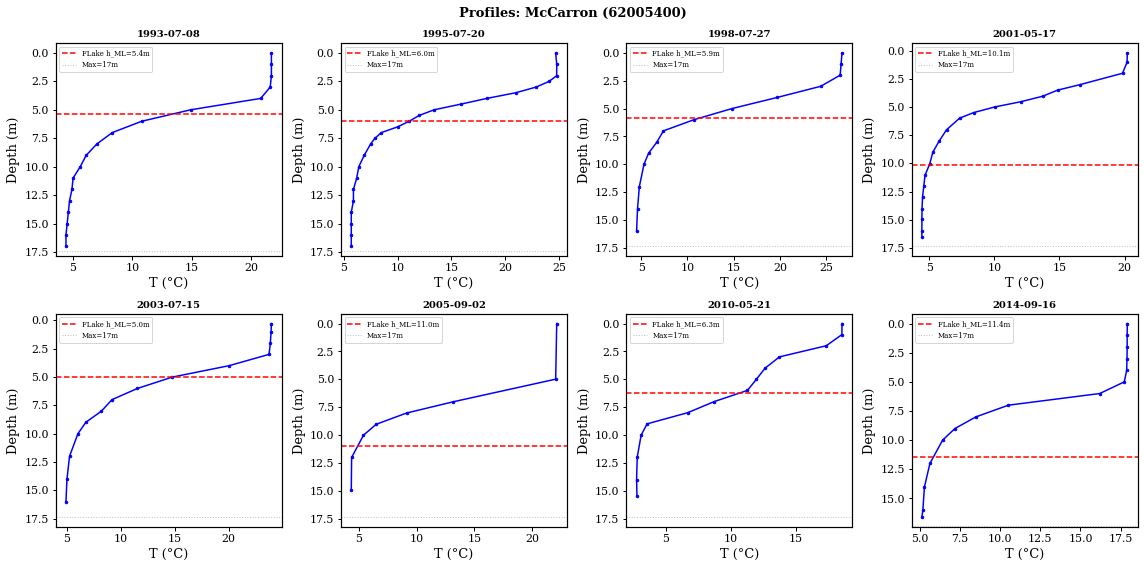

    diag_profiles_62005400.png


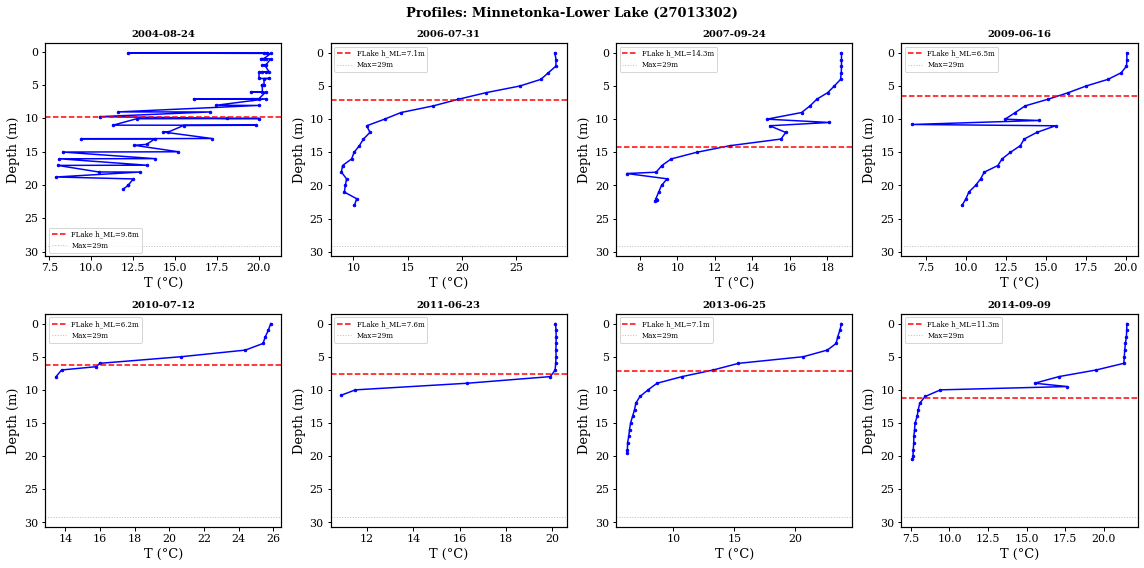

    diag_profiles_27013302.png


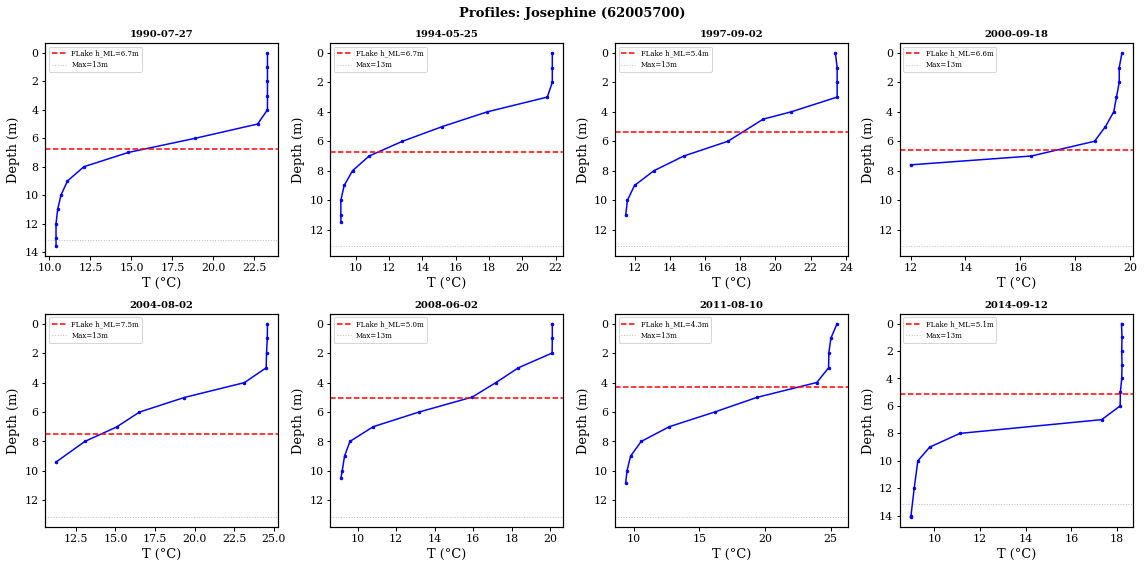

    diag_profiles_62005700.png


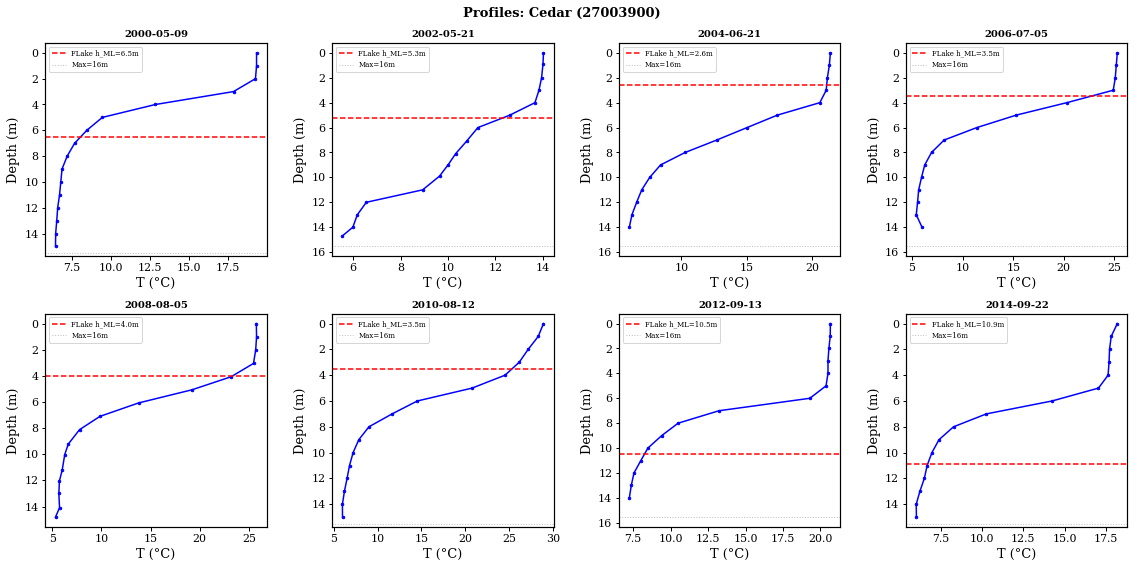

    diag_profiles_27003900.png

--- Thermal validation plots ---

  ┌───────────────────────────────────────────────────────────────────┐
  │ Metric            n      RMSE      Bias      R²      MAE │
  ├───────────────────────────────────────────────────────────────────┤
  │ h_ML           7387     5.02m    +1.73m   0.135    3.48m │
  │ Tm_ML          7387    3.68°C   +0.35°C   0.746   2.94°C │
  │ Tb (bottom)    7387    5.17°C   -2.05°C   0.132   3.86°C │
  └───────────────────────────────────────────────────────────────────┘


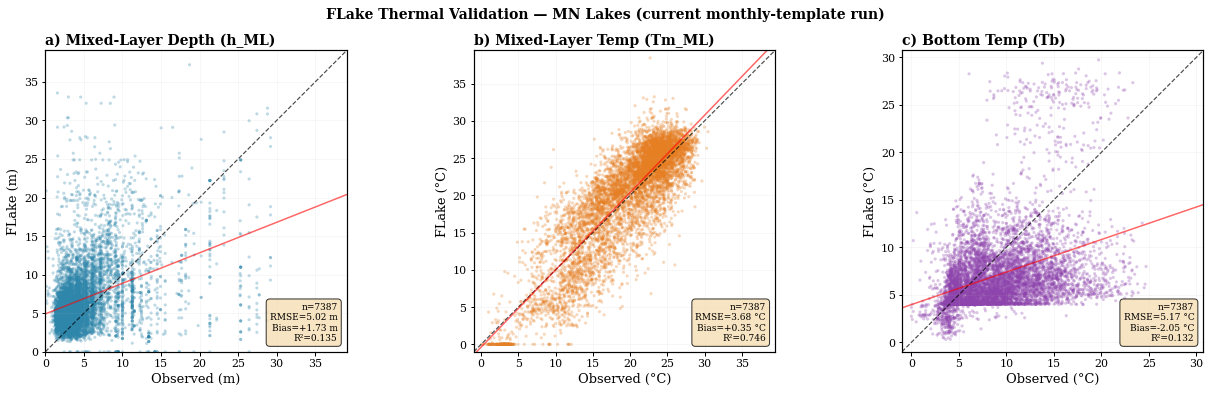

  Saved: thermal_scatter_3panel.png


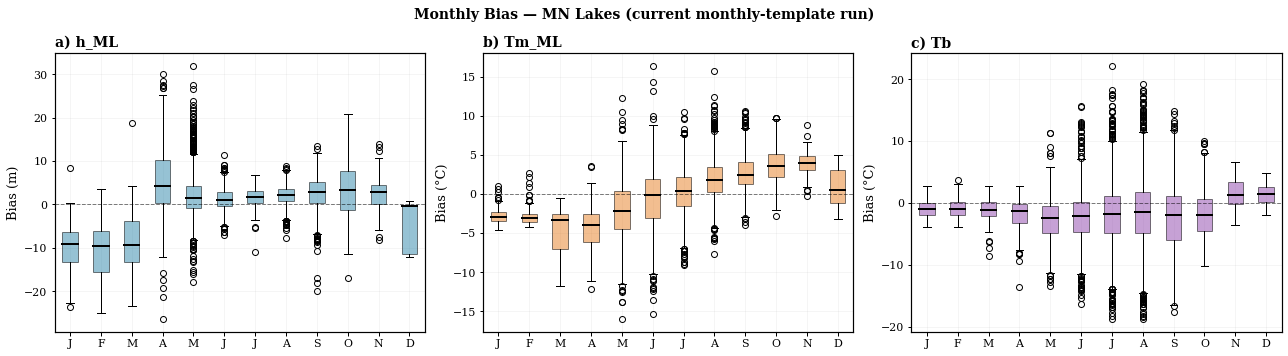

  Saved: thermal_monthly_bias.png
  Saved per-lake metrics CSV (48 lakes)

  ── Metrics by Depth Class ──
    deep        : h_ML n=1403, RMSE=7.59m, Bias=+3.47m, R²=0.098
                  Tm   n=1403, RMSE=4.17°C, Bias=-1.17°C, R²=0.683
                  Tb   n=1403, RMSE=4.10°C, Bias=-1.84°C, R²=0.004
    medium      : h_ML n=5724, RMSE=4.24m, Bias=+1.27m, R²=0.132
                  Tm   n=5724, RMSE=3.55°C, Bias=+0.64°C, R²=0.774
                  Tb   n=5724, RMSE=5.23°C, Bias=-2.42°C, R²=0.069
    shallow     : h_ML n=260, RMSE=2.86m, Bias=+2.39m, R²=0.001
                  Tm   n=260, RMSE=3.74°C, Bias=+2.22°C, R²=0.702
                  Tb   n=260, RMSE=8.16°C, Bias=+5.05°C, R²=0.275

  ── Metrics by Trophic Class ──
    eutrophic     : h_ML n=1752, RMSE=3.68m, Bias=-0.00m, R²=0.129
                    Tm   n=1752, RMSE=3.46°C, Bias=+0.97°C, R²=0.826
                    Tb   n=1752, RMSE=5.66°C, Bias=-3.31°C, R²=0.117
    mesotrophic   : h_ML n=5096, RMSE=5.06m, Bias=+2.00m, R²=

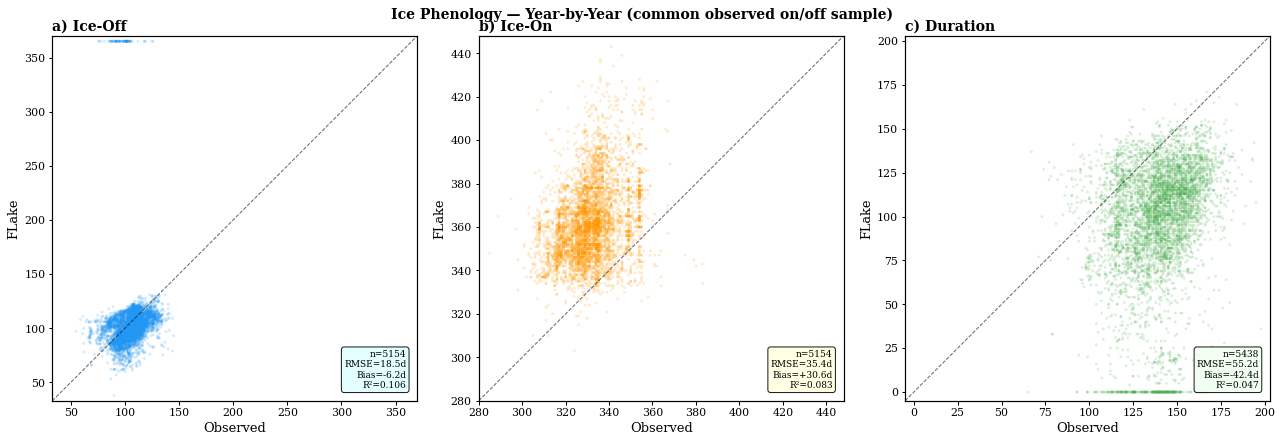

  Saved: ice_yby_scatter.png

  ── CLIMATOLOGICAL VALIDATION ──


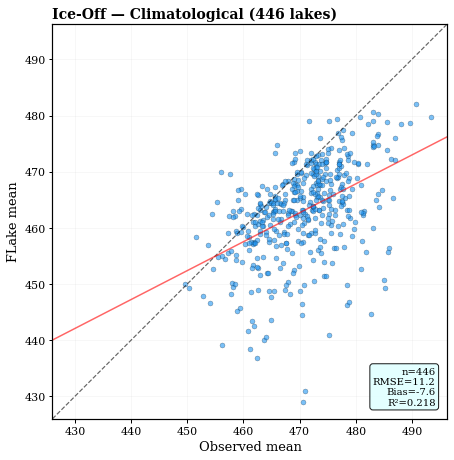

  Saved: ice_clim_ice_off.png


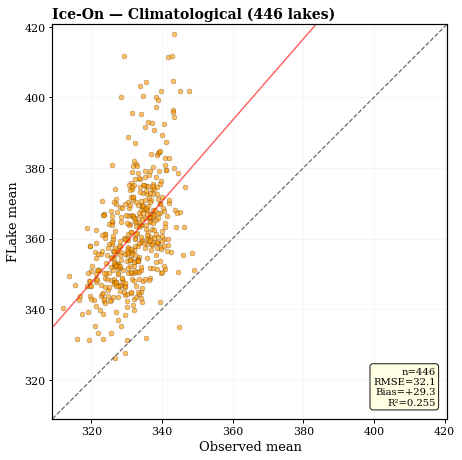

  Saved: ice_clim_ice_on.png


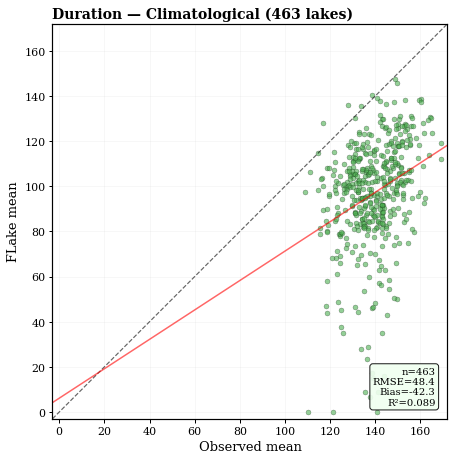

  Saved: ice_clim_duration.png

  ── Ice-off time series ──


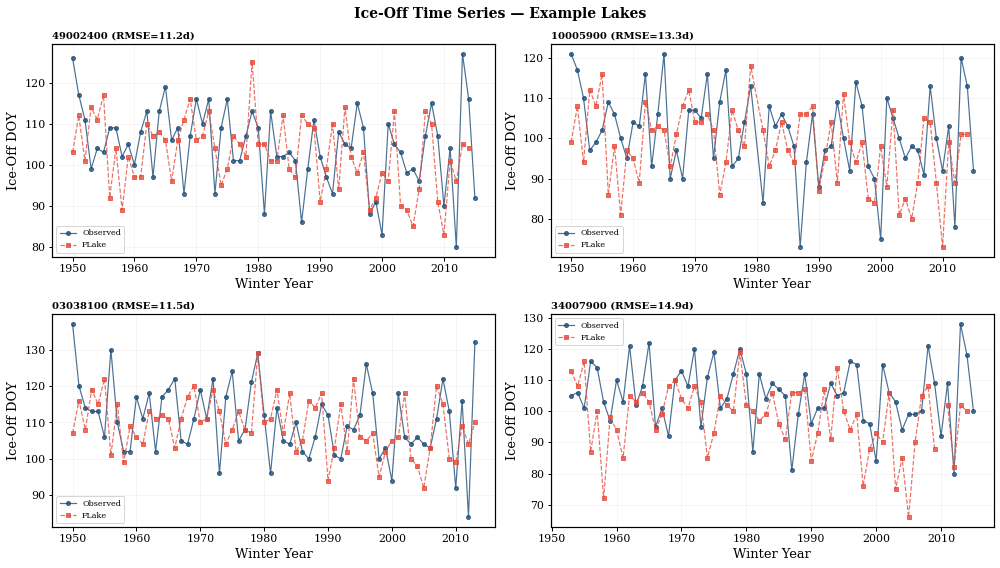

  Saved: ice_timeseries.png

  ── Ice thickness time series ──


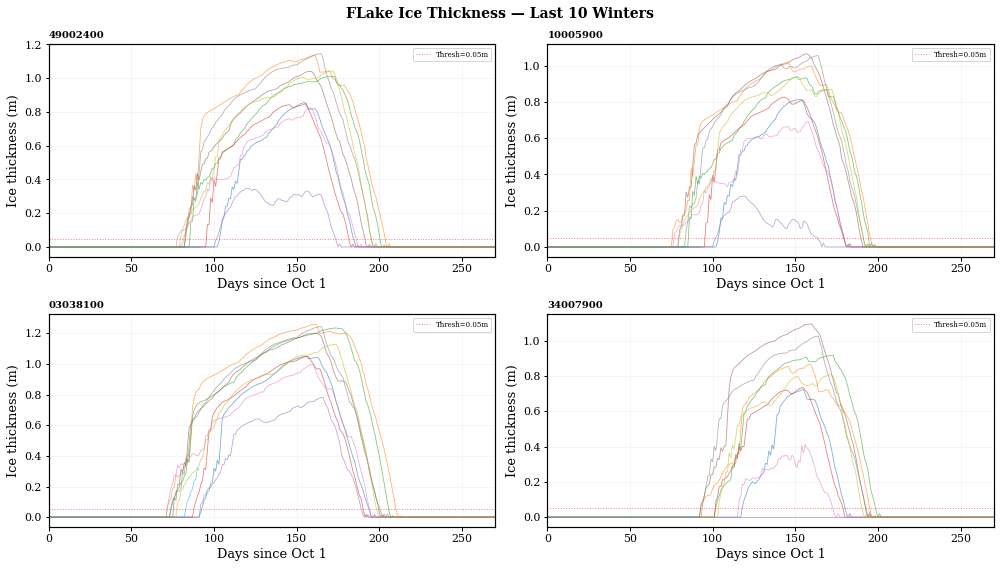

  Saved: ice_thickness_timeseries.png

────────────────────────────────────────────────────────────
  ICE PHENOLOGY SUMMARY
────────────────────────────────────────────────────────────
  ice_off_yby          (year-by-year  ): RMSE=18.5d, Bias=-6.2d, R²=0.106 (n=5154)
  ice_on_yby           (year-by-year  ): RMSE=35.4d, Bias=+30.6d, R²=0.083 (n=5154)
  duration_yby         (year-by-year  ): RMSE=55.2d, Bias=-42.4d, R²=0.047 (n=5438)
  ice_off_clim         (CLIMATOLOGICAL): RMSE=11.2d, Bias=-7.6d, R²=0.218 (n=446)
  ice_on_clim          (CLIMATOLOGICAL): RMSE=32.1d, Bias=+29.3d, R²=0.255 (n=446)
  duration_clim        (CLIMATOLOGICAL): RMSE=48.4d, Bias=-42.3d, R²=0.089 (n=463)

  Common-sample check:
    ice-off pairs = 5438
    ice-on  pairs = 5438
    ice-off lakes = 738
    ice-on  lakes = 738

  DONE — all outputs in: /scratch.global/dahal043/flake_output_historical_validation_set_only_kd_earliest


In [1]:
#!/usr/bin/env python3
"""
===============================================================================
FLake VALIDATION — FINAL (CURRENT OUTPUTS + COMMON ICE-ON/OFF SAMPLE)
===============================================================================

WHAT THIS SCRIPT DOES
---------------------
1. THERMAL VALIDATION
   - h_ML   : mixed-layer depth
   - Tm_ML  : mixed-layer mean temperature
   - Tb     : bottom / deepest observed temperature

2. ICE PHENOLOGY VALIDATION
   - Ice-on
   - Ice-off
   - Ice duration

IMPORTANT ICE FIX
-----------------
Ice-on and ice-off are now validated using ONLY lake-years that have BOTH:
  - observed ice-on
  - observed ice-off

So:
  - ice-on and ice-off use the SAME analyzed lake-years
  - unique lakes and sample counts are consistent
  - duration is also restricted to that same common lake-year set

IMPORTANT NOTE
--------------
This validation script DOES NOT control model physics.
It only reads already-generated FLake outputs.
So albedo / optical setup come from the simulation code / FLake engine,
not from this validation script.
===============================================================================
"""

import os
import glob
import warnings
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

warnings.filterwarnings("ignore")

# ═════════════════════════════════════════════════════════════════════════════
# USER CONFIGURATION
# ═════════════════════════════════════════════════════════════════════════════

# -------------------------------------------------------------------------
# CURRENT FLake outputs
# -------------------------------------------------------------------------
FLAKE_OUTPUT_DIR = r"/scratch.global/dahal043/flake_output_historical_earliest_monthly_template_20260325"

# CURRENT Code 1 parameter table
LAKE_PARAMS_CSV = r"/scratch.global/dahal043/flake_inputs_earliest_monthly_template_20260325/flake_lake_parameters.csv"

# Validation output directory
VALIDATION_OUT_DIR = r"/scratch.global/dahal043/flake_output_historical_validation_set_only_kd_earliest"

# -------------------------------------------------------------------------
# Thermal validation data
# -------------------------------------------------------------------------
MASTER_METADATA_CSV = r"/users/6/dahal043/FEB27_VALIDATION_MN_WI_68LAKES/files (1)/pgdl_68_lakes_metadata.csv"
TRAINING_CSV        = r"/users/6/dahal043/FEB27_VALIDATION_MN_WI_68LAKES/files (1)/all_lakes_historical_training.csv"

# -------------------------------------------------------------------------
# Ice phenology data
# -------------------------------------------------------------------------
ICE_PHENO_DIR       = r"/users/6/dahal043/Lake Ice Phenology Data Code/mn_ice_data_March16/merged_output_files"
ICEOUT_TS_CSV       = os.path.join(ICE_PHENO_DIR, "classified_lakes_iceout_timeseries.csv")
ICEIN_TS_CSV        = os.path.join(ICE_PHENO_DIR, "classified_lakes_icein_timeseries.csv")
ICEDUR_TS_CSV       = os.path.join(ICE_PHENO_DIR, "classified_lakes_ice_duration_timeseries.csv")
MN_CLASSIFIED_CSV   = os.path.join(ICE_PHENO_DIR, "mn_lakes_classified_with_ice_phenology.csv")

# ═════════════════════════════════════════════════════════════════════════════
# SETTINGS
# ═════════════════════════════════════════════════════════════════════════════

EXCLUDE_TOP_N          = 1
DT_REL                 = 1.0
MIN_POINTS_PER_PROFILE = 6
MIN_PROFILES_PER_LAKE  = 10

H_ICE_THRESHOLD        = 0.05
N_CONSEC_ICE_DAYS      = 5

N_DIAGNOSTIC_PROFILES  = 8
N_DIAGNOSTIC_LAKES     = 4
N_TIMESERIES_LAKES     = 4
N_ICE_THICKNESS_LAKES  = 4

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.linewidth": 1.2,
    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "figure.facecolor": "white",
    "axes.facecolor": "white",
})

# ═════════════════════════════════════════════════════════════════════════════
# HELPERS
# ═════════════════════════════════════════════════════════════════════════════

def norm_dow(v):
    try:
        return str(int(float(v))).zfill(8)
    except:
        return None

def norm_int(v):
    try:
        return int(float(v))
    except:
        return None

def find_flake(dow, d):
    s = str(dow).zfill(8)
    for p in [f"{s}_flake_historical.csv", f"{int(s)}_flake_historical.csv"]:
        fp = os.path.join(d, p)
        if os.path.exists(fp):
            return fp
    m = glob.glob(os.path.join(d, f"*{s}*flake*historical*.csv"))
    return m[0] if m else None

def doy_circ(pred, obs):
    return ((pred - obs + 182) % 365) - 182

def metrics(obs, pred):
    m = np.isfinite(obs) & np.isfinite(pred)
    o, p = obs[m], pred[m]
    n = len(o)
    if n < 3:
        return dict(
            n=n, RMSE=np.nan, Bias=np.nan, MAE=np.nan,
            R2=np.nan, r=np.nan, slope=np.nan, intercept=np.nan
        )
    b = np.mean(p - o)
    rmse = np.sqrt(np.mean((p - o) ** 2))
    mae = np.mean(np.abs(p - o))
    sl, ic, rv, _, _ = stats.linregress(o, p)
    return dict(
        n=n, RMSE=rmse, Bias=b, MAE=mae,
        R2=rv ** 2, r=rv, slope=sl, intercept=ic
    )

def metrics_circ(obs, pred):
    m = np.isfinite(obs) & np.isfinite(pred)
    o, p = obs[m], pred[m]
    n = len(o)
    if n < 3:
        return dict(
            n=n, RMSE=np.nan, Bias=np.nan, MAE=np.nan,
            R2=np.nan, r=np.nan, slope=np.nan, intercept=np.nan
        )

    d = np.array([doy_circ(pi, oi) for pi, oi in zip(p, o)])
    b = np.mean(d)
    rmse = np.sqrt(np.mean(d ** 2))
    mae = np.mean(np.abs(d))

    ow = np.where(o < 180, o + 365, o)
    pw = np.where(p < 180, p + 365, p)
    if np.std(ow) > 0 and np.std(pw) > 0:
        sl, ic, rv, _, _ = stats.linregress(ow, pw)
        r2 = rv ** 2
    else:
        sl, ic, rv, r2 = [np.nan] * 4

    return dict(
        n=n, RMSE=rmse, Bias=b, MAE=mae,
        R2=r2, r=rv, slope=sl, intercept=ic
    )

def fmt_met(m, unit=""):
    return f"n={m['n']}, RMSE={m['RMSE']:.2f}{unit}, Bias={m['Bias']:+.2f}{unit}, R²={m['R2']:.3f}"

# ═════════════════════════════════════════════════════════════════════════════
# PART A — THERMAL VALIDATION
# ═════════════════════════════════════════════════════════════════════════════

def calc_profile_metrics(
    prof_df,
    exclude_top_n=EXCLUDE_TOP_N,
    dt_rel=DT_REL,
    min_pts=MIN_POINTS_PER_PROFILE,
    max_depth=None
):
    """
    From a single profile, compute:
      h_ML  — mixed-layer depth using ΔT = 1°C threshold
      Tm_ML — depth-averaged mixed-layer temperature
      Tb    — deepest observed temperature
    """
    prof = prof_df[["depth", "temp"]].dropna().copy()
    prof["depth"] = pd.to_numeric(prof["depth"], errors="coerce")
    prof["temp"]  = pd.to_numeric(prof["temp"], errors="coerce")
    prof = prof.dropna().sort_values("depth").drop_duplicates("depth", keep="first")

    if max_depth is not None:
        prof = prof[prof["depth"] <= max_depth].copy()

    if len(prof) < max(min_pts, exclude_top_n + 2):
        return dict(h_ML=np.nan, Tm_ML=np.nan, Tb=np.nan, flag=3)

    z_all = prof["depth"].to_numpy(float)
    T_all = prof["temp"].to_numpy(float)
    Tb = float(T_all[-1])

    if exclude_top_n > 0:
        prof = prof.iloc[exclude_top_n:].copy()

    z = prof["depth"].to_numpy(float)
    T = prof["temp"].to_numpy(float)
    z0, Ts = float(z[0]), float(T[0])
    tgt = Ts - dt_rel

    hml = None
    for i in range(len(T) - 1):
        if T[i] > tgt and T[i + 1] <= tgt and z[i + 1] > z[i]:
            d = T[i] - T[i + 1]
            if d == 0:
                hml = float(z[i + 1])
            else:
                hml = float(z[i] + (z[i + 1] - z[i]) * (T[i] - tgt) / d)
            break

    if hml is None:
        if T[-1] > tgt:
            h = float(max_depth) if max_depth and max_depth > 0 else float(z[-1])
            return dict(h_ML=h, Tm_ML=float(np.mean(T)), Tb=Tb, flag=1)
        else:
            h = float(z[-1])
            t = float(np.trapz(T, z) / (z[-1] - z0)) if z[-1] > z0 else float(np.mean(T))
            return dict(h_ML=h, Tm_ML=t, Tb=Tb, flag=2)

    zn = np.append(z[z < hml], hml)
    Tn = np.append(T[z < hml], tgt)
    if len(zn) < 2 or hml == z0:
        t = float(np.mean(Tn))
    else:
        t = float(np.trapz(Tn, zn) / (hml - z0))

    return dict(h_ML=hml, Tm_ML=t, Tb=Tb, flag=0)

def run_thermal_validation():
    print("\n" + "=" * 70)
    print("  PART A: THERMAL VALIDATION (h_ML, Tm_ML, Tb)")
    print("=" * 70)

    if not os.path.exists(MASTER_METADATA_CSV):
        print("  ERROR: metadata not found")
        return None, None, None

    master = pd.read_csv(MASTER_METADATA_CSV)
    print(f"  Loaded {len(master)} lakes metadata")

    mn = master[(master["state"] == "MN") & master["DOWLKNUM"].notna()].copy()
    mn["DOWLKNUM"] = mn["DOWLKNUM"].apply(norm_dow)
    mn = mn[mn["DOWLKNUM"].notna()]
    print(f"  MN lakes with DOWLKNUM: {len(mn)}")
    if len(mn) == 0:
        return None, None, None

    if not os.path.exists(TRAINING_CSV):
        print("  ERROR: training CSV not found")
        return None, None, None

    train = pd.read_csv(TRAINING_CSV)
    train["date"] = pd.to_datetime(train["date"], errors="coerce")
    print(f"  Loaded {len(train):,} observations across {train['site_id'].nunique()} lakes")

    lake_mean_depth = {}
    if os.path.exists(LAKE_PARAMS_CSV):
        lp = pd.read_csv(LAKE_PARAMS_CSV, dtype={"DOWLKNUM": str})
        lp["DOWLKNUM"] = lp["DOWLKNUM"].str.zfill(8)
        for _, r in lp.iterrows():
            try:
                lake_mean_depth[r["DOWLKNUM"]] = float(r["depth_w"])
            except:
                pass

    print("\n--- Computing observed h_ML, Tm_ML, Tb ---")
    all_obs = []
    for _, lk in mn.iterrows():
        sid = lk["site_id"]
        dow = lk["DOWLKNUM"]
        nm = lk.get("lake_name", sid)

        md = lk.get("LK_MAXDEPT_m", None)
        if pd.isna(md):
            md = None

        ds = train[train["site_id"] == sid].copy()
        if len(ds) == 0:
            continue

        ds["pd"] = ds["date"].dt.date
        nv = 0
        for pd_, g in ds.groupby("pd"):
            r = calc_profile_metrics(g, max_depth=md)
            if r["flag"] in [0, 1, 2] and not np.isnan(r["h_ML"]):
                all_obs.append(dict(
                    site_id=sid,
                    DOWLKNUM=dow,
                    lake_name=nm,
                    date=pd.Timestamp(pd_),
                    obs_h_ML=r["h_ML"],
                    obs_Tm_ML=r["Tm_ML"],
                    obs_Tb=r["Tb"],
                    flag=r["flag"],
                    depth_class=lk.get("DEPTH_CLASS", "?"),
                    trophic_class=lk.get("TROPHIC_CLASS", "?"),
                    max_depth=md if md is not None else np.nan,
                    mean_depth=lake_mean_depth.get(dow, np.nan),
                ))
                nv += 1

        if nv > 0:
            print(f"    {str(nm):25s} ({dow}): {nv:4d} profiles")

    if not all_obs:
        print("  No observed thermal profiles survived.")
        return None, train, mn

    obs = pd.DataFrame(all_obs)
    obs["date"] = pd.to_datetime(obs["date"])
    obs["Year"] = obs["date"].dt.year
    obs["Month"] = obs["date"].dt.month
    obs["DayOfYear"] = obs["date"].dt.dayofyear

    n0 = int((obs["flag"] == 0).sum())
    n1 = int((obs["flag"] == 1).sum())
    n2 = int((obs["flag"] == 2).sum())
    print(f"\n  Total profiles: {len(obs)} | flag0={n0} flag1={n1} flag2={n2}")

    lc = obs.groupby("DOWLKNUM").size()
    obs = obs[obs["DOWLKNUM"].isin(lc[lc >= MIN_PROFILES_PER_LAKE].index)].copy()
    print(f"  After minimum-profile filter: {len(obs)} records, {obs['DOWLKNUM'].nunique()} lakes")

    print("\n--- Matching thermal observations with FLake ---")
    paired = []
    for dow in obs["DOWLKNUM"].unique():
        fp = find_flake(dow, FLAKE_OUTPUT_DIR)
        if fp is None:
            continue

        try:
            fdf = pd.read_csv(fp)
            fdf["Date"] = pd.to_datetime(fdf["Date"], errors="coerce")
        except:
            continue

        if "Ts" in fdf.columns:
            if fdf["Ts"].mean() > 200:
                for c in ["Ts", "Tm", "Tb"]:
                    if c in fdf.columns:
                        fdf[c + "_C"] = fdf[c] - 273.15
            else:
                for c in ["Ts", "Tm", "Tb"]:
                    if c in fdf.columns:
                        fdf[c + "_C"] = fdf[c]

        for _, o in obs[obs["DOWLKNUM"] == dow].iterrows():
            fl = fdf[fdf["Date"].dt.date == o["date"].date()]
            if len(fl) == 0:
                continue
            fl = fl.iloc[0]

            try:
                paired.append({
                    **{k: o[k] for k in [
                        "DOWLKNUM", "lake_name", "date", "Year", "Month",
                        "DayOfYear", "obs_h_ML", "obs_Tm_ML", "obs_Tb", "flag",
                        "depth_class", "trophic_class", "max_depth", "mean_depth"
                    ]},
                    "flake_h_ML":  float(fl.get("h_ML", np.nan)),
                    "flake_Ts_C":  float(fl.get("Ts_C", np.nan)),
                    "flake_Tm_C":  float(fl.get("Tm_C", np.nan)),
                    "flake_Tb_C":  float(fl.get("Tb_C", np.nan)),
                    "flake_H_ice": float(fl.get("H_ice", np.nan)),
                })
            except (ValueError, TypeError):
                continue

    if not paired:
        print("  No paired thermal records found.")
        return None, train, mn

    pdf = pd.DataFrame(paired)
    pdf["date"] = pd.to_datetime(pdf["date"])

    # Keep same behavior as your existing script
    pdf["flake_Tm_ML"] = pdf["flake_Ts_C"]

    print(f"  Paired thermal records: {len(pdf)}, Lakes: {pdf['DOWLKNUM'].nunique()}")
    return pdf, train, mn

def plot_thermal_all(pdf, out_dir):
    print("\n--- Thermal validation plots ---")
    os.makedirs(out_dir, exist_ok=True)

    mh = metrics(pdf["obs_h_ML"].values, pdf["flake_h_ML"].values)
    mt = metrics(pdf["obs_Tm_ML"].values, pdf["flake_Tm_ML"].values)
    mb = metrics(pdf["obs_Tb"].values, pdf["flake_Tb_C"].values)

    print(f"\n  ┌───────────────────────────────────────────────────────────────────┐")
    print(f"  │ {'Metric':<12s} {'n':>6s}  {'RMSE':>8s}  {'Bias':>8s}  {'R²':>6s}  {'MAE':>7s} │")
    print(f"  ├───────────────────────────────────────────────────────────────────┤")
    print(f"  │ {'h_ML':<12s} {mh['n']:>6d}  {mh['RMSE']:>7.2f}m  {mh['Bias']:>+7.2f}m  {mh['R2']:>6.3f}  {mh['MAE']:>6.2f}m │")
    print(f"  │ {'Tm_ML':<12s} {mt['n']:>6d}  {mt['RMSE']:>6.2f}°C  {mt['Bias']:>+6.2f}°C  {mt['R2']:>6.3f}  {mt['MAE']:>5.2f}°C │")
    print(f"  │ {'Tb (bottom)':<12s} {mb['n']:>6d}  {mb['RMSE']:>6.2f}°C  {mb['Bias']:>+6.2f}°C  {mb['R2']:>6.3f}  {mb['MAE']:>5.2f}°C │")
    print(f"  └───────────────────────────────────────────────────────────────────┘")

    fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
    configs = [
        (axes[0], "obs_h_ML",  "flake_h_ML",  "m",  "Mixed-Layer Depth (h_ML)", "#2E86AB", "a"),
        (axes[1], "obs_Tm_ML", "flake_Tm_ML", "°C", "Mixed-Layer Temp (Tm_ML)",  "#E67E22", "b"),
        (axes[2], "obs_Tb",    "flake_Tb_C",  "°C", "Bottom Temp (Tb)",          "#8E44AD", "c"),
    ]

    for ax, xk, yk, unit, lbl, color, panel in configs:
        x, y = pdf[xk].values, pdf[yk].values
        m = np.isfinite(x) & np.isfinite(y)
        xc, yc = x[m], y[m]
        met = metrics(x, y)

        ax.scatter(xc, yc, s=10, alpha=0.3, c=color, edgecolors="none")

        if xk == "obs_h_ML":
            lo, hi = 0, max(xc.max(), yc.max()) * 1.05
        else:
            lo = min(xc.min(), yc.min()) - 1
            hi = max(xc.max(), yc.max()) + 1

        ax.plot([lo, hi], [lo, hi], "k--", lw=1.2, alpha=0.7)

        if met["n"] > 3:
            xf = np.linspace(lo, hi, 100)
            ax.plot(xf, met["slope"] * xf + met["intercept"], "r-", lw=1.5, alpha=0.6)

        ax.set_xlim(lo, hi)
        ax.set_ylim(lo, hi)
        ax.set_aspect("equal")
        ax.set_xlabel(f"Observed ({unit})")
        ax.set_ylabel(f"FLake ({unit})")
        ax.set_title(f"{panel}) {lbl}", loc="left")

        txt = f"n={met['n']}\nRMSE={met['RMSE']:.2f} {unit}\nBias={met['Bias']:+.2f} {unit}\nR²={met['R2']:.3f}"
        ax.text(
            0.97, 0.03, txt,
            transform=ax.transAxes,
            ha="right", va="bottom", fontsize=9,
            bbox=dict(boxstyle="round,pad=0.4", fc="wheat", alpha=0.8)
        )
        ax.grid(alpha=0.12)

    plt.suptitle("FLake Thermal Validation — MN Lakes (current monthly-template run)", fontsize=14, fontweight="bold")
    plt.tight_layout()
    fig.savefig(os.path.join(out_dir, "thermal_scatter_3panel.png"), dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print("  Saved: thermal_scatter_3panel.png")

    pdf["hb"] = pdf["flake_h_ML"] - pdf["obs_h_ML"]
    pdf["tb_bias"] = pdf["flake_Tm_ML"] - pdf["obs_Tm_ML"]
    pdf["bb"] = pdf["flake_Tb_C"] - pdf["obs_Tb"]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    mn_names = ["J", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D"]

    for ax, col, yl, tl, clr in [
        (axes[0], "hb",      "Bias (m)",  "a) h_ML",  "#2E86AB"),
        (axes[1], "tb_bias", "Bias (°C)", "b) Tm_ML", "#E67E22"),
        (axes[2], "bb",      "Bias (°C)", "c) Tb",    "#8E44AD")
    ]:
        gs, ls = [], []
        for mo in range(1, 13):
            v = pdf.loc[pdf["Month"] == mo, col].dropna().values
            if len(v) > 0:
                gs.append(v)
                ls.append(mn_names[mo - 1])
        if gs:
            bp = ax.boxplot(gs, labels=ls, patch_artist=True, medianprops=dict(color="black", lw=2))
            for p in bp["boxes"]:
                p.set_facecolor(clr)
                p.set_alpha(0.5)
        ax.axhline(0, color="black", lw=1, ls="--", alpha=0.5)
        ax.set_ylabel(yl)
        ax.set_title(tl, loc="left")
        ax.grid(alpha=0.15)

    plt.suptitle("Monthly Bias — MN Lakes (current monthly-template run)", fontsize=14, fontweight="bold")
    plt.tight_layout()
    fig.savefig(os.path.join(out_dir, "thermal_monthly_bias.png"), dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print("  Saved: thermal_monthly_bias.png")

    lm = []
    for dow, g in pdf.groupby("DOWLKNUM"):
        mh_l = metrics(g["obs_h_ML"].values, g["flake_h_ML"].values)
        mt_l = metrics(g["obs_Tm_ML"].values, g["flake_Tm_ML"].values)
        mb_l = metrics(g["obs_Tb"].values, g["flake_Tb_C"].values)
        if mh_l["n"] < 3:
            continue
        lm.append(dict(
            DOWLKNUM=dow,
            lake_name=g["lake_name"].iloc[0],
            n=mh_l["n"],
            depth_class=g["depth_class"].iloc[0],
            trophic_class=g["trophic_class"].iloc[0],
            mean_depth=g["mean_depth"].iloc[0],
            hML_RMSE=mh_l["RMSE"], hML_Bias=mh_l["Bias"], hML_R2=mh_l["R2"],
            TmML_RMSE=mt_l["RMSE"], TmML_Bias=mt_l["Bias"], TmML_R2=mt_l["R2"],
            Tb_RMSE=mb_l["RMSE"], Tb_Bias=mb_l["Bias"], Tb_R2=mb_l["R2"]
        ))

    lm_df = pd.DataFrame(lm).sort_values("TmML_RMSE")
    lm_df.to_csv(os.path.join(out_dir, "thermal_per_lake_metrics.csv"), index=False)
    print(f"  Saved per-lake metrics CSV ({len(lm_df)} lakes)")

    print("\n  ── Metrics by Depth Class ──")
    for dc in sorted(pdf["depth_class"].dropna().unique()):
        g = pdf[pdf["depth_class"] == dc]
        if len(g) < 5:
            continue
        mh_c = metrics(g["obs_h_ML"].values, g["flake_h_ML"].values)
        mt_c = metrics(g["obs_Tm_ML"].values, g["flake_Tm_ML"].values)
        mb_c = metrics(g["obs_Tb"].values, g["flake_Tb_C"].values)
        print(f"    {dc:12s}: h_ML {fmt_met(mh_c, 'm')}")
        print(f"    {'':12s}  Tm   {fmt_met(mt_c, '°C')}")
        print(f"    {'':12s}  Tb   {fmt_met(mb_c, '°C')}")

    print("\n  ── Metrics by Trophic Class ──")
    for tc in sorted(pdf["trophic_class"].dropna().unique()):
        g = pdf[pdf["trophic_class"] == tc]
        if len(g) < 5:
            continue
        mh_c = metrics(g["obs_h_ML"].values, g["flake_h_ML"].values)
        mt_c = metrics(g["obs_Tm_ML"].values, g["flake_Tm_ML"].values)
        mb_c = metrics(g["obs_Tb"].values, g["flake_Tb_C"].values)
        print(f"    {tc:14s}: h_ML {fmt_met(mh_c, 'm')}")
        print(f"    {'':14s}  Tm   {fmt_met(mt_c, '°C')}")
        print(f"    {'':14s}  Tb   {fmt_met(mb_c, '°C')}")

    return (mh, mt, mb), lm_df

def plot_diagnostic_profiles(pdf, train, mn_lakes, out_dir):
    print("\n--- Diagnostic profile figures ---")
    os.makedirs(out_dir, exist_ok=True)

    tops = pdf.groupby("DOWLKNUM").size().sort_values(ascending=False).head(N_DIAGNOSTIC_LAKES).index
    for dow in tops:
        lo = pdf[pdf["DOWLKNUM"] == dow]
        nm = lo["lake_name"].iloc[0]

        sid_row = mn_lakes[mn_lakes["DOWLKNUM"] == dow]
        if len(sid_row) == 0:
            continue

        sid = sid_row.iloc[0]["site_id"]
        md = sid_row.iloc[0].get("LK_MAXDEPT_m", None)
        if pd.isna(md):
            md = None

        ds = train[train["site_id"] == sid].copy()
        ds["pd"] = ds["date"].dt.date

        summer = lo[(lo["Month"] >= 5) & (lo["Month"] <= 9)]
        if len(summer) < 4:
            summer = lo

        sd = summer["date"].dt.date.unique()
        if len(sd) > N_DIAGNOSTIC_PROFILES:
            sd = sd[np.linspace(0, len(sd) - 1, N_DIAGNOSTIC_PROFILES).astype(int)]

        nc = min(4, len(sd))
        nr = math.ceil(len(sd) / nc)
        fig, axes = plt.subplots(nr, nc, figsize=(4 * nc, 4 * nr), squeeze=False)
        af = axes.ravel()

        for j, d in enumerate(sd):
            if j >= len(af):
                break
            ax = af[j]
            p = ds[ds["pd"] == d].sort_values("depth")
            if len(p) == 0:
                ax.set_visible(False)
                continue

            ax.plot(p["temp"], p["depth"], "b.-", lw=1.5, ms=5)
            ax.invert_yaxis()

            frow = lo[lo["date"].dt.date == d]
            if len(frow) > 0:
                fhml = frow.iloc[0]["flake_h_ML"]
                if np.isfinite(fhml):
                    ax.axhline(fhml, color="red", ls="--", lw=1.5, label=f"FLake h_ML={fhml:.1f}m")

            if md:
                ax.axhline(md, color="gray", ls=":", lw=1, alpha=0.5, label=f"Max={md:.0f}m")

            ax.set_xlabel("T (°C)")
            ax.set_ylabel("Depth (m)")
            ax.set_title(str(d), fontsize=10)
            ax.legend(fontsize=7)

        for j in range(len(sd), len(af)):
            af[j].set_visible(False)

        plt.suptitle(f"Profiles: {nm} ({dow})", fontsize=13, fontweight="bold")
        plt.tight_layout()
        fn = f"diag_profiles_{dow}.png"
        fig.savefig(os.path.join(out_dir, fn), dpi=200, bbox_inches="tight")
        plt.show()
        plt.close(fig)
        print(f"    {fn}")

# ═════════════════════════════════════════════════════════════════════════════
# PART B — ICE PHENOLOGY
# ═════════════════════════════════════════════════════════════════════════════

def extract_ice_pheno(flake_df, thresh=H_ICE_THRESHOLD, n_consec=N_CONSEC_ICE_DAYS):
    df = flake_df[["Date", "Year", "Month", "DayOfYear", "H_ice"]].copy()
    df["Date"] = pd.to_datetime(df["Date"])
    df["ice"] = (df["H_ice"] >= thresh).astype(int)
    df["winter_year"] = df["Date"].apply(lambda d: d.year + 1 if d.month >= 7 else d.year)

    recs = []
    for wy, w in df.groupby("winter_year"):
        w = w.sort_values("Date").reset_index(drop=True)
        ice = w["ice"].values
        n = len(ice)

        runs = []
        i = 0
        while i < n:
            if ice[i] == 1:
                j = i
                while j < n and ice[j] == 1:
                    j += 1
                if j - i >= n_consec:
                    runs.append((i, j - 1))
                i = j
            else:
                i += 1

        if not runs:
            recs.append(dict(
                winter_year=wy,
                flake_ice_on_date=pd.NaT,
                flake_ice_off_date=pd.NaT,
                flake_ice_on_doy=np.nan,
                flake_ice_off_doy=np.nan,
                flake_duration=0
            ))
            continue

        on_idx = runs[0][0]
        on_date = w.loc[on_idx, "Date"]

        off_idx = runs[-1][1]
        off_date = w.loc[off_idx + 1, "Date"] if off_idx + 1 < len(w) else w.loc[off_idx, "Date"]

        recs.append(dict(
            winter_year=wy,
            flake_ice_on_date=on_date,
            flake_ice_off_date=off_date,
            flake_ice_on_doy=on_date.timetuple().tm_yday,
            flake_ice_off_doy=off_date.timetuple().tm_yday,
            flake_duration=(off_date - on_date).days
        ))

    return pd.DataFrame(recs)

def run_ice_validation():
    print("\n" + "=" * 70)
    print("  PART B: ICE PHENOLOGY (COMMON ICE-ON/OFF LAKE-YEARS)")
    print("=" * 70)

    if not os.path.exists(ICEOUT_TS_CSV) or not os.path.exists(ICEIN_TS_CSV):
        print("  ERROR: both iceout and icein files are required")
        return None, None, None

    # ---------------------------------------------------------------------
    # Read observed ice-off and ice-on
    # ---------------------------------------------------------------------
    df_out_obs = pd.read_csv(ICEOUT_TS_CSV)
    df_in_obs  = pd.read_csv(ICEIN_TS_CSV)

    df_out_obs["lake_id_int"] = df_out_obs["DOW"].apply(norm_int)
    df_in_obs["lake_id_int"]  = df_in_obs["DOW"].apply(norm_int)

    df_out_obs["DOWLKNUM"] = df_out_obs["lake_id_int"].apply(lambda x: str(x).zfill(8) if pd.notna(x) else None)
    df_in_obs["DOWLKNUM"]  = df_in_obs["lake_id_int"].apply(lambda x: str(x).zfill(8) if pd.notna(x) else None)

    df_out_obs["winter_year"] = pd.to_numeric(df_out_obs["winter.year"], errors="coerce").astype("Int64")
    df_in_obs["winter_year"]  = pd.to_numeric(df_in_obs["winter.year"], errors="coerce").astype("Int64")

    df_out_obs["obs_iceoff_doy"] = pd.to_numeric(df_out_obs["min_ice_off_julian"], errors="coerce")
    df_in_obs["obs_iceon_doy"]   = pd.to_numeric(df_in_obs["min_ice_on_julian"], errors="coerce")

    df_out_obs = df_out_obs.dropna(subset=["DOWLKNUM", "winter_year", "obs_iceoff_doy"]).copy()
    df_in_obs  = df_in_obs.dropna(subset=["DOWLKNUM", "winter_year", "obs_iceon_doy"]).copy()

    # ---------------------------------------------------------------------
    # CRITICAL FIX:
    # Keep only lake-years with BOTH observed ice-on and observed ice-off
    # ---------------------------------------------------------------------
    common_obs = df_out_obs[[
        "DOWLKNUM", "winter_year", "obs_iceoff_doy", "min_ice_off_date"
    ]].merge(
        df_in_obs[[
            "DOWLKNUM", "winter_year", "obs_iceon_doy", "min_ice_on_date"
        ]],
        on=["DOWLKNUM", "winter_year"],
        how="inner"
    )

    print(f"  Common observed lake-years with BOTH on/off: {len(common_obs)}")
    print(f"  Unique lakes in common on/off set: {common_obs['DOWLKNUM'].nunique()}")

    # Duration file optional, but later restricted to same common lake-years
    df_dur_obs = None
    if os.path.exists(ICEDUR_TS_CSV):
        df_dur_obs = pd.read_csv(ICEDUR_TS_CSV)
        df_dur_obs["lake_id_int"] = df_dur_obs["DOW"].apply(norm_int)
        df_dur_obs["DOWLKNUM"] = df_dur_obs["lake_id_int"].apply(lambda x: str(x).zfill(8) if pd.notna(x) else None)
        df_dur_obs["winter_year"] = pd.to_numeric(df_dur_obs["winter.year"], errors="coerce").astype("Int64")
        df_dur_obs["obs_duration"] = pd.to_numeric(df_dur_obs["max_duration"], errors="coerce")
        df_dur_obs = df_dur_obs.dropna(subset=["DOWLKNUM", "winter_year", "obs_duration"]).copy()

    lake_classes = {}
    if os.path.exists(MN_CLASSIFIED_CSV):
        cl = pd.read_csv(MN_CLASSIFIED_CSV)
        cl["DOWLKNUM"] = cl["DOWLKNUM"].apply(norm_dow)
        for _, r in cl.iterrows():
            lake_classes[r["DOWLKNUM"]] = dict(
                depth_class=r.get("DEPTH_CLASS", "?"),
                trophic_class=r.get("TROPHIC_CLASS", "?"),
                max_depth=r.get("LK_MAXDEPT", np.nan)
            )

    paired_out = []
    paired_in  = []
    paired_dur = []

    matched_lakes = 0
    unmatched_lakes = 0

    for dow in sorted(common_obs["DOWLKNUM"].unique()):
        fp = find_flake(dow, FLAKE_OUTPUT_DIR)
        if fp is None:
            unmatched_lakes += 1
            continue

        try:
            fdf = pd.read_csv(fp)
            fdf["Date"] = pd.to_datetime(fdf["Date"], errors="coerce")
        except:
            unmatched_lakes += 1
            continue

        if "H_ice" not in fdf.columns:
            unmatched_lakes += 1
            continue

        matched_lakes += 1
        fice = extract_ice_pheno(fdf)
        lc = lake_classes.get(dow, {})

        g_common = common_obs[common_obs["DOWLKNUM"] == dow].copy()

        # Build BOTH ice-off and ice-on from the same common lake-year table
        for _, r in g_common.iterrows():
            wy = int(r["winter_year"])
            fm = fice[fice["winter_year"] == wy]
            if len(fm) == 0:
                continue
            fm = fm.iloc[0]

            paired_out.append(dict(
                DOWLKNUM=dow,
                winter_year=wy,
                obs_doy=float(r["obs_iceoff_doy"]),
                flake_doy=fm["flake_ice_off_doy"],
                obs_date=str(r.get("min_ice_off_date", "")),
                flake_date=str(fm["flake_ice_off_date"])[:10],
                **lc
            ))

            paired_in.append(dict(
                DOWLKNUM=dow,
                winter_year=wy,
                obs_doy=float(r["obs_iceon_doy"]),
                flake_doy=fm["flake_ice_on_doy"],
                obs_date=str(r.get("min_ice_on_date", "")),
                flake_date=str(fm["flake_ice_on_date"])[:10],
                **lc
            ))

        # Duration also restricted to same common lake-year set
        if df_dur_obs is not None:
            g_dur = df_dur_obs[df_dur_obs["DOWLKNUM"] == dow].copy()
            g_dur = g_dur.merge(
                g_common[["DOWLKNUM", "winter_year"]],
                on=["DOWLKNUM", "winter_year"],
                how="inner"
            )

            for _, r in g_dur.iterrows():
                wy = int(r["winter_year"])
                fm = fice[fice["winter_year"] == wy]
                if len(fm) == 0:
                    continue
                fm = fm.iloc[0]
                paired_dur.append(dict(
                    DOWLKNUM=dow,
                    winter_year=wy,
                    obs_dur=float(r["obs_duration"]),
                    flake_dur=fm["flake_duration"],
                    **lc
                ))

    print(f"\n  Matched FLake lakes: {matched_lakes}")
    print(f"  Unmatched FLake lakes: {unmatched_lakes}")

    df_out = pd.DataFrame(paired_out) if paired_out else None
    df_in  = pd.DataFrame(paired_in) if paired_in else None
    df_dur = pd.DataFrame(paired_dur) if paired_dur else None

    if df_out is not None and len(df_out) > 0:
        print(f"  Ice-off pairs: {len(df_out)}")
        print(f"  Unique lakes in ice-off: {df_out['DOWLKNUM'].nunique()}")

    if df_in is not None and len(df_in) > 0:
        print(f"  Ice-on pairs: {len(df_in)}")
        print(f"  Unique lakes in ice-on: {df_in['DOWLKNUM'].nunique()}")

    if df_out is not None and df_in is not None and len(df_out) == len(df_in):
        print("  Ice-on and ice-off counts are aligned on the same common lake-year sample.")

    if df_dur is not None:
        print(f"  Duration pairs (same common set): {len(df_dur)}")

    return df_out, df_in, df_dur

def plot_ice_all(df_out, df_in, df_dur, out_dir):
    print("\n--- Ice phenology plots ---")
    os.makedirs(out_dir, exist_ok=True)

    all_met = {}
    datasets = []

    if df_out is not None and len(df_out) > 0:
        datasets.append(("Ice-Off", df_out, "obs_doy", "flake_doy", "#2196F3", "lightcyan", False))
    if df_in is not None and len(df_in) > 0:
        datasets.append(("Ice-On", df_in, "obs_doy", "flake_doy", "#FF9800", "lightyellow", True))
    if df_dur is not None and len(df_dur) > 0:
        datasets.append(("Duration", df_dur, "obs_dur", "flake_dur", "#4CAF50", "honeydew", False))

    n = len(datasets)
    if n == 0:
        print("  No ice datasets available to plot.")
        return all_met

    fig, axes = plt.subplots(1, n, figsize=(6 * n, 6))
    if n == 1:
        axes = [axes]

    for i, (lab, df, ok, pk, clr, bg, wrap) in enumerate(datasets):
        ax = axes[i]
        x, y = df[ok].values.astype(float), df[pk].values.astype(float)
        m = np.isfinite(x) & np.isfinite(y)
        xc, yc = x[m], y[m]

        if wrap:
            mt = metrics_circ(x, y)
            xp = np.where(xc < 180, xc + 365, xc)
            yp = np.where(yc < 180, yc + 365, yc)
            ax.scatter(xp, yp, s=8, alpha=0.2, c=clr, edgecolors="none")
            lo, hi = min(xp.min(), yp.min()) - 5, max(xp.max(), yp.max()) + 5
        else:
            mt = metrics(x, y) if lab == "Duration" else metrics_circ(x, y)
            ax.scatter(xc, yc, s=8, alpha=0.2, c=clr, edgecolors="none")
            lo, hi = min(xc.min(), yc.min()) - 5, max(xc.max(), yc.max()) + 5

        ax.plot([lo, hi], [lo, hi], "k--", lw=1, alpha=0.6)
        ax.set_xlim(lo, hi)
        ax.set_ylim(lo, hi)
        ax.set_aspect("equal")
        ax.set_xlabel("Observed")
        ax.set_ylabel("FLake")
        ax.set_title(f"{'abc'[i]}) {lab}", loc="left")
        ax.text(
            0.97, 0.03,
            f"n={mt['n']}\nRMSE={mt['RMSE']:.1f}d\nBias={mt['Bias']:+.1f}d\nR²={mt['R2']:.3f}",
            transform=ax.transAxes,
            ha="right", va="bottom", fontsize=9,
            bbox=dict(boxstyle="round", fc=bg, alpha=0.9)
        )
        all_met[lab.lower().replace("-", "_") + "_yby"] = mt

    plt.suptitle("Ice Phenology — Year-by-Year (common observed on/off sample)", fontsize=14, fontweight="bold")
    plt.tight_layout()
    fig.savefig(os.path.join(out_dir, "ice_yby_scatter.png"), dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print("  Saved: ice_yby_scatter.png")

    print("\n  ── CLIMATOLOGICAL VALIDATION ──")
    for lab, df, ok, pk, clr, bg, wrap in datasets:
        if df is None or len(df) == 0:
            continue

        lake_means = []
        for dow, g in df.groupby("DOWLKNUM"):
            x, y = g[ok].values.astype(float), g[pk].values.astype(float)
            m = np.isfinite(x) & np.isfinite(y)
            if m.sum() < 3:
                continue

            if lab == "Duration":
                lake_means.append(dict(
                    DOWLKNUM=dow,
                    obs_mean=np.mean(x[m]),
                    flake_mean=np.mean(y[m]),
                    n=int(m.sum())
                ))
            else:
                ox = x[m]
                fx = y[m]
                ox_w = np.where(ox < 180, ox + 365, ox)
                fx_w = np.where(fx < 180, fx + 365, fx)
                lake_means.append(dict(
                    DOWLKNUM=dow,
                    obs_mean=np.mean(ox_w),
                    flake_mean=np.mean(fx_w),
                    n=int(m.sum())
                ))

        if not lake_means:
            continue

        lm = pd.DataFrame(lake_means)
        mt = metrics(lm["obs_mean"].values, lm["flake_mean"].values)
        all_met[lab.lower().replace("-", "_") + "_clim"] = mt

        fig, ax = plt.subplots(figsize=(6.5, 6.5))
        ax.scatter(
            lm["obs_mean"], lm["flake_mean"],
            s=25, alpha=0.6, c=clr,
            edgecolors="black", lw=0.3
        )

        lo = min(lm["obs_mean"].min(), lm["flake_mean"].min()) - 3
        hi = max(lm["obs_mean"].max(), lm["flake_mean"].max()) + 3
        ax.plot([lo, hi], [lo, hi], "k--", lw=1.2, alpha=0.6)

        if mt["n"] > 3:
            xf = np.linspace(lo, hi, 100)
            ax.plot(xf, mt["slope"] * xf + mt["intercept"], "r-", lw=1.5, alpha=0.6)

        ax.set_xlim(lo, hi)
        ax.set_ylim(lo, hi)
        ax.set_aspect("equal")
        ax.set_xlabel("Observed mean")
        ax.set_ylabel("FLake mean")
        ax.set_title(f"{lab} — Climatological ({len(lm)} lakes)", loc="left")
        ax.text(
            0.97, 0.03,
            f"n={mt['n']}\nRMSE={mt['RMSE']:.1f}\nBias={mt['Bias']:+.1f}\nR²={mt['R2']:.3f}",
            transform=ax.transAxes,
            ha="right", va="bottom", fontsize=10,
            bbox=dict(boxstyle="round", fc=bg, alpha=0.9)
        )
        ax.grid(alpha=0.12)

        plt.tight_layout()
        fn = f"ice_clim_{lab.lower().replace('-', '_')}.png"
        fig.savefig(os.path.join(out_dir, fn), dpi=300, bbox_inches="tight")
        plt.show()
        plt.close(fig)
        print(f"  Saved: {fn}")

    if df_out is not None and len(df_out) > 0:
        print("\n  ── Ice-off time series ──")
        lake_n = df_out.groupby("DOWLKNUM").size().sort_values(ascending=False)
        top_dows = lake_n.head(N_TIMESERIES_LAKES).index.tolist()

        nc = 2
        nr = math.ceil(len(top_dows) / nc)
        fig, axes = plt.subplots(nr, nc, figsize=(7 * nc, 4 * nr), squeeze=False)
        af = axes.ravel()

        for i, dow in enumerate(top_dows):
            if i >= len(af):
                break
            ax = af[i]
            g = df_out[df_out["DOWLKNUM"] == dow].sort_values("winter_year")

            ax.plot(g["winter_year"], g["obs_doy"].astype(float), "o-", color="#1F4E79", ms=4, lw=1.2, alpha=0.8, label="Observed")
            ax.plot(g["winter_year"], g["flake_doy"].astype(float), "s--", color="#E74C3C", ms=4, lw=1.2, alpha=0.8, label="FLake")

            mt = metrics_circ(g["obs_doy"].values.astype(float), g["flake_doy"].values.astype(float))
            ax.set_xlabel("Winter Year")
            ax.set_ylabel("Ice-Off DOY")
            ax.set_title(f"{dow} (RMSE={mt['RMSE']:.1f}d)", fontsize=10, loc="left")
            ax.legend(fontsize=8)
            ax.grid(alpha=0.15)

        for j in range(len(top_dows), len(af)):
            af[j].set_visible(False)

        plt.suptitle("Ice-Off Time Series — Example Lakes", fontsize=14, fontweight="bold")
        plt.tight_layout()
        fig.savefig(os.path.join(out_dir, "ice_timeseries.png"), dpi=300, bbox_inches="tight")
        plt.show()
        plt.close(fig)
        print("  Saved: ice_timeseries.png")

    print("\n  ── Ice thickness time series ──")
    if df_out is not None and len(df_out) > 0:
        top_dows = df_out.groupby("DOWLKNUM").size().sort_values(ascending=False).head(N_ICE_THICKNESS_LAKES).index
        nc = 2
        nr = math.ceil(len(top_dows) / nc)
        fig, axes = plt.subplots(nr, nc, figsize=(7 * nc, 4 * nr), squeeze=False)
        af = axes.ravel()

        for i, dow in enumerate(top_dows):
            if i >= len(af):
                break
            ax = af[i]
            fp = find_flake(dow, FLAKE_OUTPUT_DIR)
            if fp is None:
                ax.set_visible(False)
                continue

            try:
                fdf = pd.read_csv(fp)
                fdf["Date"] = pd.to_datetime(fdf["Date"], errors="coerce")
            except:
                ax.set_visible(False)
                continue

            fdf["wy"] = fdf["Date"].apply(lambda d: d.year + 1 if d.month >= 7 else d.year)
            recent_wys = sorted(fdf["wy"].unique())[-10:]

            for wy in recent_wys:
                w = fdf[fdf["wy"] == wy].sort_values("Date")
                oct1 = pd.Timestamp(year=wy - 1, month=10, day=1)
                days = (w["Date"] - oct1).dt.days
                ax.plot(days, w["H_ice"].values, lw=0.8, alpha=0.6)

            ax.set_xlabel("Days since Oct 1")
            ax.set_ylabel("Ice thickness (m)")
            ax.set_title(f"{dow}", fontsize=10, loc="left")
            ax.set_xlim(0, 270)
            ax.grid(alpha=0.15)
            ax.axhline(H_ICE_THRESHOLD, color="red", ls=":", lw=1, alpha=0.5, label=f"Thresh={H_ICE_THRESHOLD}m")
            ax.legend(fontsize=7)

        for j in range(len(top_dows), len(af)):
            af[j].set_visible(False)

        plt.suptitle("FLake Ice Thickness — Last 10 Winters", fontsize=14, fontweight="bold")
        plt.tight_layout()
        fig.savefig(os.path.join(out_dir, "ice_thickness_timeseries.png"), dpi=300, bbox_inches="tight")
        plt.show()
        plt.close(fig)
        print("  Saved: ice_thickness_timeseries.png")

    return all_met

# ═════════════════════════════════════════════════════════════════════════════
# MAIN
# ═════════════════════════════════════════════════════════════════════════════

def main():
    print("=" * 70)
    print("  FLake VALIDATION — CURRENT MONTHLY-TEMPLATE RUN")
    print(f"  FLake dir: {FLAKE_OUTPUT_DIR}")
    print("=" * 70)

    os.makedirs(VALIDATION_OUT_DIR, exist_ok=True)

    # ---------------------------------------------------------------------
    # Thermal
    # ---------------------------------------------------------------------
    thermal, train, mn = run_thermal_validation()

    if thermal is not None and len(thermal) > 0:
        thermal_csv = os.path.join(VALIDATION_OUT_DIR, "validation_thermal.csv")
        thermal.to_csv(thermal_csv, index=False)
        print(f"\n  Saved: {thermal_csv}")

        plot_diagnostic_profiles(thermal, train, mn, VALIDATION_OUT_DIR)
        (mh, mt, mb), lm = plot_thermal_all(thermal, VALIDATION_OUT_DIR)

        print("\n" + "─" * 60)
        print("  THERMAL VALIDATION SUMMARY")
        print("─" * 60)
        print(f"  h_ML:      RMSE={mh['RMSE']:.2f} m,  Bias={mh['Bias']:+.2f} m,  R²={mh['R2']:.3f}  (n={mh['n']})")
        print(f"  Tm_ML:     RMSE={mt['RMSE']:.2f} °C, Bias={mt['Bias']:+.2f} °C, R²={mt['R2']:.3f}  (n={mt['n']})")
        print(f"  Tb (bot):  RMSE={mb['RMSE']:.2f} °C, Bias={mb['Bias']:+.2f} °C, R²={mb['R2']:.3f}  (n={mb['n']})")
    else:
        print("\n  Thermal validation did not produce paired records.")

    # ---------------------------------------------------------------------
    # Ice
    # ---------------------------------------------------------------------
    df_out, df_in, df_dur = run_ice_validation()

    if df_out is not None and len(df_out) > 0:
        fn = os.path.join(VALIDATION_OUT_DIR, "val_ice_out_common_onoff.csv")
        df_out.to_csv(fn, index=False)
        print(f"  Saved: {fn}")

    if df_in is not None and len(df_in) > 0:
        fn = os.path.join(VALIDATION_OUT_DIR, "val_ice_in_common_onoff.csv")
        df_in.to_csv(fn, index=False)
        print(f"  Saved: {fn}")

    if df_dur is not None and len(df_dur) > 0:
        fn = os.path.join(VALIDATION_OUT_DIR, "val_ice_dur_common_onoff.csv")
        df_dur.to_csv(fn, index=False)
        print(f"  Saved: {fn}")

    if ((df_out is not None and len(df_out) > 0) or
        (df_in is not None and len(df_in) > 0) or
        (df_dur is not None and len(df_dur) > 0)):

        ice_met = plot_ice_all(df_out, df_in, df_dur, VALIDATION_OUT_DIR)

        print("\n" + "─" * 60)
        print("  ICE PHENOLOGY SUMMARY")
        print("─" * 60)
        for k, m in ice_met.items():
            tag = "CLIMATOLOGICAL" if "clim" in k else "year-by-year"
            print(f"  {k:20s} ({tag:14s}): RMSE={m['RMSE']:.1f}d, Bias={m['Bias']:+.1f}d, R²={m['R2']:.3f} (n={m['n']})")

        if df_out is not None and df_in is not None:
            print("\n  Common-sample check:")
            print(f"    ice-off pairs = {len(df_out)}")
            print(f"    ice-on  pairs = {len(df_in)}")
            print(f"    ice-off lakes = {df_out['DOWLKNUM'].nunique()}")
            print(f"    ice-on  lakes = {df_in['DOWLKNUM'].nunique()}")
    else:
        print("\n  Ice validation did not produce paired records.")

    print("\n" + "=" * 70)
    print(f"  DONE — all outputs in: {VALIDATION_OUT_DIR}")
    print("=" * 70)

if __name__ == "__main__":
    main()

In [ ]:
#April7 DS

  FLake VALIDATION — CURRENT MONTHLY-TEMPLATE RUN (April 7 modifications)
  FLake dir: /scratch.global/dahal043/flake_output_historical_earliest_monthly_template_20260325

  PART A: THERMAL VALIDATION (h_ML, Tm_ML, Tb) — JJA only
  Loaded 68 lakes metadata
  MN lakes with DOWLKNUM: 48
  Loaded 252,583 observations across 68 lakes

--- Computing observed h_ML, Tm_ML, Tb (JJA only) ---
    St. Olaf                  (81000300):   87 profiles
    White Bear                (82016700):   91 profiles
    Bald Eagle                (62000200):  104 profiles
    Weaver                    (27011700):   98 profiles
    Fish                      (27011800):   99 profiles
    Long                      (62006700):  109 profiles
    Snail                     (62007300):  102 profiles
    Johanna                   (62007800):  121 profiles
    Silver (West)             (62008300):   94 profiles
    Wabasso                   (62008200):   98 profiles
    Owasso                    (62005600):  101 profil

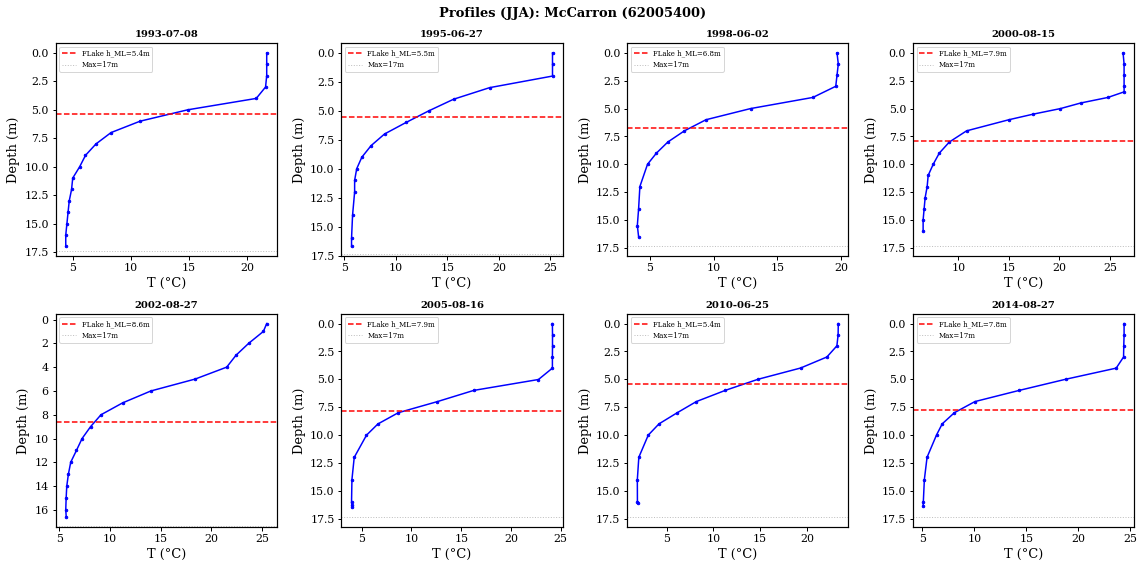

    diag_profiles_62005400_april7.png


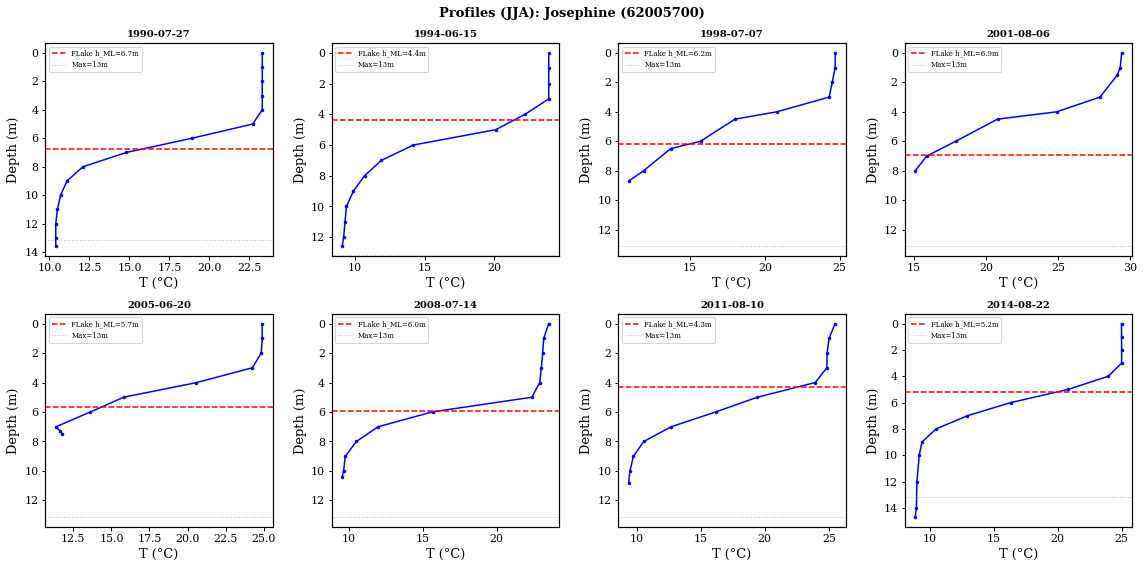

    diag_profiles_62005700_april7.png


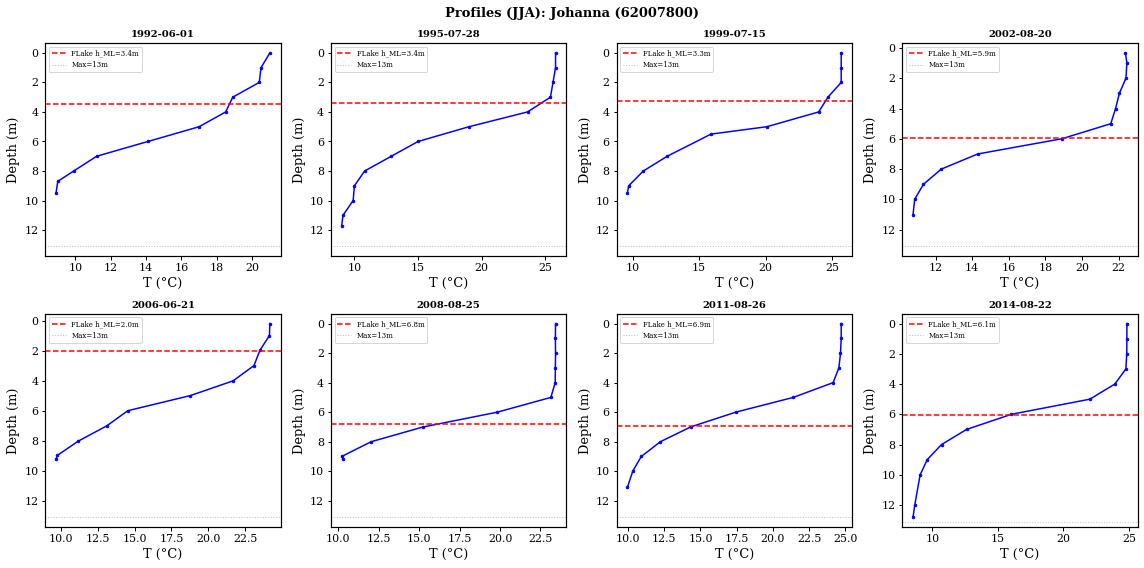

    diag_profiles_62007800_april7.png


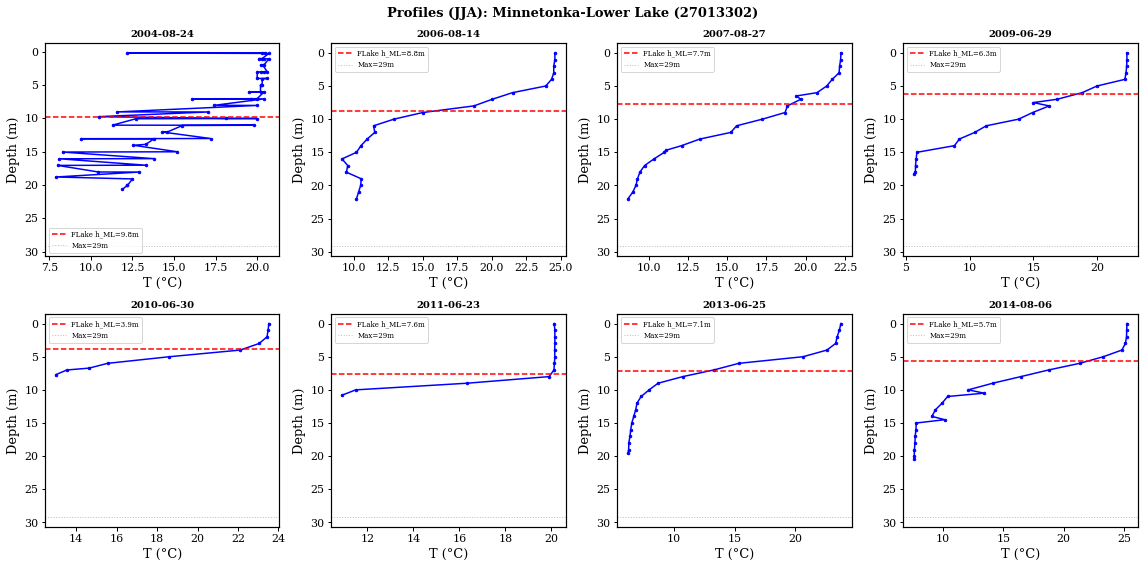

    diag_profiles_27013302_april7.png

--- Thermal validation plots (JJA only) ---

  ┌───────────────────────────────────────────────────────────────────┐
  │ Metric            n      RMSE      Bias      R²      MAE │
  ├───────────────────────────────────────────────────────────────────┤
  │ h_ML           3931     2.73m    +1.69m   0.044    2.21m │
  │ Tm_ML          3931    3.34°C   +0.54°C   0.212   2.59°C │
  │ Tb (bottom)    3931    5.56°C   -1.89°C   0.085   4.18°C │
  └───────────────────────────────────────────────────────────────────┘


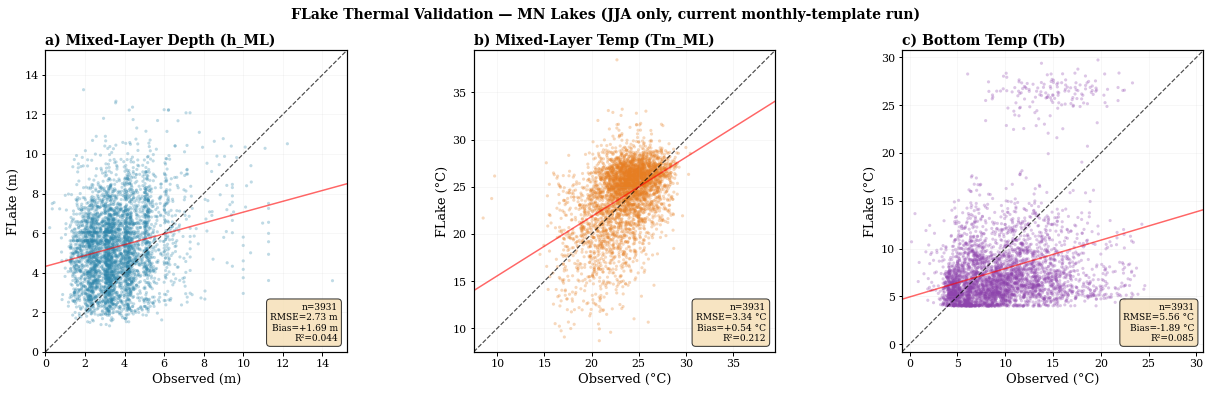

  Saved: thermal_scatter_3panel_april7.png
  Saved per-lake metrics CSV (48 lakes)

  ── Metrics by Depth Class (JJA) ──
    deep        : h_ML n=734, RMSE=3.20m, Bias=+2.48m, R²=0.096
                  Tm   n=734, RMSE=4.00°C, Bias=-1.91°C, R²=0.269
                  Tb   n=734, RMSE=4.46°C, Bias=-2.02°C, R²=0.018
    medium      : h_ML n=3039, RMSE=2.58m, Bias=+1.44m, R²=0.021
                  Tm   n=3039, RMSE=3.15°C, Bias=+1.03°C, R²=0.232
                  Tb   n=3039, RMSE=5.51°C, Bias=-2.33°C, R²=0.018
    shallow     : h_ML n=158, RMSE=3.09m, Bias=+2.93m, R²=0.042
                  Tm   n=158, RMSE=3.60°C, Bias=+2.48°C, R²=0.276
                  Tb   n=158, RMSE=9.68°C, Bias=+7.16°C, R²=0.044

  ── Metrics by Trophic Class (JJA) ──
    eutrophic     : h_ML n=921, RMSE=1.96m, Bias=+0.61m, R²=0.002
                    Tm   n=921, RMSE=3.13°C, Bias=+1.56°C, R²=0.254
                    Tb   n=921, RMSE=5.77°C, Bias=-3.16°C, R²=0.031
    mesotrophic   : h_ML n=2722, RMSE=2.78m, B

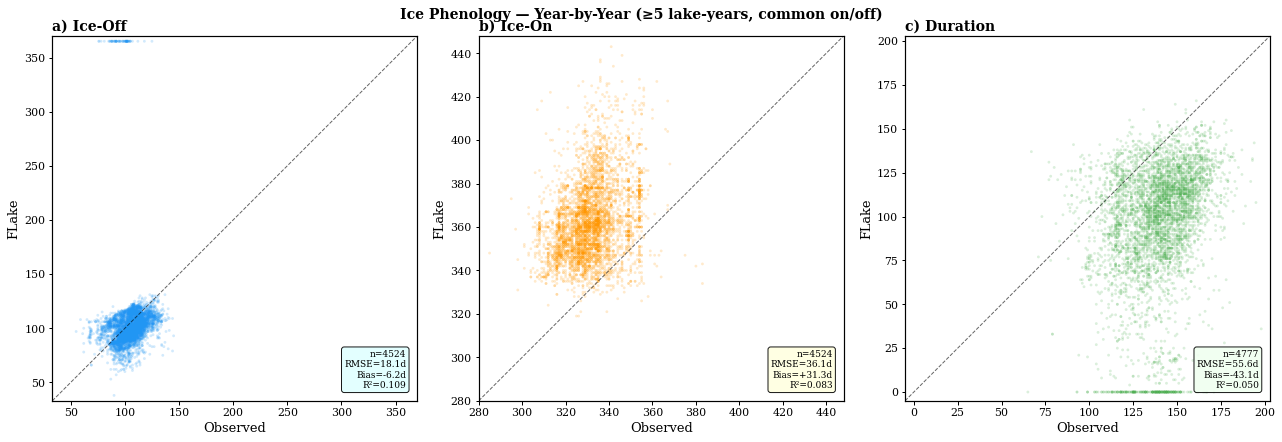

  Saved: ice_yby_scatter_april7.png

  ── CLIMATOLOGICAL VALIDATION (≥5 years per lake) ──


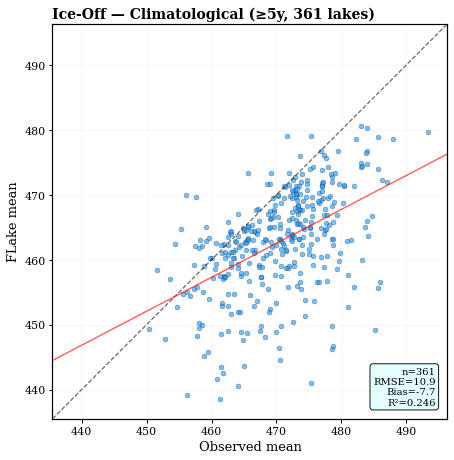

  Saved: ice_clim_ice_off_april7.png


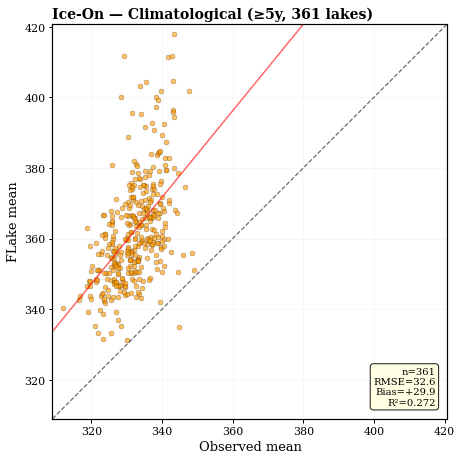

  Saved: ice_clim_ice_on_april7.png


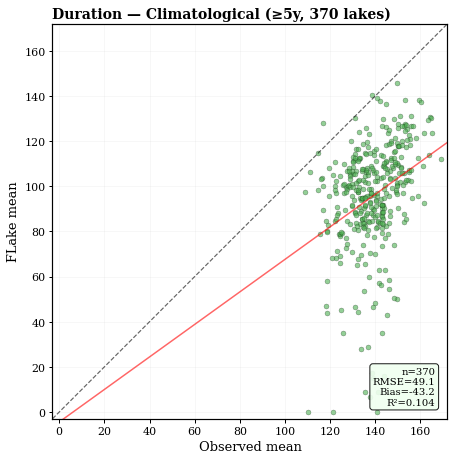

  Saved: ice_clim_duration_april7.png

  ── Ice-off time series ──


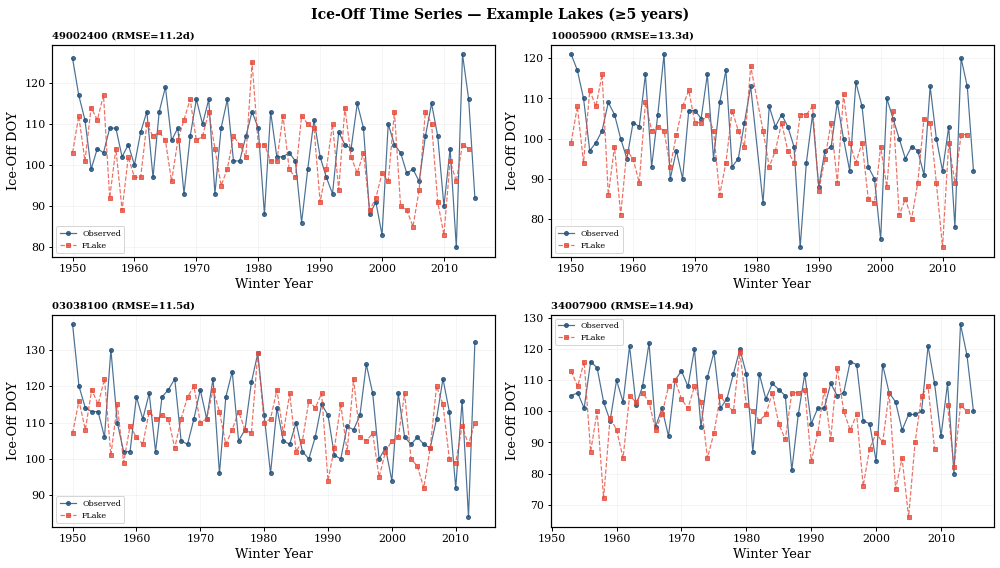

  Saved: ice_timeseries_april7.png

  ── Ice thickness time series ──


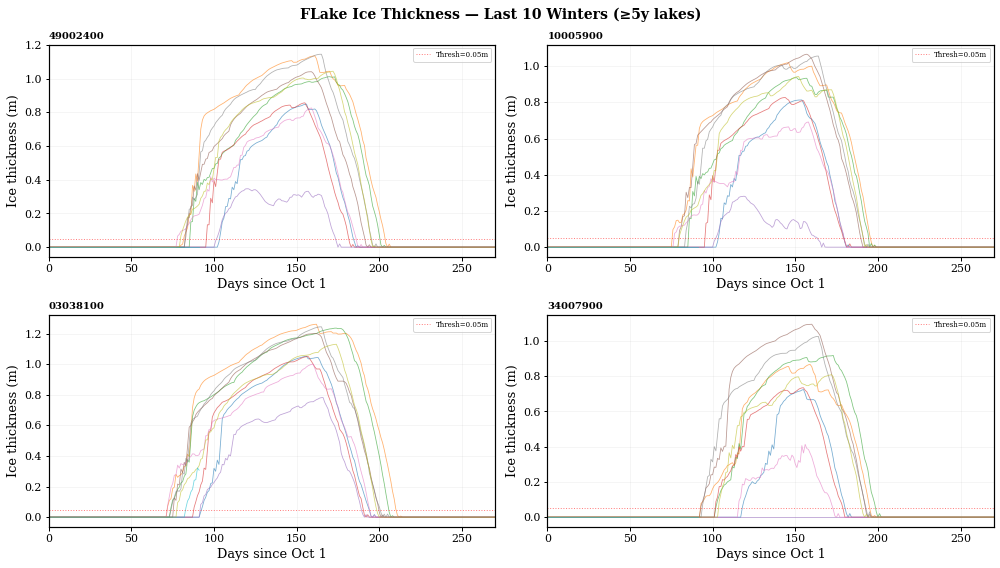

  Saved: ice_thickness_timeseries_april7.png

────────────────────────────────────────────────────────────
  ICE PHENOLOGY SUMMARY (≥5 lake‑years)
────────────────────────────────────────────────────────────
  ice_off_yby          (year-by-year  ): RMSE=18.1d, Bias=-6.2d, R²=0.109 (n=4524)
  ice_on_yby           (year-by-year  ): RMSE=36.1d, Bias=+31.3d, R²=0.083 (n=4524)
  duration_yby         (year-by-year  ): RMSE=55.6d, Bias=-43.1d, R²=0.050 (n=4777)
  ice_off_clim         (CLIMATOLOGICAL): RMSE=10.9d, Bias=-7.7d, R²=0.246 (n=361)
  ice_on_clim          (CLIMATOLOGICAL): RMSE=32.6d, Bias=+29.9d, R²=0.272 (n=361)
  duration_clim        (CLIMATOLOGICAL): RMSE=49.1d, Bias=-43.2d, R²=0.104 (n=370)

  Common-sample check (≥5 years):
    ice-off pairs = 4777
    ice-on  pairs = 4777
    ice-off lakes = 403
    ice-on  lakes = 403

  DONE — all outputs in: /scratch.global/dahal043/flake_output_historical_validation_set_only_kd_earliest


In [1]:
#!/usr/bin/env python3
"""
===============================================================================
FLake VALIDATION — FINAL (CURRENT OUTPUTS + COMMON ICE-ON/OFF SAMPLE)
===============================================================================

WHAT THIS SCRIPT DOES
---------------------
1. THERMAL VALIDATION (June–July–August only)
   - h_ML   : mixed-layer depth
   - Tm_ML  : mixed-layer mean temperature
   - Tb     : bottom / deepest observed temperature

2. ICE PHENOLOGY VALIDATION (lakes with ≥5 years of common on/off data)
   - Ice-on
   - Ice-off
   - Ice duration

IMPORTANT ICE FIX
-----------------
Ice-on and ice-off are now validated using ONLY lake-years that have BOTH:
  - observed ice-on
  - observed ice-off

Additionally, only lakes with at least 5 such lake‑years are retained.

IMPORTANT NOTE
--------------
This validation script DOES NOT control model physics.
It only reads already-generated FLake outputs.
So albedo / optical setup come from the simulation code / FLake engine,
not from this validation script.
===============================================================================
"""

import os
import glob
import warnings
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

warnings.filterwarnings("ignore")

# ═════════════════════════════════════════════════════════════════════════════
# USER CONFIGURATION
# ═════════════════════════════════════════════════════════════════════════════

# -------------------------------------------------------------------------
# CURRENT FLake outputs
# -------------------------------------------------------------------------
FLAKE_OUTPUT_DIR = r"/scratch.global/dahal043/flake_output_historical_earliest_monthly_template_20260325"

# CURRENT Code 1 parameter table
LAKE_PARAMS_CSV = r"/scratch.global/dahal043/flake_inputs_earliest_monthly_template_20260325/flake_lake_parameters.csv"

# Validation output directory
VALIDATION_OUT_DIR = r"/scratch.global/dahal043/flake_output_historical_validation_set_only_kd_earliest"

# -------------------------------------------------------------------------
# Thermal validation data
# -------------------------------------------------------------------------
MASTER_METADATA_CSV = r"/users/6/dahal043/FEB27_VALIDATION_MN_WI_68LAKES/files (1)/pgdl_68_lakes_metadata.csv"
TRAINING_CSV        = r"/users/6/dahal043/FEB27_VALIDATION_MN_WI_68LAKES/files (1)/all_lakes_historical_training.csv"

# -------------------------------------------------------------------------
# Ice phenology data
# -------------------------------------------------------------------------
ICE_PHENO_DIR       = r"/users/6/dahal043/Lake Ice Phenology Data Code/mn_ice_data_March16/merged_output_files"
ICEOUT_TS_CSV       = os.path.join(ICE_PHENO_DIR, "classified_lakes_iceout_timeseries.csv")
ICEIN_TS_CSV        = os.path.join(ICE_PHENO_DIR, "classified_lakes_icein_timeseries.csv")
ICEDUR_TS_CSV       = os.path.join(ICE_PHENO_DIR, "classified_lakes_ice_duration_timeseries.csv")
MN_CLASSIFIED_CSV   = os.path.join(ICE_PHENO_DIR, "mn_lakes_classified_with_ice_phenology.csv")

# ═════════════════════════════════════════════════════════════════════════════
# SETTINGS
# ═════════════════════════════════════════════════════════════════════════════

EXCLUDE_TOP_N          = 1
DT_REL                 = 1.0
MIN_POINTS_PER_PROFILE = 6
MIN_PROFILES_PER_LAKE  = 10

H_ICE_THRESHOLD        = 0.05
N_CONSEC_ICE_DAYS      = 5

N_DIAGNOSTIC_PROFILES  = 8
N_DIAGNOSTIC_LAKES     = 4
N_TIMESERIES_LAKES     = 4
N_ICE_THICKNESS_LAKES  = 4

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.linewidth": 1.2,
    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "figure.facecolor": "white",
    "axes.facecolor": "white",
})

# ═════════════════════════════════════════════════════════════════════════════
# HELPERS
# ═════════════════════════════════════════════════════════════════════════════

def norm_dow(v):
    try:
        return str(int(float(v))).zfill(8)
    except:
        return None

def norm_int(v):
    try:
        return int(float(v))
    except:
        return None

def find_flake(dow, d):
    s = str(dow).zfill(8)
    for p in [f"{s}_flake_historical.csv", f"{int(s)}_flake_historical.csv"]:
        fp = os.path.join(d, p)
        if os.path.exists(fp):
            return fp
    m = glob.glob(os.path.join(d, f"*{s}*flake*historical*.csv"))
    return m[0] if m else None

def doy_circ(pred, obs):
    return ((pred - obs + 182) % 365) - 182

def metrics(obs, pred):
    m = np.isfinite(obs) & np.isfinite(pred)
    o, p = obs[m], pred[m]
    n = len(o)
    if n < 3:
        return dict(
            n=n, RMSE=np.nan, Bias=np.nan, MAE=np.nan,
            R2=np.nan, r=np.nan, slope=np.nan, intercept=np.nan
        )
    b = np.mean(p - o)
    rmse = np.sqrt(np.mean((p - o) ** 2))
    mae = np.mean(np.abs(p - o))
    sl, ic, rv, _, _ = stats.linregress(o, p)
    return dict(
        n=n, RMSE=rmse, Bias=b, MAE=mae,
        R2=rv ** 2, r=rv, slope=sl, intercept=ic
    )

def metrics_circ(obs, pred):
    m = np.isfinite(obs) & np.isfinite(pred)
    o, p = obs[m], pred[m]
    n = len(o)
    if n < 3:
        return dict(
            n=n, RMSE=np.nan, Bias=np.nan, MAE=np.nan,
            R2=np.nan, r=np.nan, slope=np.nan, intercept=np.nan
        )

    d = np.array([doy_circ(pi, oi) for pi, oi in zip(p, o)])
    b = np.mean(d)
    rmse = np.sqrt(np.mean(d ** 2))
    mae = np.mean(np.abs(d))

    ow = np.where(o < 180, o + 365, o)
    pw = np.where(p < 180, p + 365, p)
    if np.std(ow) > 0 and np.std(pw) > 0:
        sl, ic, rv, _, _ = stats.linregress(ow, pw)
        r2 = rv ** 2
    else:
        sl, ic, rv, r2 = [np.nan] * 4

    return dict(
        n=n, RMSE=rmse, Bias=b, MAE=mae,
        R2=r2, r=rv, slope=sl, intercept=ic
    )

def fmt_met(m, unit=""):
    return f"n={m['n']}, RMSE={m['RMSE']:.2f}{unit}, Bias={m['Bias']:+.2f}{unit}, R²={m['R2']:.3f}"

# ═════════════════════════════════════════════════════════════════════════════
# PART A — THERMAL VALIDATION (June–July–August only)
# ═════════════════════════════════════════════════════════════════════════════

def calc_profile_metrics(
    prof_df,
    exclude_top_n=EXCLUDE_TOP_N,
    dt_rel=DT_REL,
    min_pts=MIN_POINTS_PER_PROFILE,
    max_depth=None
):
    """
    From a single profile, compute:
      h_ML  — mixed-layer depth using ΔT = 1°C threshold
      Tm_ML — depth-averaged mixed-layer temperature
      Tb    — deepest observed temperature
    """
    prof = prof_df[["depth", "temp"]].dropna().copy()
    prof["depth"] = pd.to_numeric(prof["depth"], errors="coerce")
    prof["temp"]  = pd.to_numeric(prof["temp"], errors="coerce")
    prof = prof.dropna().sort_values("depth").drop_duplicates("depth", keep="first")

    if max_depth is not None:
        prof = prof[prof["depth"] <= max_depth].copy()

    if len(prof) < max(min_pts, exclude_top_n + 2):
        return dict(h_ML=np.nan, Tm_ML=np.nan, Tb=np.nan, flag=3)

    z_all = prof["depth"].to_numpy(float)
    T_all = prof["temp"].to_numpy(float)
    Tb = float(T_all[-1])

    if exclude_top_n > 0:
        prof = prof.iloc[exclude_top_n:].copy()

    z = prof["depth"].to_numpy(float)
    T = prof["temp"].to_numpy(float)
    z0, Ts = float(z[0]), float(T[0])
    tgt = Ts - dt_rel

    hml = None
    for i in range(len(T) - 1):
        if T[i] > tgt and T[i + 1] <= tgt and z[i + 1] > z[i]:
            d = T[i] - T[i + 1]
            if d == 0:
                hml = float(z[i + 1])
            else:
                hml = float(z[i] + (z[i + 1] - z[i]) * (T[i] - tgt) / d)
            break

    if hml is None:
        if T[-1] > tgt:
            h = float(max_depth) if max_depth and max_depth > 0 else float(z[-1])
            return dict(h_ML=h, Tm_ML=float(np.mean(T)), Tb=Tb, flag=1)
        else:
            h = float(z[-1])
            t = float(np.trapz(T, z) / (z[-1] - z0)) if z[-1] > z0 else float(np.mean(T))
            return dict(h_ML=h, Tm_ML=t, Tb=Tb, flag=2)

    zn = np.append(z[z < hml], hml)
    Tn = np.append(T[z < hml], tgt)
    if len(zn) < 2 or hml == z0:
        t = float(np.mean(Tn))
    else:
        t = float(np.trapz(Tn, zn) / (hml - z0))

    return dict(h_ML=hml, Tm_ML=t, Tb=Tb, flag=0)

def run_thermal_validation():
    print("\n" + "=" * 70)
    print("  PART A: THERMAL VALIDATION (h_ML, Tm_ML, Tb) — JJA only")
    print("=" * 70)

    if not os.path.exists(MASTER_METADATA_CSV):
        print("  ERROR: metadata not found")
        return None, None, None

    master = pd.read_csv(MASTER_METADATA_CSV)
    print(f"  Loaded {len(master)} lakes metadata")

    mn = master[(master["state"] == "MN") & master["DOWLKNUM"].notna()].copy()
    mn["DOWLKNUM"] = mn["DOWLKNUM"].apply(norm_dow)
    mn = mn[mn["DOWLKNUM"].notna()]
    print(f"  MN lakes with DOWLKNUM: {len(mn)}")
    if len(mn) == 0:
        return None, None, None

    if not os.path.exists(TRAINING_CSV):
        print("  ERROR: training CSV not found")
        return None, None, None

    train = pd.read_csv(TRAINING_CSV)
    train["date"] = pd.to_datetime(train["date"], errors="coerce")
    print(f"  Loaded {len(train):,} observations across {train['site_id'].nunique()} lakes")

    lake_mean_depth = {}
    if os.path.exists(LAKE_PARAMS_CSV):
        lp = pd.read_csv(LAKE_PARAMS_CSV, dtype={"DOWLKNUM": str})
        lp["DOWLKNUM"] = lp["DOWLKNUM"].str.zfill(8)
        for _, r in lp.iterrows():
            try:
                lake_mean_depth[r["DOWLKNUM"]] = float(r["depth_w"])
            except:
                pass

    print("\n--- Computing observed h_ML, Tm_ML, Tb (JJA only) ---")
    all_obs = []
    for _, lk in mn.iterrows():
        sid = lk["site_id"]
        dow = lk["DOWLKNUM"]
        nm = lk.get("lake_name", sid)

        md = lk.get("LK_MAXDEPT_m", None)
        if pd.isna(md):
            md = None

        ds = train[train["site_id"] == sid].copy()
        if len(ds) == 0:
            continue

        ds["pd"] = ds["date"].dt.date
        nv = 0
        for pd_, g in ds.groupby("pd"):
            # Restrict to June (6), July (7), August (8)
            if pd.Timestamp(pd_).month not in [6, 7, 8]:
                continue
            r = calc_profile_metrics(g, max_depth=md)
            if r["flag"] in [0, 1, 2] and not np.isnan(r["h_ML"]):
                all_obs.append(dict(
                    site_id=sid,
                    DOWLKNUM=dow,
                    lake_name=nm,
                    date=pd.Timestamp(pd_),
                    obs_h_ML=r["h_ML"],
                    obs_Tm_ML=r["Tm_ML"],
                    obs_Tb=r["Tb"],
                    flag=r["flag"],
                    depth_class=lk.get("DEPTH_CLASS", "?"),
                    trophic_class=lk.get("TROPHIC_CLASS", "?"),
                    max_depth=md if md is not None else np.nan,
                    mean_depth=lake_mean_depth.get(dow, np.nan),
                ))
                nv += 1

        if nv > 0:
            print(f"    {str(nm):25s} ({dow}): {nv:4d} profiles")

    if not all_obs:
        print("  No observed thermal profiles survived (JJA).")
        return None, train, mn

    obs = pd.DataFrame(all_obs)
    obs["date"] = pd.to_datetime(obs["date"])
    obs["Year"] = obs["date"].dt.year
    obs["Month"] = obs["date"].dt.month
    obs["DayOfYear"] = obs["date"].dt.dayofyear

    n0 = int((obs["flag"] == 0).sum())
    n1 = int((obs["flag"] == 1).sum())
    n2 = int((obs["flag"] == 2).sum())
    print(f"\n  Total JJA profiles: {len(obs)} | flag0={n0} flag1={n1} flag2={n2}")

    lc = obs.groupby("DOWLKNUM").size()
    obs = obs[obs["DOWLKNUM"].isin(lc[lc >= MIN_PROFILES_PER_LAKE].index)].copy()
    print(f"  After minimum-profile filter: {len(obs)} records, {obs['DOWLKNUM'].nunique()} lakes")

    print("\n--- Matching thermal observations with FLake ---")
    paired = []
    for dow in obs["DOWLKNUM"].unique():
        fp = find_flake(dow, FLAKE_OUTPUT_DIR)
        if fp is None:
            continue

        try:
            fdf = pd.read_csv(fp)
            fdf["Date"] = pd.to_datetime(fdf["Date"], errors="coerce")
        except:
            continue

        if "Ts" in fdf.columns:
            if fdf["Ts"].mean() > 200:
                for c in ["Ts", "Tm", "Tb"]:
                    if c in fdf.columns:
                        fdf[c + "_C"] = fdf[c] - 273.15
            else:
                for c in ["Ts", "Tm", "Tb"]:
                    if c in fdf.columns:
                        fdf[c + "_C"] = fdf[c]

        for _, o in obs[obs["DOWLKNUM"] == dow].iterrows():
            fl = fdf[fdf["Date"].dt.date == o["date"].date()]
            if len(fl) == 0:
                continue
            fl = fl.iloc[0]

            try:
                paired.append({
                    **{k: o[k] for k in [
                        "DOWLKNUM", "lake_name", "date", "Year", "Month",
                        "DayOfYear", "obs_h_ML", "obs_Tm_ML", "obs_Tb", "flag",
                        "depth_class", "trophic_class", "max_depth", "mean_depth"
                    ]},
                    "flake_h_ML":  float(fl.get("h_ML", np.nan)),
                    "flake_Ts_C":  float(fl.get("Ts_C", np.nan)),
                    "flake_Tm_C":  float(fl.get("Tm_C", np.nan)),
                    "flake_Tb_C":  float(fl.get("Tb_C", np.nan)),
                    "flake_H_ice": float(fl.get("H_ice", np.nan)),
                })
            except (ValueError, TypeError):
                continue

    if not paired:
        print("  No paired thermal records found.")
        return None, train, mn

    pdf = pd.DataFrame(paired)
    pdf["date"] = pd.to_datetime(pdf["date"])

    # Keep same behavior as original script
    pdf["flake_Tm_ML"] = pdf["flake_Ts_C"]

    print(f"  Paired JJA thermal records: {len(pdf)}, Lakes: {pdf['DOWLKNUM'].nunique()}")
    return pdf, train, mn

def plot_thermal_all(pdf, out_dir):
    print("\n--- Thermal validation plots (JJA only) ---")
    os.makedirs(out_dir, exist_ok=True)

    mh = metrics(pdf["obs_h_ML"].values, pdf["flake_h_ML"].values)
    mt = metrics(pdf["obs_Tm_ML"].values, pdf["flake_Tm_ML"].values)
    mb = metrics(pdf["obs_Tb"].values, pdf["flake_Tb_C"].values)

    print(f"\n  ┌───────────────────────────────────────────────────────────────────┐")
    print(f"  │ {'Metric':<12s} {'n':>6s}  {'RMSE':>8s}  {'Bias':>8s}  {'R²':>6s}  {'MAE':>7s} │")
    print(f"  ├───────────────────────────────────────────────────────────────────┤")
    print(f"  │ {'h_ML':<12s} {mh['n']:>6d}  {mh['RMSE']:>7.2f}m  {mh['Bias']:>+7.2f}m  {mh['R2']:>6.3f}  {mh['MAE']:>6.2f}m │")
    print(f"  │ {'Tm_ML':<12s} {mt['n']:>6d}  {mt['RMSE']:>6.2f}°C  {mt['Bias']:>+6.2f}°C  {mt['R2']:>6.3f}  {mt['MAE']:>5.2f}°C │")
    print(f"  │ {'Tb (bottom)':<12s} {mb['n']:>6d}  {mb['RMSE']:>6.2f}°C  {mb['Bias']:>+6.2f}°C  {mb['R2']:>6.3f}  {mb['MAE']:>5.2f}°C │")
    print(f"  └───────────────────────────────────────────────────────────────────┘")

    fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
    configs = [
        (axes[0], "obs_h_ML",  "flake_h_ML",  "m",  "Mixed-Layer Depth (h_ML)", "#2E86AB", "a"),
        (axes[1], "obs_Tm_ML", "flake_Tm_ML", "°C", "Mixed-Layer Temp (Tm_ML)",  "#E67E22", "b"),
        (axes[2], "obs_Tb",    "flake_Tb_C",  "°C", "Bottom Temp (Tb)",          "#8E44AD", "c"),
    ]

    for ax, xk, yk, unit, lbl, color, panel in configs:
        x, y = pdf[xk].values, pdf[yk].values
        m = np.isfinite(x) & np.isfinite(y)
        xc, yc = x[m], y[m]
        met = metrics(x, y)

        ax.scatter(xc, yc, s=10, alpha=0.3, c=color, edgecolors="none")

        if xk == "obs_h_ML":
            lo, hi = 0, max(xc.max(), yc.max()) * 1.05
        else:
            lo = min(xc.min(), yc.min()) - 1
            hi = max(xc.max(), yc.max()) + 1

        ax.plot([lo, hi], [lo, hi], "k--", lw=1.2, alpha=0.7)

        if met["n"] > 3:
            xf = np.linspace(lo, hi, 100)
            ax.plot(xf, met["slope"] * xf + met["intercept"], "r-", lw=1.5, alpha=0.6)

        ax.set_xlim(lo, hi)
        ax.set_ylim(lo, hi)
        ax.set_aspect("equal")
        ax.set_xlabel(f"Observed ({unit})")
        ax.set_ylabel(f"FLake ({unit})")
        ax.set_title(f"{panel}) {lbl}", loc="left")

        txt = f"n={met['n']}\nRMSE={met['RMSE']:.2f} {unit}\nBias={met['Bias']:+.2f} {unit}\nR²={met['R2']:.3f}"
        ax.text(
            0.97, 0.03, txt,
            transform=ax.transAxes,
            ha="right", va="bottom", fontsize=9,
            bbox=dict(boxstyle="round,pad=0.4", fc="wheat", alpha=0.8)
        )
        ax.grid(alpha=0.12)

    plt.suptitle("FLake Thermal Validation — MN Lakes (JJA only, current monthly-template run)", fontsize=14, fontweight="bold")
    plt.tight_layout()
    fig.savefig(os.path.join(out_dir, "thermal_scatter_3panel_april7.png"), dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print("  Saved: thermal_scatter_3panel_april7.png")

    # Monthly bias plot not needed for JJA only (only three months), but keep if desired
    # We'll skip it or modify; for simplicity we omit it.

    lm = []
    for dow, g in pdf.groupby("DOWLKNUM"):
        mh_l = metrics(g["obs_h_ML"].values, g["flake_h_ML"].values)
        mt_l = metrics(g["obs_Tm_ML"].values, g["flake_Tm_ML"].values)
        mb_l = metrics(g["obs_Tb"].values, g["flake_Tb_C"].values)
        if mh_l["n"] < 3:
            continue
        lm.append(dict(
            DOWLKNUM=dow,
            lake_name=g["lake_name"].iloc[0],
            n=mh_l["n"],
            depth_class=g["depth_class"].iloc[0],
            trophic_class=g["trophic_class"].iloc[0],
            mean_depth=g["mean_depth"].iloc[0],
            hML_RMSE=mh_l["RMSE"], hML_Bias=mh_l["Bias"], hML_R2=mh_l["R2"],
            TmML_RMSE=mt_l["RMSE"], TmML_Bias=mt_l["Bias"], TmML_R2=mt_l["R2"],
            Tb_RMSE=mb_l["RMSE"], Tb_Bias=mb_l["Bias"], Tb_R2=mb_l["R2"]
        ))

    lm_df = pd.DataFrame(lm).sort_values("TmML_RMSE")
    lm_df.to_csv(os.path.join(out_dir, "thermal_per_lake_metrics_april7.csv"), index=False)
    print(f"  Saved per-lake metrics CSV ({len(lm_df)} lakes)")

    print("\n  ── Metrics by Depth Class (JJA) ──")
    for dc in sorted(pdf["depth_class"].dropna().unique()):
        g = pdf[pdf["depth_class"] == dc]
        if len(g) < 5:
            continue
        mh_c = metrics(g["obs_h_ML"].values, g["flake_h_ML"].values)
        mt_c = metrics(g["obs_Tm_ML"].values, g["flake_Tm_ML"].values)
        mb_c = metrics(g["obs_Tb"].values, g["flake_Tb_C"].values)
        print(f"    {dc:12s}: h_ML {fmt_met(mh_c, 'm')}")
        print(f"    {'':12s}  Tm   {fmt_met(mt_c, '°C')}")
        print(f"    {'':12s}  Tb   {fmt_met(mb_c, '°C')}")

    print("\n  ── Metrics by Trophic Class (JJA) ──")
    for tc in sorted(pdf["trophic_class"].dropna().unique()):
        g = pdf[pdf["trophic_class"] == tc]
        if len(g) < 5:
            continue
        mh_c = metrics(g["obs_h_ML"].values, g["flake_h_ML"].values)
        mt_c = metrics(g["obs_Tm_ML"].values, g["flake_Tm_ML"].values)
        mb_c = metrics(g["obs_Tb"].values, g["flake_Tb_C"].values)
        print(f"    {tc:14s}: h_ML {fmt_met(mh_c, 'm')}")
        print(f"    {'':14s}  Tm   {fmt_met(mt_c, '°C')}")
        print(f"    {'':14s}  Tb   {fmt_met(mb_c, '°C')}")

    return (mh, mt, mb), lm_df

def plot_diagnostic_profiles(pdf, train, mn_lakes, out_dir):
    print("\n--- Diagnostic profile figures (JJA) ---")
    os.makedirs(out_dir, exist_ok=True)

    tops = pdf.groupby("DOWLKNUM").size().sort_values(ascending=False).head(N_DIAGNOSTIC_LAKES).index
    for dow in tops:
        lo = pdf[pdf["DOWLKNUM"] == dow]
        nm = lo["lake_name"].iloc[0]

        sid_row = mn_lakes[mn_lakes["DOWLKNUM"] == dow]
        if len(sid_row) == 0:
            continue

        sid = sid_row.iloc[0]["site_id"]
        md = sid_row.iloc[0].get("LK_MAXDEPT_m", None)
        if pd.isna(md):
            md = None

        ds = train[train["site_id"] == sid].copy()
        ds["pd"] = ds["date"].dt.date

        # Already only JJA months in lo
        sd = lo["date"].dt.date.unique()
        if len(sd) > N_DIAGNOSTIC_PROFILES:
            sd = sd[np.linspace(0, len(sd) - 1, N_DIAGNOSTIC_PROFILES).astype(int)]

        nc = min(4, len(sd))
        nr = math.ceil(len(sd) / nc)
        fig, axes = plt.subplots(nr, nc, figsize=(4 * nc, 4 * nr), squeeze=False)
        af = axes.ravel()

        for j, d in enumerate(sd):
            if j >= len(af):
                break
            ax = af[j]
            p = ds[ds["pd"] == d].sort_values("depth")
            if len(p) == 0:
                ax.set_visible(False)
                continue

            ax.plot(p["temp"], p["depth"], "b.-", lw=1.5, ms=5)
            ax.invert_yaxis()

            frow = lo[lo["date"].dt.date == d]
            if len(frow) > 0:
                fhml = frow.iloc[0]["flake_h_ML"]
                if np.isfinite(fhml):
                    ax.axhline(fhml, color="red", ls="--", lw=1.5, label=f"FLake h_ML={fhml:.1f}m")

            if md:
                ax.axhline(md, color="gray", ls=":", lw=1, alpha=0.5, label=f"Max={md:.0f}m")

            ax.set_xlabel("T (°C)")
            ax.set_ylabel("Depth (m)")
            ax.set_title(str(d), fontsize=10)
            ax.legend(fontsize=7)

        for j in range(len(sd), len(af)):
            af[j].set_visible(False)

        plt.suptitle(f"Profiles (JJA): {nm} ({dow})", fontsize=13, fontweight="bold")
        plt.tight_layout()
        fn = f"diag_profiles_{dow}_april7.png"
        fig.savefig(os.path.join(out_dir, fn), dpi=200, bbox_inches="tight")
        plt.show()
        plt.close(fig)
        print(f"    {fn}")

# ═════════════════════════════════════════════════════════════════════════════
# PART B — ICE PHENOLOGY (≥5 lake-years per lake)
# ═════════════════════════════════════════════════════════════════════════════

def extract_ice_pheno(flake_df, thresh=H_ICE_THRESHOLD, n_consec=N_CONSEC_ICE_DAYS):
    df = flake_df[["Date", "Year", "Month", "DayOfYear", "H_ice"]].copy()
    df["Date"] = pd.to_datetime(df["Date"])
    df["ice"] = (df["H_ice"] >= thresh).astype(int)
    df["winter_year"] = df["Date"].apply(lambda d: d.year + 1 if d.month >= 7 else d.year)

    recs = []
    for wy, w in df.groupby("winter_year"):
        w = w.sort_values("Date").reset_index(drop=True)
        ice = w["ice"].values
        n = len(ice)

        runs = []
        i = 0
        while i < n:
            if ice[i] == 1:
                j = i
                while j < n and ice[j] == 1:
                    j += 1
                if j - i >= n_consec:
                    runs.append((i, j - 1))
                i = j
            else:
                i += 1

        if not runs:
            recs.append(dict(
                winter_year=wy,
                flake_ice_on_date=pd.NaT,
                flake_ice_off_date=pd.NaT,
                flake_ice_on_doy=np.nan,
                flake_ice_off_doy=np.nan,
                flake_duration=0
            ))
            continue

        on_idx = runs[0][0]
        on_date = w.loc[on_idx, "Date"]

        off_idx = runs[-1][1]
        off_date = w.loc[off_idx + 1, "Date"] if off_idx + 1 < len(w) else w.loc[off_idx, "Date"]

        recs.append(dict(
            winter_year=wy,
            flake_ice_on_date=on_date,
            flake_ice_off_date=off_date,
            flake_ice_on_doy=on_date.timetuple().tm_yday,
            flake_ice_off_doy=off_date.timetuple().tm_yday,
            flake_duration=(off_date - on_date).days
        ))

    return pd.DataFrame(recs)

def run_ice_validation():
    print("\n" + "=" * 70)
    print("  PART B: ICE PHENOLOGY (COMMON ON/OFF, ≥5 lake‑years per lake)")
    print("=" * 70)

    if not os.path.exists(ICEOUT_TS_CSV) or not os.path.exists(ICEIN_TS_CSV):
        print("  ERROR: both iceout and icein files are required")
        return None, None, None

    # ---------------------------------------------------------------------
    # Read observed ice-off and ice-on
    # ---------------------------------------------------------------------
    df_out_obs = pd.read_csv(ICEOUT_TS_CSV)
    df_in_obs  = pd.read_csv(ICEIN_TS_CSV)

    df_out_obs["lake_id_int"] = df_out_obs["DOW"].apply(norm_int)
    df_in_obs["lake_id_int"]  = df_in_obs["DOW"].apply(norm_int)

    df_out_obs["DOWLKNUM"] = df_out_obs["lake_id_int"].apply(lambda x: str(x).zfill(8) if pd.notna(x) else None)
    df_in_obs["DOWLKNUM"]  = df_in_obs["lake_id_int"].apply(lambda x: str(x).zfill(8) if pd.notna(x) else None)

    df_out_obs["winter_year"] = pd.to_numeric(df_out_obs["winter.year"], errors="coerce").astype("Int64")
    df_in_obs["winter_year"]  = pd.to_numeric(df_in_obs["winter.year"], errors="coerce").astype("Int64")

    df_out_obs["obs_iceoff_doy"] = pd.to_numeric(df_out_obs["min_ice_off_julian"], errors="coerce")
    df_in_obs["obs_iceon_doy"]   = pd.to_numeric(df_in_obs["min_ice_on_julian"], errors="coerce")

    df_out_obs = df_out_obs.dropna(subset=["DOWLKNUM", "winter_year", "obs_iceoff_doy"]).copy()
    df_in_obs  = df_in_obs.dropna(subset=["DOWLKNUM", "winter_year", "obs_iceon_doy"]).copy()

    # ---------------------------------------------------------------------
    # Keep only lake-years with BOTH observed ice-on and observed ice-off
    # ---------------------------------------------------------------------
    common_obs = df_out_obs[[
        "DOWLKNUM", "winter_year", "obs_iceoff_doy", "min_ice_off_date"
    ]].merge(
        df_in_obs[[
            "DOWLKNUM", "winter_year", "obs_iceon_doy", "min_ice_on_date"
        ]],
        on=["DOWLKNUM", "winter_year"],
        how="inner"
    )

    print(f"  Common observed lake-years with BOTH on/off: {len(common_obs)}")
    print(f"  Unique lakes in common on/off set: {common_obs['DOWLKNUM'].nunique()}")

    # ---------------------------------------------------------------------
    # Filter lakes with at least 5 lake-years
    # ---------------------------------------------------------------------
    lake_year_counts = common_obs.groupby("DOWLKNUM").size()
    lakes_ge5 = lake_year_counts[lake_year_counts >= 5].index
    common_obs = common_obs[common_obs["DOWLKNUM"].isin(lakes_ge5)].copy()
    print(f"  After keeping lakes with ≥5 years: {len(common_obs)} lake‑years, {common_obs['DOWLKNUM'].nunique()} lakes")

    # Duration file optional, but later restricted to same common lake-years
    df_dur_obs = None
    if os.path.exists(ICEDUR_TS_CSV):
        df_dur_obs = pd.read_csv(ICEDUR_TS_CSV)
        df_dur_obs["lake_id_int"] = df_dur_obs["DOW"].apply(norm_int)
        df_dur_obs["DOWLKNUM"] = df_dur_obs["lake_id_int"].apply(lambda x: str(x).zfill(8) if pd.notna(x) else None)
        df_dur_obs["winter_year"] = pd.to_numeric(df_dur_obs["winter.year"], errors="coerce").astype("Int64")
        df_dur_obs["obs_duration"] = pd.to_numeric(df_dur_obs["max_duration"], errors="coerce")
        df_dur_obs = df_dur_obs.dropna(subset=["DOWLKNUM", "winter_year", "obs_duration"]).copy()

    lake_classes = {}
    if os.path.exists(MN_CLASSIFIED_CSV):
        cl = pd.read_csv(MN_CLASSIFIED_CSV)
        cl["DOWLKNUM"] = cl["DOWLKNUM"].apply(norm_dow)
        for _, r in cl.iterrows():
            lake_classes[r["DOWLKNUM"]] = dict(
                depth_class=r.get("DEPTH_CLASS", "?"),
                trophic_class=r.get("TROPHIC_CLASS", "?"),
                max_depth=r.get("LK_MAXDEPT", np.nan)
            )

    paired_out = []
    paired_in  = []
    paired_dur = []

    matched_lakes = 0
    unmatched_lakes = 0

    for dow in sorted(common_obs["DOWLKNUM"].unique()):
        fp = find_flake(dow, FLAKE_OUTPUT_DIR)
        if fp is None:
            unmatched_lakes += 1
            continue

        try:
            fdf = pd.read_csv(fp)
            fdf["Date"] = pd.to_datetime(fdf["Date"], errors="coerce")
        except:
            unmatched_lakes += 1
            continue

        if "H_ice" not in fdf.columns:
            unmatched_lakes += 1
            continue

        matched_lakes += 1
        fice = extract_ice_pheno(fdf)
        lc = lake_classes.get(dow, {})

        g_common = common_obs[common_obs["DOWLKNUM"] == dow].copy()

        for _, r in g_common.iterrows():
            wy = int(r["winter_year"])
            fm = fice[fice["winter_year"] == wy]
            if len(fm) == 0:
                continue
            fm = fm.iloc[0]

            paired_out.append(dict(
                DOWLKNUM=dow,
                winter_year=wy,
                obs_doy=float(r["obs_iceoff_doy"]),
                flake_doy=fm["flake_ice_off_doy"],
                obs_date=str(r.get("min_ice_off_date", "")),
                flake_date=str(fm["flake_ice_off_date"])[:10],
                **lc
            ))

            paired_in.append(dict(
                DOWLKNUM=dow,
                winter_year=wy,
                obs_doy=float(r["obs_iceon_doy"]),
                flake_doy=fm["flake_ice_on_doy"],
                obs_date=str(r.get("min_ice_on_date", "")),
                flake_date=str(fm["flake_ice_on_date"])[:10],
                **lc
            ))

        # Duration also restricted to same common lake-year set and ≥5 years filter
        if df_dur_obs is not None:
            g_dur = df_dur_obs[df_dur_obs["DOWLKNUM"] == dow].copy()
            g_dur = g_dur.merge(
                g_common[["DOWLKNUM", "winter_year"]],
                on=["DOWLKNUM", "winter_year"],
                how="inner"
            )

            for _, r in g_dur.iterrows():
                wy = int(r["winter_year"])
                fm = fice[fice["winter_year"] == wy]
                if len(fm) == 0:
                    continue
                fm = fm.iloc[0]
                paired_dur.append(dict(
                    DOWLKNUM=dow,
                    winter_year=wy,
                    obs_dur=float(r["obs_duration"]),
                    flake_dur=fm["flake_duration"],
                    **lc
                ))

    print(f"\n  Matched FLake lakes (≥5 years): {matched_lakes}")
    print(f"  Unmatched FLake lakes: {unmatched_lakes}")

    df_out = pd.DataFrame(paired_out) if paired_out else None
    df_in  = pd.DataFrame(paired_in) if paired_in else None
    df_dur = pd.DataFrame(paired_dur) if paired_dur else None

    if df_out is not None and len(df_out) > 0:
        print(f"  Ice-off pairs: {len(df_out)}")
        print(f"  Unique lakes in ice-off: {df_out['DOWLKNUM'].nunique()}")

    if df_in is not None and len(df_in) > 0:
        print(f"  Ice-on pairs: {len(df_in)}")
        print(f"  Unique lakes in ice-on: {df_in['DOWLKNUM'].nunique()}")

    if df_out is not None and df_in is not None and len(df_out) == len(df_in):
        print("  Ice-on and ice-off counts are aligned on the same common lake-year sample.")

    if df_dur is not None:
        print(f"  Duration pairs (same common set): {len(df_dur)}")

    return df_out, df_in, df_dur

def plot_ice_all(df_out, df_in, df_dur, out_dir):
    print("\n--- Ice phenology plots (lakes with ≥5 years) ---")
    os.makedirs(out_dir, exist_ok=True)

    all_met = {}
    datasets = []

    if df_out is not None and len(df_out) > 0:
        datasets.append(("Ice-Off", df_out, "obs_doy", "flake_doy", "#2196F3", "lightcyan", False))
    if df_in is not None and len(df_in) > 0:
        datasets.append(("Ice-On", df_in, "obs_doy", "flake_doy", "#FF9800", "lightyellow", True))
    if df_dur is not None and len(df_dur) > 0:
        datasets.append(("Duration", df_dur, "obs_dur", "flake_dur", "#4CAF50", "honeydew", False))

    n = len(datasets)
    if n == 0:
        print("  No ice datasets available to plot.")
        return all_met

    fig, axes = plt.subplots(1, n, figsize=(6 * n, 6))
    if n == 1:
        axes = [axes]

    for i, (lab, df, ok, pk, clr, bg, wrap) in enumerate(datasets):
        ax = axes[i]
        x, y = df[ok].values.astype(float), df[pk].values.astype(float)
        m = np.isfinite(x) & np.isfinite(y)
        xc, yc = x[m], y[m]

        if wrap:
            mt = metrics_circ(x, y)
            xp = np.where(xc < 180, xc + 365, xc)
            yp = np.where(yc < 180, yc + 365, yc)
            ax.scatter(xp, yp, s=8, alpha=0.2, c=clr, edgecolors="none")
            lo, hi = min(xp.min(), yp.min()) - 5, max(xp.max(), yp.max()) + 5
        else:
            mt = metrics(x, y) if lab == "Duration" else metrics_circ(x, y)
            ax.scatter(xc, yc, s=8, alpha=0.2, c=clr, edgecolors="none")
            lo, hi = min(xc.min(), yc.min()) - 5, max(xc.max(), yc.max()) + 5

        ax.plot([lo, hi], [lo, hi], "k--", lw=1, alpha=0.6)
        ax.set_xlim(lo, hi)
        ax.set_ylim(lo, hi)
        ax.set_aspect("equal")
        ax.set_xlabel("Observed")
        ax.set_ylabel("FLake")
        ax.set_title(f"{'abc'[i]}) {lab}", loc="left")
        ax.text(
            0.97, 0.03,
            f"n={mt['n']}\nRMSE={mt['RMSE']:.1f}d\nBias={mt['Bias']:+.1f}d\nR²={mt['R2']:.3f}",
            transform=ax.transAxes,
            ha="right", va="bottom", fontsize=9,
            bbox=dict(boxstyle="round", fc=bg, alpha=0.9)
        )
        all_met[lab.lower().replace("-", "_") + "_yby"] = mt

    plt.suptitle("Ice Phenology — Year-by-Year (≥5 lake‑years, common on/off)", fontsize=14, fontweight="bold")
    plt.tight_layout()
    fig.savefig(os.path.join(out_dir, "ice_yby_scatter_april7.png"), dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print("  Saved: ice_yby_scatter_april7.png")

    print("\n  ── CLIMATOLOGICAL VALIDATION (≥5 years per lake) ──")
    for lab, df, ok, pk, clr, bg, wrap in datasets:
        if df is None or len(df) == 0:
            continue

        lake_means = []
        for dow, g in df.groupby("DOWLKNUM"):
            x, y = g[ok].values.astype(float), g[pk].values.astype(float)
            m = np.isfinite(x) & np.isfinite(y)
            if m.sum() < 3:
                continue

            if lab == "Duration":
                lake_means.append(dict(
                    DOWLKNUM=dow,
                    obs_mean=np.mean(x[m]),
                    flake_mean=np.mean(y[m]),
                    n=int(m.sum())
                ))
            else:
                ox = x[m]
                fx = y[m]
                ox_w = np.where(ox < 180, ox + 365, ox)
                fx_w = np.where(fx < 180, fx + 365, fx)
                lake_means.append(dict(
                    DOWLKNUM=dow,
                    obs_mean=np.mean(ox_w),
                    flake_mean=np.mean(fx_w),
                    n=int(m.sum())
                ))

        if not lake_means:
            continue

        lm = pd.DataFrame(lake_means)
        mt = metrics(lm["obs_mean"].values, lm["flake_mean"].values)
        all_met[lab.lower().replace("-", "_") + "_clim"] = mt

        fig, ax = plt.subplots(figsize=(6.5, 6.5))
        ax.scatter(
            lm["obs_mean"], lm["flake_mean"],
            s=25, alpha=0.6, c=clr,
            edgecolors="black", lw=0.3
        )

        lo = min(lm["obs_mean"].min(), lm["flake_mean"].min()) - 3
        hi = max(lm["obs_mean"].max(), lm["flake_mean"].max()) + 3
        ax.plot([lo, hi], [lo, hi], "k--", lw=1.2, alpha=0.6)

        if mt["n"] > 3:
            xf = np.linspace(lo, hi, 100)
            ax.plot(xf, mt["slope"] * xf + mt["intercept"], "r-", lw=1.5, alpha=0.6)

        ax.set_xlim(lo, hi)
        ax.set_ylim(lo, hi)
        ax.set_aspect("equal")
        ax.set_xlabel("Observed mean")
        ax.set_ylabel("FLake mean")
        ax.set_title(f"{lab} — Climatological (≥5y, {len(lm)} lakes)", loc="left")
        ax.text(
            0.97, 0.03,
            f"n={mt['n']}\nRMSE={mt['RMSE']:.1f}\nBias={mt['Bias']:+.1f}\nR²={mt['R2']:.3f}",
            transform=ax.transAxes,
            ha="right", va="bottom", fontsize=10,
            bbox=dict(boxstyle="round", fc=bg, alpha=0.9)
        )
        ax.grid(alpha=0.12)

        plt.tight_layout()
        fn = f"ice_clim_{lab.lower().replace('-', '_')}_april7.png"
        fig.savefig(os.path.join(out_dir, fn), dpi=300, bbox_inches="tight")
        plt.show()
        plt.close(fig)
        print(f"  Saved: {fn}")

    if df_out is not None and len(df_out) > 0:
        print("\n  ── Ice-off time series ──")
        lake_n = df_out.groupby("DOWLKNUM").size().sort_values(ascending=False)
        top_dows = lake_n.head(N_TIMESERIES_LAKES).index.tolist()

        nc = 2
        nr = math.ceil(len(top_dows) / nc)
        fig, axes = plt.subplots(nr, nc, figsize=(7 * nc, 4 * nr), squeeze=False)
        af = axes.ravel()

        for i, dow in enumerate(top_dows):
            if i >= len(af):
                break
            ax = af[i]
            g = df_out[df_out["DOWLKNUM"] == dow].sort_values("winter_year")

            ax.plot(g["winter_year"], g["obs_doy"].astype(float), "o-", color="#1F4E79", ms=4, lw=1.2, alpha=0.8, label="Observed")
            ax.plot(g["winter_year"], g["flake_doy"].astype(float), "s--", color="#E74C3C", ms=4, lw=1.2, alpha=0.8, label="FLake")

            mt = metrics_circ(g["obs_doy"].values.astype(float), g["flake_doy"].values.astype(float))
            ax.set_xlabel("Winter Year")
            ax.set_ylabel("Ice-Off DOY")
            ax.set_title(f"{dow} (RMSE={mt['RMSE']:.1f}d)", fontsize=10, loc="left")
            ax.legend(fontsize=8)
            ax.grid(alpha=0.15)

        for j in range(len(top_dows), len(af)):
            af[j].set_visible(False)

        plt.suptitle("Ice-Off Time Series — Example Lakes (≥5 years)", fontsize=14, fontweight="bold")
        plt.tight_layout()
        fig.savefig(os.path.join(out_dir, "ice_timeseries_april7.png"), dpi=300, bbox_inches="tight")
        plt.show()
        plt.close(fig)
        print("  Saved: ice_timeseries_april7.png")

    print("\n  ── Ice thickness time series ──")
    if df_out is not None and len(df_out) > 0:
        top_dows = df_out.groupby("DOWLKNUM").size().sort_values(ascending=False).head(N_ICE_THICKNESS_LAKES).index
        nc = 2
        nr = math.ceil(len(top_dows) / nc)
        fig, axes = plt.subplots(nr, nc, figsize=(7 * nc, 4 * nr), squeeze=False)
        af = axes.ravel()

        for i, dow in enumerate(top_dows):
            if i >= len(af):
                break
            ax = af[i]
            fp = find_flake(dow, FLAKE_OUTPUT_DIR)
            if fp is None:
                ax.set_visible(False)
                continue

            try:
                fdf = pd.read_csv(fp)
                fdf["Date"] = pd.to_datetime(fdf["Date"], errors="coerce")
            except:
                ax.set_visible(False)
                continue

            fdf["wy"] = fdf["Date"].apply(lambda d: d.year + 1 if d.month >= 7 else d.year)
            recent_wys = sorted(fdf["wy"].unique())[-10:]

            for wy in recent_wys:
                w = fdf[fdf["wy"] == wy].sort_values("Date")
                oct1 = pd.Timestamp(year=wy - 1, month=10, day=1)
                days = (w["Date"] - oct1).dt.days
                ax.plot(days, w["H_ice"].values, lw=0.8, alpha=0.6)

            ax.set_xlabel("Days since Oct 1")
            ax.set_ylabel("Ice thickness (m)")
            ax.set_title(f"{dow}", fontsize=10, loc="left")
            ax.set_xlim(0, 270)
            ax.grid(alpha=0.15)
            ax.axhline(H_ICE_THRESHOLD, color="red", ls=":", lw=1, alpha=0.5, label=f"Thresh={H_ICE_THRESHOLD}m")
            ax.legend(fontsize=7)

        for j in range(len(top_dows), len(af)):
            af[j].set_visible(False)

        plt.suptitle("FLake Ice Thickness — Last 10 Winters (≥5y lakes)", fontsize=14, fontweight="bold")
        plt.tight_layout()
        fig.savefig(os.path.join(out_dir, "ice_thickness_timeseries_april7.png"), dpi=300, bbox_inches="tight")
        plt.show()
        plt.close(fig)
        print("  Saved: ice_thickness_timeseries_april7.png")

    return all_met

# ═════════════════════════════════════════════════════════════════════════════
# MAIN
# ═════════════════════════════════════════════════════════════════════════════

def main():
    print("=" * 70)
    print("  FLake VALIDATION — CURRENT MONTHLY-TEMPLATE RUN (April 7 modifications)")
    print(f"  FLake dir: {FLAKE_OUTPUT_DIR}")
    print("=" * 70)

    os.makedirs(VALIDATION_OUT_DIR, exist_ok=True)

    # ---------------------------------------------------------------------
    # Thermal (JJA only)
    # ---------------------------------------------------------------------
    thermal, train, mn = run_thermal_validation()

    if thermal is not None and len(thermal) > 0:
        thermal_csv = os.path.join(VALIDATION_OUT_DIR, "validation_thermal_april7.csv")
        thermal.to_csv(thermal_csv, index=False)
        print(f"\n  Saved: {thermal_csv}")

        plot_diagnostic_profiles(thermal, train, mn, VALIDATION_OUT_DIR)
        (mh, mt, mb), lm = plot_thermal_all(thermal, VALIDATION_OUT_DIR)

        print("\n" + "─" * 60)
        print("  THERMAL VALIDATION SUMMARY (JJA)")
        print("─" * 60)
        print(f"  h_ML:      RMSE={mh['RMSE']:.2f} m,  Bias={mh['Bias']:+.2f} m,  R²={mh['R2']:.3f}  (n={mh['n']})")
        print(f"  Tm_ML:     RMSE={mt['RMSE']:.2f} °C, Bias={mt['Bias']:+.2f} °C, R²={mt['R2']:.3f}  (n={mt['n']})")
        print(f"  Tb (bot):  RMSE={mb['RMSE']:.2f} °C, Bias={mb['Bias']:+.2f} °C, R²={mb['R2']:.3f}  (n={mb['n']})")
    else:
        print("\n  Thermal validation did not produce paired records.")

    # ---------------------------------------------------------------------
    # Ice (≥5 years per lake)
    # ---------------------------------------------------------------------
    df_out, df_in, df_dur = run_ice_validation()

    if df_out is not None and len(df_out) > 0:
        fn = os.path.join(VALIDATION_OUT_DIR, "val_ice_out_common_onoff_april7.csv")
        df_out.to_csv(fn, index=False)
        print(f"  Saved: {fn}")

    if df_in is not None and len(df_in) > 0:
        fn = os.path.join(VALIDATION_OUT_DIR, "val_ice_in_common_onoff_april7.csv")
        df_in.to_csv(fn, index=False)
        print(f"  Saved: {fn}")

    if df_dur is not None and len(df_dur) > 0:
        fn = os.path.join(VALIDATION_OUT_DIR, "val_ice_dur_common_onoff_april7.csv")
        df_dur.to_csv(fn, index=False)
        print(f"  Saved: {fn}")

    if ((df_out is not None and len(df_out) > 0) or
        (df_in is not None and len(df_in) > 0) or
        (df_dur is not None and len(df_dur) > 0)):

        ice_met = plot_ice_all(df_out, df_in, df_dur, VALIDATION_OUT_DIR)

        print("\n" + "─" * 60)
        print("  ICE PHENOLOGY SUMMARY (≥5 lake‑years)")
        print("─" * 60)
        for k, m in ice_met.items():
            tag = "CLIMATOLOGICAL" if "clim" in k else "year-by-year"
            print(f"  {k:20s} ({tag:14s}): RMSE={m['RMSE']:.1f}d, Bias={m['Bias']:+.1f}d, R²={m['R2']:.3f} (n={m['n']})")

        if df_out is not None and df_in is not None:
            print("\n  Common-sample check (≥5 years):")
            print(f"    ice-off pairs = {len(df_out)}")
            print(f"    ice-on  pairs = {len(df_in)}")
            print(f"    ice-off lakes = {df_out['DOWLKNUM'].nunique()}")
            print(f"    ice-on  lakes = {df_in['DOWLKNUM'].nunique()}")
    else:
        print("\n  Ice validation did not produce paired records.")

    print("\n" + "=" * 70)
    print(f"  DONE — all outputs in: {VALIDATION_OUT_DIR}")
    print("=" * 70)

if __name__ == "__main__":
    main()

## 